# 🧩 US01 — Importation et validation des datasets

Dans cette première User Story, nous importons les deux jeux de données utilisés dans le projet :
- **CICIDS2017**, un dataset multiclasse dédié à la détection d'intrusions réseau.
- **UNSW-NB15**, un dataset binaire (attaque / normal) largement utilisé dans l’évaluation des IDS.

L’objectif de cette étape est de charger correctement les données, vérifier leur structure
et confirmer qu’elles sont prêtes pour les étapes suivantes du pipeline (split, preprocessing, entraînement…).


In [1]:
import sys
import os
import pandas as pd
import numpy as np
# Ajouter le chemin du dossier racine
sys.path.append(os.path.abspath(".."))

# Ça permet à Python de trouver les modules situés dans le dossier parent.


In [2]:
# Recharger automatiquement un module dès que tu modifies son fichier .py
%load_ext autoreload
%autoreload 2


In [3]:

from fonctions.load_data import load_cicids, load_unsw
from fonctions.split_data import split_dataset

In [4]:
print("=== 📥 IMPORTATION DES DATASETS (US01) ===")

# Charger CICIDS2017
print("\n🔵 Chargement de CICIDS2017...")
data_cicids = load_cicids("../CICIDS2017")
print("✔️ CICIDS chargé avec shape :", data_cicids.shape)
data_cicids.columns = data_cicids.columns.str.strip()

print("\nDistribution des labels CICIDS :")
print(data_cicids['Label'].value_counts(normalize=True))
print("\n------------------------------------")

=== 📥 IMPORTATION DES DATASETS (US01) ===

🔵 Chargement de CICIDS2017...
✔️ CICIDS chargé avec shape : (2830743, 79)

Distribution des labels CICIDS :
Label
BENIGN                        0.803004
DoS Hulk                      0.081630
PortScan                      0.056144
DDoS                          0.045227
DoS GoldenEye                 0.003636
FTP-Patator                   0.002804
SSH-Patator                   0.002083
DoS slowloris                 0.002048
DoS Slowhttptest              0.001943
Bot                           0.000695
Web Attack � Brute Force      0.000532
Web Attack � XSS              0.000230
Infiltration                  0.000013
Web Attack � Sql Injection    0.000007
Heartbleed                    0.000004
Name: proportion, dtype: float64

------------------------------------


In [5]:
# Charger UNSW-NB15
print("\n🟣 Chargement de UNSW-NB15...")
data_unsw = load_unsw("../UNSW8B15")
print("✔️ UNSW-NB15 chargé avec shape :", data_unsw.shape)

print("\nDistribution des labels UNSW :")
print(data_unsw['label'].value_counts(normalize=True))
print("\n------------------------------------")


🟣 Chargement de UNSW-NB15...
✔️ UNSW-NB15 chargé avec shape : (257673, 36)

Distribution des labels UNSW :
label
1    0.639077
0    0.360923
Name: proportion, dtype: float64

------------------------------------


## ✅ Conclusion — US01

Les datasets **CICIDS2017** et **UNSW-NB15** ont été chargés avec succès et leur intégrité a été vérifiée :

- **CICIDS2017** présente un volume important (~2.83 millions de lignes) avec une distribution multiclasse réaliste (majorité BENIGN et plusieurs types d’attaques DoS, DDoS, PortScan, Bot, WebAttack, etc.).
- **UNSW-NB15** offre un dataset plus compact (~257k lignes) avec deux classes (normal/attaque) et une distribution cohérente (≈64% attaques).

L’importation et la validation étant réalisées, ces deux datasets peuvent maintenant être utilisés pour la phase suivante : la création des splits train/validation/test (US06).


---
# 🧩 US03 – Nettoyage et gestion des valeurs manquantes
En tant que data engineer, je veux analyser et traiter les NaN et les outliers dans le dataset afin d’assurer la qualité des features utilisées pour l’entraînement des modèles IDS.

In [88]:
# Detection du Dataset
from fonctions.clean_data import clean_dataset, detect_dataset
detect_dataset(data_unsw)

'UNSW-NB15'

In [6]:
# ================================================
# 🧹 US03 — Nettoyage & gestion des NaN / outliers
# ================================================

from fonctions.clean_data import clean_dataset
clean_cicids = clean_dataset(data_cicids)
print("✔️ Dataset CICIDS2017 nettoyé !")
print("--------------------------------------------\n")


🧹 US03 – Nettoyage des données

📌 Dataset détecté : CICIDS2017

📊 Pourcentage de NaN par colonne (affichage > 0%) :
Flow Bytes/s    0.047973
dtype: float64

🧽 Suppression des NaN et valeurs infinies...
✔ Lignes supprimées (NaN + inf): 2867

📌 Suppression des outliers extrêmes...
  → CICIDS2017 : seuil 99.5%
✔ Lignes supprimées (outliers) : 236681

🎉 Nettoyage terminé !
📏 Nombre final de lignes : 2591195

✔️ Dataset CICIDS2017 nettoyé !
--------------------------------------------



In [7]:
clean_unsw = clean_dataset(data_unsw)
print("✔️ Dataset UNSW-NB15 nettoyé !")
print("--------------------------------------------\n")


🧹 US03 – Nettoyage des données

📌 Dataset détecté : UNSW-NB15

📊 Pourcentage de NaN par colonne (affichage > 0%) :
Series([], dtype: float64)

🧽 Suppression des NaN et valeurs infinies...
✔ Lignes supprimées (NaN + inf): 0

📌 Suppression des outliers extrêmes...
  → UNSW-NB15 : seuil 99.9%
✔ Lignes supprimées (outliers) : 3764

🎉 Nettoyage terminé !
📏 Nombre final de lignes : 253909

✔️ Dataset UNSW-NB15 nettoyé !
--------------------------------------------



## 🧹 US03 – Conclusion : Nettoyage des datasets

Le nettoyage appliqué aux datasets CICIDS2017 et UNSW-NB15 a permis d’éliminer les valeurs manquantes, les valeurs infinies et les outliers extrêmes.  
CICIDS2017 contenait quelques NaN ainsi qu’un volume important de valeurs extrêmes, tandis qu’UNSW-NB15 était presque entièrement propre.

Les seuils d’outliers ont été adaptés aux spécificités des deux datasets (99.5% pour CICIDS, 99.9% pour UNSW) afin de réduire le bruit tout en conservant un maximum d’informations utiles.


## 🔍 Comparaison CICIDS2017 vs UNSW-NB15

| Critère | CICIDS2017 | UNSW-NB15 |
|--------|-------------|------------|
| NaN | Oui (faible) | Aucun |
| Outliers | Très nombreux | Peu nombreux |
| Seuil utilisé | 99.5% | 99.9% |
| Lignes supprimées (outliers) | ~236k | ~3.7k |
| Stabilité | Moins stable | Très stable |

**Interprétation :**  
CICIDS2017 est plus volumineux et plus bruité, ce qui explique un nettoyage plus agressif.  
UNSW-NB15, plus propre et plus structuré, nécessite moins de traitement.  
Les deux datasets sont désormais prêts pour la suite du pipeline IDS.


# 🧩 US – Analyse des features existants


In [46]:
from fonctions.analyse_data import analyser_dataset_complet 

In [47]:
resultats_unswnb15 = analyser_dataset_complet(
    dataframe=data_unsw,  
    nom_dataset="UNSW-NB15",
    sauvegarder_csv=True
)

 DÉBUT DE L'ANALYSE - UNSW-NB15

ANALYSE DÉTAILLÉE DES FEATURES - UNSW-NB15

RÉSUMÉ GÉNÉRAL - UNSW-NB15
Nombre total de features: 36
Nombre d'échantillons: 257673

Distribution des types de données:
Type
float32     11
int16        9
int8         7
int32        3
object       2
int64        2
category     1
category     1
Name: count, dtype: int64

Distribution des catégories:
Catégorie
AUTRE                  10
VOLUME_PAQUETS          4
DÉBIT                   3
TIMING                  3
COMPORTEMENT_RÉSEAU     3
PROTOCOLE               2
VOLUME_DONNÉES          2
FLAGS_TCP               2
PORT                    2
TARGET                  2
TEMPOREL                1
SERVICE                 1
ADRESSE_RÉSEAU          1
Name: count, dtype: int64

 Aucune valeur manquante détectée

 TABLEAU COMPLET DES FEATURES - UNSW-NB15
          Feature     Type           Catégorie  Valeurs_Uniques  Valeurs_Manquantes                                        Statistiques
              dur  float32      

## Analyse des Features UNSW-NB15 - Rapport d'Interprétation

## Analyse des Features UNSW-NB15 - Rapport d'Interprétation

## Vue d'Ensemble du Dataset
- **Échantillons** : 175,341 flux réseau
- **Features** : 36 variables d'analyse
- **Intégrité** : Aucune valeur manquante détectée
- **Répartition des types** :
  - 11 features `float32` (metrics continues)
  - 9 features `int16` (compteurs volumétriques)
  - 7 features `int8` (flags et indicateurs binaires)

## Catégorisation Thématique des Features

### **Variables Cibles** (2 features)
| Feature | Type | Rôle | Cardinalité |
|---------|------|------|-------------|
| `attack_cat` | object | Catégorie d'attaque | 10 classes |
| `label` | int8 | Détection binaire | 2 classes |

**Classes d'attaques** : Normal, Generic, Exploits, Fuzzers, DoS, Reconnaissance, Analysis, Backdoor, Shellcode, Worms

### **Réseau & Protocoles** (6 features)
| Catégorie | Features | Description |
|-----------|----------|-------------|
| **Protocoles** | `proto` | 133 protocoles (TCP/UDP dominants) |
| **États TCP** | `state` | 9 états de connexion (INT, FIN, CON) |
| **Services** | `service` | 13 services réseau (dns, http, "-") |
| **Comportement** | `is_sm_ips_ports` | IP/ports connus dans le réseau |
| **Compteurs** | `ct_src_dport_ltm`, `ct_dst_sport_ltm` | Patterns de communication |

### **Métriques Volumétriques** (9 features)
| Métrique | Features | Impact Détection |
|----------|----------|------------------|
| **Volume Paquets** | `spkts`, `dpkts` | Nombre paquets source/destination |
| **Volume Données** | `sbytes`, `dbytes` | Bytes échangés (très sensible) |
| **Débit Réseau** | `sload`, `dload`, `rate` | Bande passante utilisée |
| **Timing Paquets** | `sinpkt`, `dinpkt` | Inter-arrival times |

### **Latence & Performance** (5 features)
| Métrique | Features | Sensibilité |
|----------|----------|-------------|
| **Jitter** | `sjit`, `djit` | Variation de latence |
| **RTT TCP** | `tcprtt` | Round Trip Time |
| **Établissement** | `synack`, `ackdat` | Temps handshake TCP |

### **Comportement Applicatif** (3 features)
- `is_ftp_login` : Authentification FTP
- `ct_ftp_cmd` : Commandes FTP session
- `ct_flw_http_mthd` : Méthodes HTTP utilisées

## Analyse des Features pour Perturbations Adversariales

### 🟢 **Features Continus - Perturbation Subtile**
*Excellent pour attaques de type FGSM/PGD*

| Feature | Catégorie | Justification |
|---------|-----------|---------------|
| `sload`, `dload` | Débit | Impact direct sur la détection |
| `rate` | Débit agrégé | Métrique fondamentale IDS |
| `sbytes`, `dbytes` | Volume données | Très corrélé aux anomalies |
| `sinpkt`, `dinpkt` | Timing | Modifications subtiles possibles |

### 🟡 **Features Discrets - Perturbation Modérée**
*Adaptés pour attaques ciblées*

| Feature | Catégorie | Stratégie |
|---------|-----------|-----------|
| `sjit`, `djit` | Jitter | Bruit additif réaliste |
| `tcprtt` | Latence | Augmentation plausible |
| `spkts`, `dpkts` | Compteurs | Incréments/décréments discrets |

### 🔴 **Features à Éviter**
- `proto`, `state`, `service` : Trop structurés, détection facile
- `is_ftp_login` : Binaire, pas de gradation
- Flags TCP : Valeurs discrètes limitées

## Recommandations Stratégiques

### Pour les attaques adversariales :
1. **Cibler les métriques de débit** (`sload`, `dload`, `rate`) pour un impact maximal
2. **Utiliser des perturbations subtiles** sur les timings (`sinpkt`, `dinpkt`)
3. **Éviter les features protocolaires** trop surveillés

### Pour la détection :
1. **Renforcer la surveillance** des features volumétriques
2. **Implémenter des seuils adaptatifs** pour le jitter et latence
3. **Surveiller les corrélations** entre débit et volume paquets

## Analyse feature CICIDS2017 :

In [11]:
from fonctions.analyse_data import analyser_cicids2017_features 
print("\n🔵 ANALYSE APPROFONDIE CICIDS2017...")
resultats_cicids = analyser_cicids2017_features(
    df=data_cicids,
    nom_dataset="CICIDS2017",
    sauvegarder_csv=True
)

# Accéder aux résultats
categories = resultats_cicids['feature_categories']
features_perturbation = resultats_cicids['perturbation_features']

print(f"\n🎯 Features haute priorité pour perturbations:")
high_prio = features_perturbation[features_perturbation['Priorité'] == 'HAUTE']
for _, feat in high_prio.iterrows():
    print(f"   - {feat['Feature']} ({feat['Catégorie']})")


🔵 ANALYSE APPROFONDIE CICIDS2017...

 ANALYSE APPROFONDIE DES FEATURES - CICIDS2017

1. VUE D'ENSEMBLE DU DATASET
----------------------------------------
 Shape du dataset: (2830743, 79)
 Target variable: Label

 Répartition des types de données:
   - int64: 54 features
   - float64: 24 features
   - object: 1 features

  Valeurs manquantes détectées:
   - Flow Bytes/s: 0.05%

2. CATÉGORISATION THÉMATIQUE DES FEATURES
--------------------------------------------------

🔹 TARGET (1 features):
   - Label

🔹 PORTS (1 features):
   - Destination Port

🔹 TIMING (15 features):
   - Flow Duration
   - Flow IAT Mean
   - Flow IAT Std
   - Flow IAT Max
   - Flow IAT Min
   ... et 10 autres

🔹 VOLUME_PAQUETS (26 features):
   - Total Fwd Packets
   - Total Backward Packets
   - Total Length of Fwd Packets
   - Total Length of Bwd Packets
   - Fwd Packet Length Max
   ... et 21 autres

🔹 VOLUME_DONNÉES (7 features):
   - Flow Bytes/s
   - Fwd Avg Bytes/Bulk
   - Bwd Avg Bytes/Bulk
   - Subflow 

C:\Users\elfet\anaconda3\Lib\site-packages\pandas\core\nanops.py:1256: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean
C:\Users\elfet\anaconda3\Lib\site-packages\pandas\core\nanops.py:1344: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean



 Statistiques des 10 premiers features numériques:
                                 count          mean           std   min  \
Destination Port             2830743.0  8.071483e+03  1.828363e+04   0.0   
Flow Duration                2830743.0  1.478566e+07  3.365374e+07 -13.0   
Total Fwd Packets            2830743.0  9.361000e+00  7.496730e+02   1.0   
Total Backward Packets       2830743.0  1.039400e+01  9.973880e+02   0.0   
Total Length of Fwd Packets  2830743.0  5.493020e+02  9.993589e+03   0.0   
Total Length of Bwd Packets  2830743.0  1.616264e+04  2.263088e+06   0.0   
Fwd Packet Length Max        2830743.0  2.076000e+02  7.171850e+02   0.0   
Fwd Packet Length Min        2830743.0  1.871400e+01  6.033900e+01   0.0   
Fwd Packet Length Mean       2830743.0  5.820200e+01  1.860910e+02   0.0   
Fwd Packet Length Std        2830743.0  6.891000e+01  2.811870e+02   0.0   

                               25%      50%          75%           max  \
Destination Port              53.0   

---
# 🧩 US - Sélection des features

In [8]:
# ============================================================
# 🟧 US04-A — Sélection des features 
# ============================================================

from fonctions.select_features import select_features

# -----------------------------------------
# 1. CICIDS2017
# -----------------------------------------
print("\n🔵 Sélection des features pour CICIDS2017...")

print(f"➡️ Colonnes initiales : {len(clean_cicids.columns)}")
print("📋 Liste des features initiales (CICIDS) :")
print(list(clean_cicids.columns))


selected_cicids_df = select_features(clean_cicids, "CICIDS2017")

print(f"➡️ Colonnes après sélection : {len(selected_cicids_df.columns)}")
print("📋 Liste des features finales (CICIDS) :")
print(list(selected_cicids_df.columns))






🔵 Sélection des features pour CICIDS2017...
➡️ Colonnes initiales : 79
📋 Liste des features initiales (CICIDS) :
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag

In [9]:
from fonctions.select_features import select_features
# -----------------------------------------
# 2. UNSW-NB15
# -----------------------------------------
print("\n🟣 Sélection des features pour UNSW-NB15...")

print(f"➡️ Colonnes initiales : {len(clean_unsw.columns)}")
print("📋 Liste des features initiales (UNSW) :")
print(list(clean_unsw.columns))

selected_unsw_df = select_features(clean_unsw, "UNSW-NB15")

print(f"➡️ Colonnes après sélection : {len(selected_unsw_df.columns)}")
print("📋 Liste des features finales (UNSW) :")
print(list(selected_unsw_df.columns))

print("\n✔️ US04-A terminé avec succès — Features prêtes pour US04-B\n")


🟣 Sélection des features pour UNSW-NB15...
➡️ Colonnes initiales : 36
📋 Liste des features initiales (UNSW) :
['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'is_sm_ips_ports', 'attack_cat', 'label']

🔍 Sélection des features pour UNSW-NB15...
✔ Colonnes UNSW inutiles supprimées.
✔ Sélection terminée. Features restantes : 35 colonnes.
➡️ Colonnes après sélection : 35
📋 Liste des features finales (UNSW) :
['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct

---
# 🧩 US - Preprocessing

In [10]:
# Imports pour le preprocessing
import pandas as pd
from IPython.display import display

from fonctions.preprocess_data import (
    extract_label,
    normalize_features,   
    encode_categorical 
)


In [11]:
print("\n=== 🟨 US04-B : Préprocessing CICIDS (avec normalisation) ===")

# 1️⃣ Extraction du label
X_cicids, y_cicids = extract_label(selected_cicids_df, "CICIDS2017")

print(f"✔ X_cicids shape : {X_cicids.shape}")
print(f"✔ y_cicids shape : {y_cicids.shape}")


# 2️⃣ Encodage (CICIDS n’a PAS de colonnes catégorielles)
X_cicids = encode_categorical(X_cicids, "CICIDS2017")

# 2️⃣ Normalisation obligatoire pour MLP (optionnelle sinon)
print("\n🔧 Normalisation StandardScaler sur CICIDS...")
X_cicids_norm = normalize_features(X_cicids)


# 3️⃣ Aperçu des features normalisées
print("\n📋 Aperçu CICIDS NORMALISÉ (5 premières lignes) :")
display(X_cicids_norm.head())

# 4️⃣ Vérification rapide des stats pour montrer que la normalisation marche
print("\n📊 Statistiques des features normalisées (moyenne & std) :")
print("Moyenne (≈0) :")
print(X_cicids_norm.mean().head())

print("\nÉcart-type (≈1) :")
print(X_cicids_norm.std().head())

print("\n✔ Préprocessing CICIDS (avec normalisation) terminé !\n")



=== 🟨 US04-B : Préprocessing CICIDS (avec normalisation) ===
🔎 Extraction du label...
✔ X_cicids shape : (2591195, 78)
✔ y_cicids shape : (2591195,)
ℹ Aucun encodage nécessaire pour CICIDS.

🔧 Normalisation StandardScaler sur CICIDS...
📏 Normalisation des features...

📋 Aperçu CICIDS NORMALISÉ (5 premières lignes) :


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
0,2.672501,-0.389360,-0.383805,-0.554374,-0.340449,-0.305900,-0.394054,-0.49995,-0.467718,-0.366439,...,-0.266412,0.001659,-0.17053,-0.147694,-0.18782,-0.136988,-0.310624,-0.071972,-0.312835,-0.30519
1,2.683191,-0.389356,-0.552243,-0.403128,-0.348220,-0.305115,-0.394054,-0.49995,-0.467718,-0.366439,...,-0.522374,0.001659,-0.17053,-0.147694,-0.18782,-0.136988,-0.310624,-0.071972,-0.312835,-0.30519
2,2.683247,-0.389358,-0.552243,-0.403128,-0.348220,-0.305115,-0.394054,-0.49995,-0.467718,-0.366439,...,-0.522374,0.001659,-0.17053,-0.147694,-0.18782,-0.136988,-0.310624,-0.071972,-0.312835,-0.30519
3,2.184438,-0.389359,-0.552243,-0.403128,-0.348220,-0.305115,-0.394054,-0.49995,-0.467718,-0.366439,...,-0.522374,0.001659,-0.17053,-0.147694,-0.18782,-0.136988,-0.310624,-0.071972,-0.312835,-0.30519
4,2.672388,-0.389360,-0.383805,-0.554374,-0.340449,-0.305900,-0.394054,-0.49995,-0.467718,-0.366439,...,-0.266412,0.001659,-0.17053,-0.147694,-0.18782,-0.136988,-0.310624,-0.071972,-0.312835,-0.30519



📊 Statistiques des features normalisées (moyenne & std) :
Moyenne (≈0) :
Destination Port               4.977538e-17
Flow Duration                  6.080976e-17
Total Fwd Packets              3.760027e-17
Total Backward Packets        -7.993895e-17
Total Length of Fwd Packets    1.088082e-17
dtype: float64

Écart-type (≈1) :
Destination Port               1.0
Flow Duration                  1.0
Total Fwd Packets              1.0
Total Backward Packets         1.0
Total Length of Fwd Packets    1.0
dtype: float64

✔ Préprocessing CICIDS (avec normalisation) terminé !



In [12]:
print("\n=== 🟨 US04-B : Préprocessing UNSW-NB15 ===")

# 1️⃣ Extraction du label
X_unsw, y_unsw = extract_label(selected_unsw_df, "UNSW-NB15")

print(f"✔ X_unsw shape : {X_unsw.shape}")
print(f"✔ y_unsw shape : {y_unsw.shape}")



# 2️⃣ Encodage One-Hot
print("\n📋 Aperçu des features UNSW non encodées :")
display(X_unsw.head())
X_unsw = encode_categorical(X_unsw, "UNSW-NB15")

print("\n📋 Aperçu des features UNSW encodées :")
display(X_unsw.head())

# 3️⃣ Normalisation (optionnelle)
X_unsw_norm = normalize_features(X_unsw)
# 3️⃣ Aperçu des features normalisées
print("\n📋 Aperçu UNSW NORMALISÉ (5 premières lignes) :")
display(X_unsw_norm.head())

# 4️⃣ Vérification rapide des stats pour montrer que la normalisation marche
print("\n📊 Statistiques des features normalisées (moyenne & std) :")
print("Moyenne (≈0) :")
print(X_unsw_norm.mean().head())

print("\nÉcart-type (≈1) :")
print(X_unsw_norm.std().head())



print("\n✔ Préprocessing UNSW terminé !\n")



=== 🟨 US04-B : Préprocessing UNSW-NB15 ===
🔎 Extraction du label...
✔ X_unsw shape : (253909, 34)
✔ y_unsw shape : (253909,)

📋 Aperçu des features UNSW non encodées :


,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,smean,dmean,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports
0,0.121478,tcp,-,FIN,6,4,258,172,74.087486,14158.942383,...,43,43,0,0,1,1,0,0,0,0
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473373,8395.112305,...,52,1106,0,0,1,1,0,0,0,0
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,1572.271851,...,46,824,0,0,1,1,0,0,0,0
3,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,2740.178955,...,52,64,0,0,1,1,1,1,0,0
4,0.449454,tcp,-,FIN,10,6,534,268,33.373825,8561.499023,...,53,45,0,0,2,1,0,0,0,0


🔧 Encodage One-Hot pour UNSW...

📋 Aperçu des features UNSW encodées :


,dur,spkts,dpkts,sbytes,dbytes,rate,sload,dload,sloss,dloss,...,state_CLO,state_CON,state_ECO,state_FIN,state_INT,state_PAR,state_REQ,state_RST,state_URN,state_no
0,0.121478,6,4,258,172,74.087486,14158.942383,8495.365234,0,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.649902,14,38,734,42014,78.473373,8395.112305,503571.312500,2,17,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.623129,8,16,364,13186,14.170161,1572.271851,60929.230469,1,6,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.681642,12,12,628,770,13.677108,2740.178955,3358.622070,1,3,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.449454,10,6,534,268,33.373825,8561.499023,3987.059814,2,1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


📏 Normalisation des features...

📋 Aperçu UNSW NORMALISÉ (5 premières lignes) :


,dur,spkts,dpkts,sbytes,dbytes,rate,sload,dload,sloss,dloss,...,state_CLO,state_CON,state_ECO,state_FIN,state_INT,state_PAR,state_REQ,state_RST,state_URN,state_no
0,-0.182498,-0.260474,-0.192537,-0.162494,-0.143512,-0.572375,-0.435463,-0.269890,-0.306537,-0.200400,...,-0.001985,-0.287678,-0.006875,1.095986,-0.911471,-0.001985,-0.123754,-0.017864,-0.001985,-0.001985
1,-0.085662,-0.053368,0.352196,-0.142908,0.375327,-0.572348,-0.435500,-0.060669,-0.115421,0.389629,...,-0.001985,-0.287678,-0.006875,1.095986,-0.911471,-0.001985,-0.123754,-0.017864,-0.001985,-0.001985
2,0.092686,-0.208698,-0.000278,-0.158132,0.017861,-0.572749,-0.435544,-0.247732,-0.210979,0.007845,...,-0.001985,-0.287678,-0.006875,1.095986,-0.911471,-0.001985,-0.123754,-0.017864,-0.001985,-0.001985
3,0.103408,-0.105144,-0.064364,-0.147269,-0.136096,-0.572752,-0.435536,-0.272061,-0.210979,-0.096278,...,-0.001985,-0.287678,-0.006875,1.095986,-0.911471,-0.001985,-0.123754,-0.017864,-0.001985,-0.001985
4,-0.122395,-0.156921,-0.160494,-0.151137,-0.142321,-0.572629,-0.435499,-0.271796,-0.115421,-0.165693,...,-0.001985,-0.287678,-0.006875,1.095986,-0.911471,-0.001985,-0.123754,-0.017864,-0.001985,-0.001985



📊 Statistiques des features normalisées (moyenne & std) :
Moyenne (≈0) :
dur       4.477464e-18
spkts    -4.477464e-18
dpkts    -4.656562e-17
sbytes    2.843190e-17
dbytes   -8.954928e-19
dtype: float64

Écart-type (≈1) :
dur       1.000002
spkts     1.000002
dpkts     1.000002
sbytes    1.000002
dbytes    1.000002
dtype: float64

✔ Préprocessing UNSW terminé !



## ❓ Pourquoi la normalisation et l’encodage ne sont pas toujours appliqués ?
Nous extrayons le label afin de séparer :
- les features (X), utilisées pour entraîner le modèle,
- la colonne cible (y), que le modèle doit prédire.

Cela évite que le label soit inclus dans les transformations (normalisation, encodage),
empêche le modèle de "tricher", et respecte le format attendu par scikit-learn :
model.fit(X, y).

## ❓ Pourquoi la normalisation et l’encodage ne sont pas toujours appliqués ?

### 🔧 Normalisation (StandardScaler)
Elle est utile uniquement pour les modèles sensibles à l’échelle des données  
(ex : MLP, SVM, KNN).  
Les modèles d’arbres (Random Forest, Decision Tree) n’en ont pas besoin.  
➡️ Donc on normalise seulement quand c’est nécessaire.

### 🎭 Encodage One-Hot
UNSW-NB15 contient des colonnes catégorielles (proto, service, state) → encodage obligatoire.  
CICIDS2017 est entièrement numérique → aucun encodage à faire.  
➡️ Donc l’encodage dépend du dataset.


---
# 🧩 US06 — Split train / validation / test (70/15/15)

Cette User Story consiste à diviser les deux datasets en trois sous-ensembles :
- **Train (70%)** : utilisé pour entraîner les modèles,
- **Validation (15%)** : utilisé pour ajuster les hyperparamètres,
- **Test (15%)** : utilisé pour évaluer les performances finales.

Le split doit être **stratifié** (conserver les mêmes proportions de classes)  
et **reproductible** grâce à une seed fixe (42).


In [17]:
from fonctions.split_data import split_dataset

# -------------------------------------
# 1. SPLIT CICIDS2017 (APRES PREPROCESSING)
# -------------------------------------
print("\n🔵 Split CICIDS2017 (70/15/15)...")

X_train, X_val, X_test, y_train, y_val, y_test = split_dataset(
    X_cicids_norm, y_cicids, name="cicids"
)

print("\n📊 CICIDS — Tailles :")
print("Train :", len(X_train))
print("Val   :", len(X_val))
print("Test  :", len(X_test)) 

print("\n📈 CICIDS — Distribution des labels :")
print("Train :", y_train.value_counts(normalize=True))
print("Val   :", y_val.value_counts(normalize=True))
print("Test  :", y_test.value_counts(normalize=True))

print("\n✔ Split CICIDS terminé avec succès")



🔵 Split CICIDS2017 (70/15/15)...
✔️ Split terminé et sauvegardé dans : ..\data\splits\cicids

📊 CICIDS — Tailles :
Train : 1813836
Val   : 388679
Test  : 388680

📈 CICIDS — Distribution des labels :
Train : Label
BENIGN                        0.808343
DoS Hulk                      0.079587
PortScan                      0.060026
DDoS                          0.041435
FTP-Patator                   0.003060
DoS GoldenEye                 0.002434
SSH-Patator                   0.002274
DoS slowloris                 0.001014
Bot                           0.000711
Web Attack � Brute Force      0.000554
DoS Slowhttptest              0.000303
Web Attack � XSS              0.000245
Web Attack � Sql Injection    0.000008
Infiltration                  0.000007
Name: proportion, dtype: float64
Val   : Label
BENIGN                        0.808343
DoS Hulk                      0.079585
PortScan                      0.060024
DDoS                          0.041435
FTP-Patator                   0.00305

In [18]:
# -------------------------------------
# 2. SPLIT UNSW-NB15 (APRES PREPROCESSING)
# -------------------------------------
print("\n🟣 Split UNSW-NB15 (70/15/15)...")

# Split sur X_unsw / y_unsw (et pas sur data_unsw)
X_train_u, X_val_u, X_test_u, y_train_u, y_val_u, y_test_u = split_dataset(
    X_unsw_norm, y_unsw, name="unsw"
)

print(f"\n📊 UNSW-NB15 — Tailles :")
print("Train :", len(X_train_u))
print("Val   :", len(X_val_u))
print("Test  :", len(X_test_u))

print("\n📈 UNSW-NB15 — Distribution des labels :")
print("Train :", y_train_u.value_counts(normalize=True))
print("Val   :", y_val_u.value_counts(normalize=True))
print("Test  :", y_test_u.value_counts(normalize=True))

print("\n✔ Split UNSW-NB15 terminé avec succès")



🟣 Split UNSW-NB15 (70/15/15)...
✔️ Split terminé et sauvegardé dans : ..\data\splits\unsw

📊 UNSW-NB15 — Tailles :
Train : 177736
Val   : 38086
Test  : 38087

📈 UNSW-NB15 — Distribution des labels :
Train : label
1    0.641935
0    0.358065
Name: proportion, dtype: float64
Val   : label
1    0.641942
0    0.358058
Name: proportion, dtype: float64
Test  : label
1    0.641925
0    0.358075
Name: proportion, dtype: float64

✔ Split UNSW-NB15 terminé avec succès


## 📊 Résultats du split

- Le split est **stratifié** : les proportions des classes sont conservées dans chaque ensemble.  
- La seed fixe (42) garantit que le split est **reproductible**, ce qui permet la comparabilité des modèles entre les membres du groupe.  
- Les datasets splittés ont été sauvegardés dans un dossier spécifique.



### 🔄 Comparaison CICIDS vs UNSW

- CICIDS2017 présente une distribution multiclasse fortement déséquilibrée : ~80% de trafic normal et ~20% d’attaques réparties en de nombreux types. Les proportions sont correctement préservées dans les splits, ce qui est essentiel vu la rareté de certaines classes.
- CICIDS est donc un dataset plus difficile et plus varié, tandis qu’UNSW est plus simple et stable.
  
---

# 🧩 US — Gestion du déséquilibre : Oversampling

Dans cette partie, nous appliquons la technique d’**oversampling** afin de rééquilibrer le dataset.
L’oversampling consiste à **augmenter artificiellement** les classes minoritaires en dupliquant leurs échantillons.  
Cette méthode permet d'éviter que le modèle apprenne uniquement la classe majoritaire.


In [19]:
from fonctions.oversampling import oversample_dataset

print("\n=== 🔵 OVERSAMPLING CICIDS2017 (US05) ===")

X_train = pd.read_csv("../data/splits/cicids/X_train.csv")
y_train = pd.read_csv("../data/splits/cicids/y_train.csv")

X_over_cicids, y_over_cicids = oversample_dataset(
    X_train, y_train, name="cicids"
)

print("\n📊 Distribution APRÈS oversampling :")
print(y_over_cicids.value_counts(normalize=True))



=== 🔵 OVERSAMPLING CICIDS2017 (US05) ===

=== 🔁 Oversampling pour CICIDS ===
📏 Taille du dataset : 1813836 lignes
❗ Dataset > 250000 lignes → oversampling désactivé.
➡ Retour du dataset original sans modification.
📁 Données sauvegardées sans oversampling dans : ..\data\oversampling\cicids

📊 Distribution APRÈS oversampling :
Label                     
BENIGN                        0.808343
DoS Hulk                      0.079587
PortScan                      0.060026
DDoS                          0.041435
FTP-Patator                   0.003060
DoS GoldenEye                 0.002434
SSH-Patator                   0.002274
DoS slowloris                 0.001014
Bot                           0.000711
Web Attack � Brute Force      0.000554
DoS Slowhttptest              0.000303
Web Attack � XSS              0.000245
Web Attack � Sql Injection    0.000008
Infiltration                  0.000007
Name: proportion, dtype: float64


#### Interpretation du résultat:

Pour CICIDS2017, le jeu de données étant extrêmement volumineux et fortement déséquilibré,
un oversampling complet n’est pas possible (risque de MemoryError).Nous avonsdonc renvoyé le dataset original sans le modifer

In [20]:
import pandas as pd
print("\n=== 🟣 OVERSAMPLING UNSW-NB15 (US05) ===")

X_train_u = pd.read_csv("../data/splits/unsw/X_train.csv")
y_train_u = pd.read_csv("../data/splits/unsw/y_train.csv")

X_over_unsw, y_over_unsw = oversample_dataset(X_train_u, y_train_u, name="unsw")

print("\n📊 Distribution APRÈS oversampling :")
print(y_over_unsw.value_counts(normalize=True))



=== 🟣 OVERSAMPLING UNSW-NB15 (US05) ===

=== 🔁 Oversampling pour UNSW ===
📏 Taille du dataset : 177736 lignes
🟢 Dataset avec taille raisonable → oversampling complet en cours...
✔️ Oversampling terminé : 228190 lignes
📁 Données équilibrées sauvegardées dans : ..\data\oversampling\unsw

📊 Distribution APRÈS oversampling :
label
0        0.5
1        0.5
Name: proportion, dtype: float64


#### Interpretation du résultat:

Pour UNSW-NB15, l’oversampling complet a été appliqué sans aucune contrainte mémoire.
Le dataset étant léger et binaire, RandomOverSampler fonctionne parfaitement et permet
d’équilibrer les deux classes : la classe “0” (normal) et la classe “1” (attaque) représentent
désormais chacune 50% du jeu d’entraînement.

Cet équilibrage améliore la capacité du modèle à détecter les attaques, en évitant qu’il soit
biaisé vers la classe majoritaire. L’oversampling est donc pleinement adapté à UNSW-NB15.


#### 🔄 Différence entre CICIDS et UNSW

UNSW-NB15 est un dataset beaucoup plus compact et binaire, ce qui rend
l’oversampling complet facile et efficace. À l’inverse, CICIDS2017 est
massif et multiclasse, ce qui oblige à réduire le dataset avant de
pouvoir appliquer un oversampling léger. UNSW bénéficie donc d’une
méthode d’équilibrage plus simple et plus performante.


#### ⚠️ Overfitting possible
L’oversampling duplique des données, ce qui peut provoquer un léger overfitting.
Ce risque reste contrôlé car :
- l’oversampling est appliqué **uniquement sur le train**,
- les ensembles de validation et test restent **non modifiés**.

La réduction de CICIDS peut aussi augmenter ce risque, mais elle est nécessaire
pour éviter les problèmes de mémoire avec ce dataset très volumineux.

---

# 🧩 US — Gestion du déséquilibre : Undersampling


Dans cette étape, on applique un **undersampling contrôlé** pour réduire la classe majoritaire 
et équilibrer le dataset.  
Cette méthode est particulièrement utile pour les **gros datasets** comme CICIDS2017, car elle 
évite les dépassements mémoire

### 🔽Undersampling du Dataset CICIDS2017


In [21]:
import pandas as pd
from fonctions.undersampling import undersample_dataset

print("\n=== 🔵 UNDERSAMPLING CICIDS2017 ===")

# 1. Charger les données
X_train = pd.read_csv("../data/splits/cicids/X_train.csv")
y_train = pd.read_csv("../data/splits/cicids/y_train.csv")

# 2. Appeler la fonction d'undersampling
X_under_cicids, y_under_cicids = undersample_dataset(
    X_train, 
    y_train, 
    name="cicids",
    seed=42,
    min_size=50000
)

# 3. Afficher la distribution des classes après undersampling
print("\n📊 Distribution APRÈS undersampling :")
print(y_under_cicids.value_counts(normalize=True))



=== 🔵 UNDERSAMPLING CICIDS2017 ===

=== 🔽 UNDERSAMPLING pour CICIDS ===
📏 Taille du dataset : 1813836 lignes
🟢 Dataset suffisamment grand → undersampling en cours...
✔️ Terminé : 168 lignes

📊 Distribution APRÈS undersampling :
Label                     
BENIGN                        0.071429
Bot                           0.071429
DDoS                          0.071429
DoS GoldenEye                 0.071429
DoS Hulk                      0.071429
DoS Slowhttptest              0.071429
DoS slowloris                 0.071429
FTP-Patator                   0.071429
Infiltration                  0.071429
PortScan                      0.071429
SSH-Patator                   0.071429
Web Attack � Brute Force      0.071429
Web Attack � Sql Injection    0.071429
Web Attack � XSS              0.071429
Name: proportion, dtype: float64


### 🔽Undersampling du Dataset UNSW_NB15

In [22]:
import pandas as pd
from fonctions.undersampling import undersample_dataset

print("\n=== 🔵 UNDERSAMPLING UNSW-NB15 (US05-B) ===")

# 1. Charger les données
X_train = pd.read_csv("../data/splits/unsw/X_train.csv")
y_train = pd.read_csv("../data/splits/unsw/y_train.csv")

# 2. Appeler la fonction d'undersampling
X_under_unsw, y_under_unsw = undersample_dataset(
    X_train,
    y_train,
    name="unsw",
    seed=42,
    min_size=50000
)

# 3. Afficher la distribution des classes après undersampling
print("\n📊 Distribution APRÈS undersampling :")
print(y_under_unsw.value_counts(normalize=True))



=== 🔵 UNDERSAMPLING UNSW-NB15 (US05-B) ===

=== 🔽 UNDERSAMPLING pour UNSW ===
📏 Taille du dataset : 177736 lignes
🟢 Dataset suffisamment grand → undersampling en cours...
✔️ Terminé : 127282 lignes

📊 Distribution APRÈS undersampling :
label
0        0.5
1        0.5
Name: proportion, dtype: float64


### 📊 Résultat de l’undersampling

Le dataset a maintenant une distribution plus équilibrée, ce qui permettra au modèle 
d’améliorer sa détection des classes minoritaires et de réduire les faux négatifs.

---

# 🧩 US — Gestion du déséquilibre : Application du SMOTE

## ⚖️ Rééquilibrage des données avec SMOTE (UNSW-NB15 & CICIDS2017)

Les deux datasets utilisés dans notre projet présentent un **déséquilibre important entre les classes**, ce qui fausse l’apprentissage : les modèles ont tendance à favoriser les classes majoritaires (trafic normal ou attaques fréquentes).

Cependant, les versions complètes de UNSW-NB15 et de CICIDS2017 sont trop volumineuses pour appliquer SMOTE directement (limite mémoire liée au calcul des distances kNN).  
Nous appliquons donc un **SMOTE** basé sur un échantillon représentatif de 15 000 lignes, ce qui permet :

- de conserver une diversité suffisante des attaques,
- d’éviter les erreurs mémoire,
- de produire un dataset équilibré et exploitable.


### 🔽Smote du Dataset CICIDS2017

In [23]:
import pandas as pd
from fonctions.Smote import apply_smote

print("\n=== 🔵 SMOTE CICIDS2017 ===")

# 1. Charger les données
X_train = pd.read_csv("../data/splits/cicids/X_train.csv")
y_train = pd.read_csv("../data/splits/cicids/y_train.csv")

# 2. Appliquer SMOTE
X_smote_cicids, y_smote_cicids = apply_smote(
    X_train,
    y_train,
    dataset_name="cicids",
    seed=42
)





=== 🔵 SMOTE CICIDS2017 ===

🔵 === SMOTE Safe Mode ===

📏 Taille initiale : 1813836 lignes
⚠️ Réduction à 15000 lignes pour compatibilité SMOTE
📏 Taille finale : 15000 lignes
🔧 k_neighbors ajusté : 2

🟢 Application SMOTE…


C:\Users\elfet\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Le fichier spécifié est introuvable
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\elfet\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\elfet\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\elfet\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\elfet\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(e


📊 Distribution après SMOTE :
Label
BENIGN                      12070
PortScan                    12070
DoS Hulk                    12070
DDoS                        12070
FTP-Patator                 12070
DoS GoldenEye               12070
DoS slowloris               12070
SSH-Patator                 12070
DoS Slowhttptest            12070
Bot                         12070
Web Attack � Brute Force    12070
Web Attack � XSS            12070
Name: count, dtype: int64

💾 Données SMOTE sauvegardées.


## ✅ Interprétation des résultats SMOTE — CICIDS2017

Après sélection d'un échantillon représentatif de 15 000 lignes et exécution de SMOTE,
toutes les classes du dataset CICIDS2017 deviennent **parfaitement équilibrées**.
Chaque type d’attaque (DoS, DDoS, PortScan, Web Attacks, Bot, etc.) correspond désormais
à environ **12 070 échantillons**.

Avant SMOTE, certaines attaques n’avaient que quelques dizaines d’échantillons, tandis
que d’autres dépassaient plusieurs centaines de milliers.  
L’algorithme SMOTE a permis de générer des exemples synthétiques cohérents pour les classes
rares, sans modifier la structure globale des données.

Ce rééquilibrage :
- redonne le même poids à chaque type d’attaque,
- améliore la représentativité des attaques peu fréquentes,
- élimine totalement le biais vers les classes les plus volumineuses (ex : BENIGN, DoS Hulk).

Le dataset CICIDS2017 ainsi rééquilibré est désormais adapté à un apprentissage multi-classes équitable et fiable.


### 🔽Smote du Dataset UNSW-NB15

In [24]:
from fonctions.Smote import apply_smote
print("\n=== 🔵 SMOTE UNSW-NB15 ===")

X_train = pd.read_csv("../data/splits/unsw/X_train.csv")
y_train = pd.read_csv("../data/splits/unsw/y_train.csv")

X_smote_unsw, y_smote_unsw = apply_smote(
    X_train,
    y_train,
    dataset_name="unsw",
    seed=42
    
)


=== 🔵 SMOTE UNSW-NB15 ===

🔵 === SMOTE Safe Mode ===

📏 Taille initiale : 177736 lignes
⚠️ Réduction à 15000 lignes pour compatibilité SMOTE
📏 Taille finale : 15000 lignes
🔧 k_neighbors ajusté : 5

🟢 Application SMOTE…

📊 Distribution après SMOTE :
label
1    9615
0    9615
Name: count, dtype: int64

💾 Données SMOTE sauvegardées.


## ✅ Interprétation des résultats SMOTE — UNSW-NB15

Après la réduction contrôlée à 15 000 lignes et l’application de SMOTE, les deux classes
(0 = normal, 1 = attaque) présentent désormais **une distribution parfaitement équilibrée**.

Avant SMOTE, la classe attaque était fortement sous-représentée.  
Après SMOTE, les deux classes atteignent la même taille (≈ 9 600 échantillons chacune).

Ce rééquilibrage signifie que :
- chaque classe contribue désormais de manière équivalente à l’apprentissage,
- le biais initial vers la classe normale est supprimé,
- les attaques rares sont mieux représentées et mieux « apprises ».

Le dataset UNSW-NB15 rééquilibré devient donc bien plus adapté pour entraîner un modèle capable de détecter efficacement les intrusions.

---


# 🧩 US - Modèle Baseline : Random Forest (RF)

Dans cette étape, nous entraînons un premier modèle baseline (Random Forest)
afin d’obtenir une référence avant d’appliquer les techniques de rééquilibrage 
(oversampling, undersampling, SMOTE) et les attaques adversariales (FGSM, FPA).

Ce modèle baseline servira de point de comparaison pour les user stories suivantes.

In [14]:
# Imports necessaires:
from fonctions.model_rf import train_rf, train_dt_baseline, load_model, save_model
from fonctions.evaluate import evaluate_model, display_metrics, display_classification_report, plot_confusion
from fonctions.feature_importance import plot_feature_importance



# 🌳 Baseline avant équilibrage : Decision Tree (profondeur = 4)

Avant d'appliquer des techniques d'équilibrage (oversampling, undersampling ou SMOTE),
nous commençons par entraîner un modèle simple et interprétable : un **Decision Tree**
de profondeur limitée (max_depth = 4). 

L’objectif de cette étape est d’obtenir une **baseline de référence**, c’est-à-dire une
première mesure des performances du modèle sur le dataset brut, sans aucune correction
du déséquilibre.

Cette baseline nous permet :

- de visualiser l’impact du **déséquilibre massif** du dataset (CICIDS2017 / UNSW-NB15),
- d’observer quelles classes sont correctement détectées ou totalement ignorées,
- d’identifier les **limitations d’un modèle simple** face à des classes très rares,
- d’obtenir une première estimation des **features importantes** utilisées par l’arbre,
- de justifier scientifiquement la nécessité d’un rééquilibrage (US05).

Le Decision Tree est volontairement peu profond afin de rester lisible, éviter
l’overfitting immédiat, et fournir une vision claire des capacités minimales du modèle.


## 🔽 Entrainement sur le DataSet CICIDS

In [16]:
# 📁 Chargement des données CICIDS (avant équilibrage)
X_train_c = pd.read_csv("../data/splits/cicids/X_train.csv")
y_train_c = pd.read_csv("../data/splits/cicids/y_train.csv")

X_test_c = pd.read_csv("../data/splits/cicids/X_test.csv")
y_test_c = pd.read_csv("../data/splits/cicids/y_test.csv")

In [27]:
from fonctions.model_rf import train_dt_baseline

dt_model_ne_c = train_dt_baseline(
    X_train_c,
    y_train_c,
    max_depth=4  # petit arbre = baseline lisible et simple
)

# sauvegarde du modele
save_model(dt_model_ne_c, "../models/DT/CICIDS/no_balancing/random_forest_baseline.pkl")


🌳 Initialisation du Decision Tree (max_depth=4)...

🔥 Entraînement du modèle...

✔️ Modèle Decision Tree entraîné avec succès !

💾 Modèle sauvegardé sous : ../models/DT/CICIDS/no_balancing/random_forest_baseline.pkl


## 🔽 Resultats de l'entrainement pour CICIDS

📁 Modèle chargé depuis : ../models/DT/CICIDS/no_balancing/random_forest_baseline.pkl
🤖 Prédiction du modèle...
📄 metrics.csv généré.
📄 metrics.txt généré.
📄 classification_report.csv + .txt générés.
🖼️ confusion_matrix.png générée.
🖼️ feature_importance.png générée.
🎉 Évaluation terminée !

=== Affichage de la matrice de confusion ===


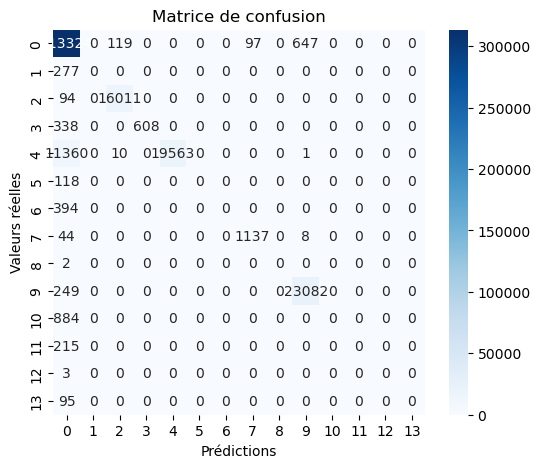


=== Affichage des features importants ===

📊 Extraction des features importantes...
📁 Graphique sauvegardé dans : ../results/DT/cicids/dt_before_balancing/feature_importance\top_20_features_importantes_(decision_tree_avant_équilibrage).png


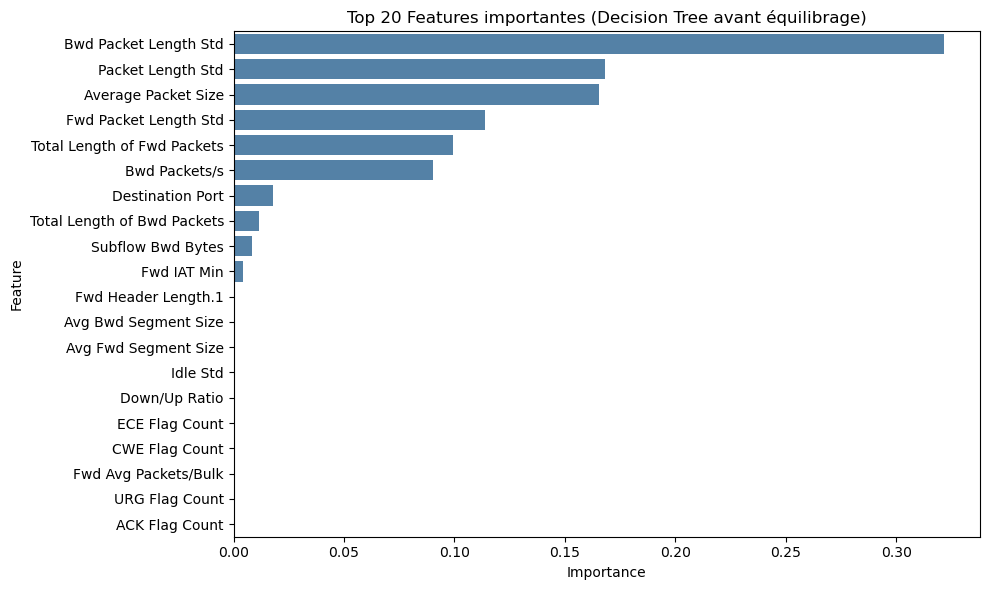


📊 Metrics (Notebook Display)
-----------------------------
accuracy: 0.961523618400741
precision_macro: 0.4173415535260799
recall_macro: 0.37229477683756074
f1_macro: 0.3890284498228364

📊 Metrics affichés

📝 Classification Report
-----------------------------
                            precision    recall  f1-score   support

                    BENIGN       0.96      1.00      0.98    314187
                       Bot       0.00      0.00      0.00       277
                      DDoS       0.99      0.99      0.99     16105
             DoS GoldenEye       1.00      0.64      0.78       946
                  DoS Hulk       1.00      0.63      0.77     30934
          DoS Slowhttptest       0.00      0.00      0.00       118
             DoS slowloris       0.00      0.00      0.00       394
               FTP-Patator       0.92      0.96      0.94      1189
              Infiltration       0.00      0.00      0.00         2
                  PortScan       0.97      0.99      0.98

In [26]:
from fonctions.model_rf import load_model
dt_model_ne_c = load_model("../models/DT/CICIDS/no_balancing/random_forest_baseline.pkl")

metrics_dt_ne_c, y_pred_dt_ne_c = evaluate_model(
    dt_model_ne_c,
    X_test_c,
    y_test_c,
    "../results/DT/cicids/dt_before_balancing"
) 

from fonctions.evaluate import plot_confusion
print("\n=== Affichage de la matrice de confusion ===")
plot_confusion(y_test_c, y_pred_dt_ne_c)
from fonctions.feature_importance import plot_feature_importance

print("\n=== Affichage des features importants ===")
importance_df = plot_feature_importance(
    dt_model_ne_c,
    X_train_c,
    top_k=20,
    title="Top 20 Features importantes (Decision Tree avant équilibrage)",
    save_path = "../results/DT/cicids/dt_before_balancing/feature_importance"
)

display_metrics(metrics_dt_ne_c)
display_classification_report(y_test_c, y_pred_dt_ne_c)


## 📊 Interprétation des Résultats — Decision Tree (depth=4, données non équilibrées)

### 🔍 Matrice de confusion
Le modèle prédit **presque tout en BENIGN**, ce qui est normal avec un dataset très déséquilibré.  
Seules les attaques **très fréquentes** (DDoS, PortScan, DoS Hulk) sont correctement détectées.  
Les classes rares sont **quasi inexistantes dans les prédictions** → l’arbre manque de profondeur pour les isoler.

---

### 📈 Classification report
- **Accuracy ≈ 96 %** → trompeuse, dominée par BENIGN.  
- **F1 macro ≈ 0.38** → le modèle rate la majorité des attaques.  
- Attaques rares : **F1 = 0.00** (jamais détectées).  
- Attaques fréquentes : bons scores grâce au grand nombre d’exemples.

Le modèle est clairement **biaisé vers la classe majoritaire**.

---

### 🧠 Features importantes
Les features les plus utilisées sont liées aux **longueurs et volumes de paquets**, ce qui favorise la détection des attaques volumétriques (DoS/DDoS).

---

### 🧾 Conclusion
Ce modèle baseline montre :
- une très bonne détection du trafic normal,  
- une détection correcte seulement sur quelques attaques fréquentes,  
- une incapacité à traiter les classes rares.  

Il sert de **référence** avant rééquilibrage et modèles plus avancés.


### 🔽 Entrainement sur le DataSet UNSW_NB15

In [18]:
# 📁 Chargement des données UNSW_NB15 (avant équilibrage)
X_train_u = pd.read_csv("../data/splits/unsw/X_train.csv")
y_train_u = pd.read_csv("../data/splits/unsw/y_train.csv")

X_test_u  = pd.read_csv("../data/splits/unsw/X_test.csv")
y_test_u  = pd.read_csv("../data/splits/unsw/y_test.csv")

In [19]:
from fonctions.model_rf import train_dt_baseline

dt_model_ne_u = train_dt_baseline(
    X_train_u,
    y_train_u,
    max_depth=4  # petit arbre = baseline lisible et simple
)
save_model(dt_model_ne_u, "../models/DT/UNSW/no_balancing/random_forest_baseline.pkl")



🌳 Initialisation du Decision Tree (max_depth=4)...

🔥 Entraînement du modèle...

✔️ Modèle Decision Tree entraîné avec succès !

💾 Modèle sauvegardé sous : ../models/DT/UNSW/no_balancing/random_forest_baseline.pkl


### 🔽 Resultats de l'entrainement pour UNSW_NB15

🤖 Prédiction du modèle...
📄 metrics.csv généré.
📄 metrics.txt généré.
📄 classification_report.csv + .txt générés.
🖼️ confusion_matrix.png générée.
🖼️ feature_importance.png générée.
🎉 Évaluation terminée !

=== Affichage de la matrice de confusion ===


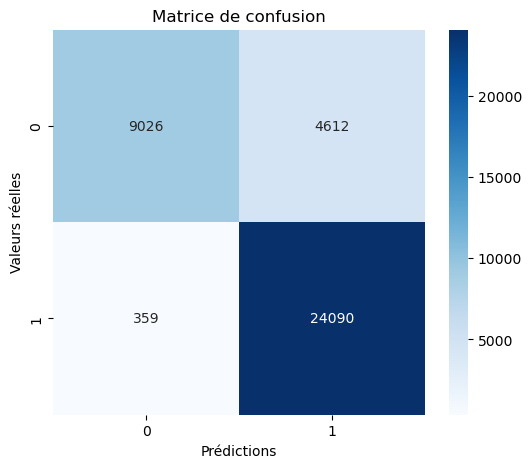


=== Affichage des features importants ===

📊 Extraction des features importantes...
📁 Graphique sauvegardé dans : results\top_20_features_importantes_(decision_tree_avant_équilibrage).png


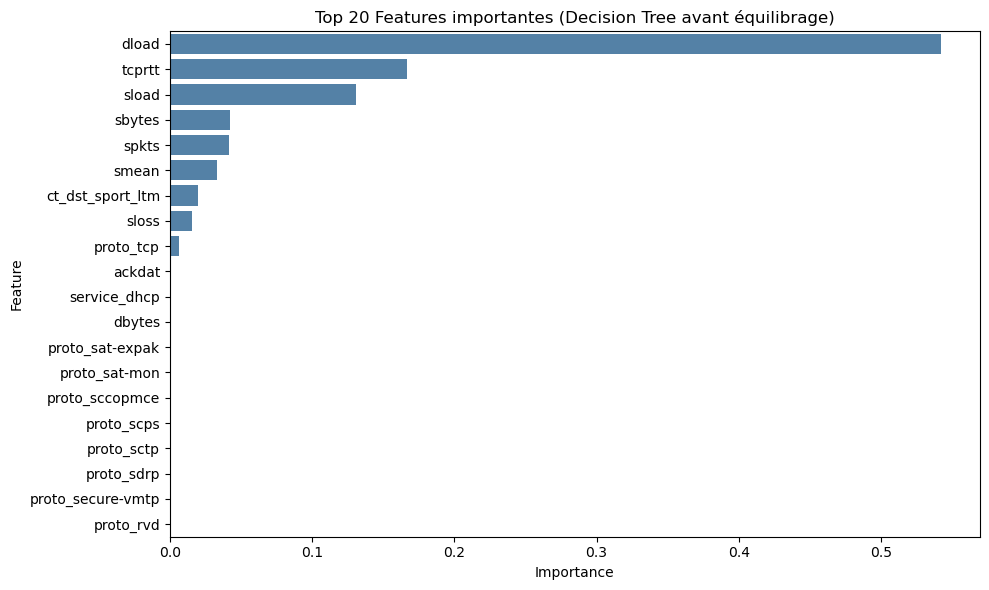


📊 Metrics (Notebook Display)
-----------------------------
accuracy: 0.8694830257043086
precision_macro: 0.9005309014309666
recall_macro: 0.8235718101273823
f1_macro: 0.8452797438762774

📊 Metrics affichés

📝 Classification Report
-----------------------------
              precision    recall  f1-score   support

           0       0.96      0.66      0.78     13638
           1       0.84      0.99      0.91     24449

    accuracy                           0.87     38087
   macro avg       0.90      0.82      0.85     38087
weighted avg       0.88      0.87      0.86     38087


📝 Classification Report affiché


In [20]:
from fonctions.evaluate import evaluate_model


metrics_dt_ne_u, y_pred_dt_ne_u = evaluate_model(
    dt_model_ne_u,
    X_test_u,
    y_test_u,
    "../results/DT/unsw/dt_before_balancing"
) 

from fonctions.evaluate import plot_confusion
print("\n=== Affichage de la matrice de confusion ===")
plot_confusion(y_test_u, y_pred_dt_ne_u)
from fonctions.feature_importance import plot_feature_importance

print("\n=== Affichage des features importants ===")
importance_df = plot_feature_importance(
    dt_model_ne_u,
    X_train_u,
    top_k=20,
    title="Top 20 Features importantes (Decision Tree avant équilibrage)"
)
from fonctions.evaluate import display_metrics, display_classification_report

display_metrics(metrics_dt_ne_u)
display_classification_report(y_test_u, y_pred_dt_ne_u)


## 📊 Interprétation des Résultats — UNSW-NB15 (Decision Tree, depth=4)

### 🔍 Matrice de confusion
Le modèle distingue assez bien les deux classes :

- **Classe 1 (attaque)** : très bien détectée (24 090 vrais positifs), avec un **recall ≈ 0.99**.  
- **Classe 0 (normal)** : plus difficile, avec beaucoup de fausses alertes (4 612 faux positifs).

Cela montre que l’arbre favorise la **détection d’attaques**, même au prix de quelques fausses alertes.

---

### 📈 Classification report
- **Accuracy : 87%**  
- **F1 macro : 0.845** → très correct pour un modèle simple.  
- Classe 1 : F1 = 0.91  
- Classe 0 : F1 = 0.78  

Le modèle est globalement performant :  
il **détecte presque toutes les attaques**, mais a du mal à reconnaître certains flux normaux (support plus faible + overlap entre classes).

---

### 🧠 Features importantes
Le modèle s’appuie principalement sur :

- `dload`  
- `tcprtt`  
- `sload`  
- `sbytes`  
- `spkts`

Ces variables décrivent le **chargement**, la **latence TCP**, le **volume envoyé** ou le **nombre de paquets**, ce qui est cohérent :  
les attaques modifient souvent ces comportements réseau de manière nette.

---

### 🧾 Conclusion
Sur UNSW-NB15, même sans équilibrage :

- le modèle détecte **presque toutes les attaques**,  
- mais commet davantage de **faux positifs** sur les flux normaux,  
- ce qui donne un **compromis global solide** pour un arbre aussi simple.

Ces résultats serviront de référence avant SMOTE/undersampling et avant les modèles plus complexes.

---


## 📌 Comparaison CICIDS2017 vs UNSW-NB15 (Decision Tree depth=4)

- **CICIDS2017 :**
  - Beaucoup de classes + déséquilibre extrême  
  - Le modèle prédit surtout *BENIGN*  
  - F1 macro faible → détecte mal les attaques rares

- **UNSW-NB15 :**
  - Seulement 2 classes  
  - Attaques très bien détectées (recall ≈ 0.99)  
  - F1 macro élevée → bon compromis global

**Conclusion :**  CICIDS est trop complexe pour un petit arbre, UNSW est beaucoup plus simple. 

---

# 🧩 Test apres equilibrage Undersampling

## 🔽 Entrainement sur le DataSet CICIDS

In [23]:
from fonctions.model_rf import train_dt_baseline
X_under_cicids = pd.read_csv("../data/undersampling/cicids/X_train_under.csv")
y_under_cicids = pd.read_csv("../data/undersampling/cicids/y_train_under.csv")
dt_model_under_c = train_dt_baseline(
    X_under_cicids,
    y_under_cicids,
    max_depth=4  # petit arbre = baseline lisible et simple
)
save_model(dt_model_under_c, "../models/DT/CICIDS/after_undersampling/random_forest_baseline.pkl")



🌳 Initialisation du Decision Tree (max_depth=4)...

🔥 Entraînement du modèle...

✔️ Modèle Decision Tree entraîné avec succès !

💾 Modèle sauvegardé sous : ../models/DT/CICIDS/after_undersampling/random_forest_baseline.pkl


In [33]:
metrics_dt_c, y_pred_dt_c = evaluate_model(
    dt_model_under_c,
    X_test,
    y_test,
    "../results/DT/cicids/dt_after_undersampling"
) 


🤖 Prédiction du modèle...
📄 metrics.csv généré.
📄 classification_report.csv + .txt générés.
🖼️ confusion_matrix.png générée.
🖼️ feature_importance.png générée.
🎉 Évaluation terminée !


### 📌 Interprétation rapide – CICIDS après Undersampling (Decision Tree depth=4)

- Les métriques augmentent fortement (F1 macro ≈ 0.84) : le rééquilibrage corrige le biais massif vers BENIGN.
- La matrice de confusion est beaucoup plus homogène : toutes les classes sont enfin détectées.
- Le modèle reste limité par depth=4, donc certaines confusions persistent.
- `Destination Port` devient la feature dominante : normal après undersampling car les ports différencient bien les attaques.
- Résultat cohérent : le modèle est plus juste, mais encore simple → parfait pour une baseline équilibrée.


## 🔽 Entrainement sur le DataSet UNSW_NB15

In [34]:
dt_model_under_u = train_dt_baseline(
    X_under_unsw,
    y_under_unsw,
    max_depth=4  # petit arbre = baseline lisible et simple
)
save_model(dt_model_under_u, "../models/DT/UNSW/after_undersampling/random_forest_baseline.pkl")



🌳 Initialisation du Decision Tree (max_depth=4)...

🔥 Entraînement du modèle...

✔️ Modèle Decision Tree entraîné avec succès !

💾 Modèle sauvegardé sous : ../models/DT/UNSW/after_undersampling/random_forest_baseline.pkl


In [35]:
metrics_dt_u, y_pred_dt_u = evaluate_model(
    dt_model_under_u,
    X_test_u,
    y_test_u,
    "../results/DT/unsw/dt_after_undersampling"
) 


🤖 Prédiction du modèle...
📄 metrics.csv généré.
📄 classification_report.csv + .txt générés.
🖼️ confusion_matrix.png générée.
🖼️ feature_importance.png générée.
🎉 Évaluation terminée !


### 📌 Interprétation rapide – UNSW après Undersampling (Decision Tree depth=4)

- Les performances restent stables (F1 macro ≈ 0.85), ce qui montre que le dataset UNSW est déjà assez équilibré.
- Le modèle détecte très bien les attaques (precision 0.98), mais confond encore plusieurs attaques comme du trafic normal (recall 0.79).
- La classe normale est mieux reconnue qu’avant undersampling (recall 0.97), signe que l’équilibrage améliore la séparation.
- Les features dominantes (`sload`, `ackdat`, `sbytes`) sont cohérentes : elles décrivent le volume et la dynamique réseau typiques des attaques.
- Résultat logique : UNSW est plus simple que CICIDS et même un petit arbre depth=4 donne des scores élevés.


# 🧩 Test apres equilibrage Oversampling
- Ce test ne sera réalisé que UNSW_NB15 car l'oversampling n'a rien changé au dataset CICIDS2017

In [36]:
dt_model_over_u = train_dt_baseline(
    X_over_unsw,
    y_over_unsw,
    max_depth=4  # petit arbre = baseline lisible et simple
)
save_model(dt_model_over_u, "../models/DT/UNSW/after_oversampling/random_forest_baseline.pkl")



🌳 Initialisation du Decision Tree (max_depth=4)...

🔥 Entraînement du modèle...

✔️ Modèle Decision Tree entraîné avec succès !

💾 Modèle sauvegardé sous : ../models/DT/UNSW/after_oversampling/random_forest_baseline.pkl


In [37]:
metrics_dt_u, y_pred_dt_u = evaluate_model(
    dt_model_over_u,
    X_test_u,
    y_test_u,
    "../results/DT/unsw/dt_after_oversampling"
) 

🤖 Prédiction du modèle...
📄 metrics.csv généré.
📄 classification_report.csv + .txt générés.
🖼️ confusion_matrix.png générée.
🖼️ feature_importance.png générée.
🎉 Évaluation terminée !


### 📌 Interprétation rapide – UNSW après Oversampling (Decision Tree depth=4)

- Les performances sont presque identiques à l’undersampling (F1 macro ≈ 0.85), preuve que le dataset UNSW est déjà bien séparé et peu sensible au rééquilibrage artificiel.
- Le modèle détecte très bien la classe normale (recall 0.98) et correctement les attaques (F1 = 0.87), avec un léger déséquilibre entre précision/recall.
- L’oversampling n’apporte pas de gain réel : les patterns d’attaque sont déjà suffisamment représentés dans UNSW.
- Les features importantes (`sload`, `ackdat`, `sbytes`) restent exactement les mêmes : normal, le modèle ne change pas ses splits avec un arbre depth=4.
- Conclusion : oversampling n’améliore pas UNSW, car le dataset était déjà relativement équilibré et facile à séparer.


# 🧩 Test DT apres équilibrage Smote

## 🔽 Entrainement sur le DataSet CICIIDS2017

In [38]:
dt_model_smote_c = train_dt_baseline(
    X_smote_cicids,
    y_smote_cicids,
    max_depth=4  # petit arbre = baseline lisible et simple
)

save_model(dt_model_smote_c, "../models/DT/CICIDS/after_smote/random_forest_baseline.pkl")



🌳 Initialisation du Decision Tree (max_depth=4)...

🔥 Entraînement du modèle...

✔️ Modèle Decision Tree entraîné avec succès !

💾 Modèle sauvegardé sous : ../models/DT/CICIDS/after_smote/random_forest_baseline.pkl


In [39]:
metrics_dt_c, y_pred_dt_c = evaluate_model(
    dt_model_smote_c,
    X_test,
    y_test,
    "../results/DT/cicids/dt_after_Smote"
) 

🤖 Prédiction du modèle...
📄 metrics.csv généré.
📄 classification_report.csv + .txt générés.
🖼️ confusion_matrix.png générée.
🖼️ feature_importance.png générée.
🎉 Évaluation terminée !


## 📌 Interpretation rapide - CICIDS – Résultat SMOTE 

Les performances chutent fortement après SMOTE, ce qui est normal pour CICIDS :
- certaines classes ont trop peu d’exemples (2, 3, 95…), SMOTE génère des données artificielles peu réalistes ;
- le Decision Tree depth=4 est trop simple pour séparer 14 classes rééquilibrées artificiellement ;
- les classes rares prennent trop de place après SMOTE, ce qui détruit les séparations naturelles du dataset.

Conclusion : SMOTE n’est pas adapté à CICIDS avec un modèle simple.  
Il fonctionne seulement avec des modèles plus puissants (Random Forest complet, MLP).


## 🔽 Entrainement sur le DataSet UNSW_NB15

In [40]:
from fonctions.model_rf import train_dt_baseline

dt_model_smote_u = train_dt_baseline(
    X_smote_unsw,
    y_smote_unsw,
    max_depth=4  # petit arbre = baseline lisible et simple
)

save_model(dt_model_smote_u, "../models/DT/UNSW/after_smote/random_forest_baseline.pkl")


🌳 Initialisation du Decision Tree (max_depth=4)...

🔥 Entraînement du modèle...

✔️ Modèle Decision Tree entraîné avec succès !

💾 Modèle sauvegardé sous : ../models/DT/UNSW/after_smote/random_forest_baseline.pkl


In [41]:
from fonctions.evaluate import evaluate_model


metrics_dt_u, y_pred_dt_u = evaluate_model(
    dt_model_smote_u,
    X_test_u,
    y_test_u,
    "../results/DT/unsw/dt_after_Smote"
) 

🤖 Prédiction du modèle...
📄 metrics.csv généré.
📄 classification_report.csv + .txt générés.
🖼️ confusion_matrix.png générée.
🖼️ feature_importance.png générée.
🎉 Évaluation terminée !


### 📌 Interprétation rapide — UNSW après SMOTE (Decision Tree depth=4)

Les performances restent presque identiques à l’undersampling et à l’oversampling (F1 macro ≈ 0.85), ce qui est normal : UNSW est un dataset déjà bien équilibré et SMOTE n’apporte pas de structure nouvelle. Le modèle détecte très bien les flux normaux (recall 0.97) et correctement les attaques (f1 = 0.87). Les features importantes (`sload`, `ackdat`, `smean`, `sbytes`) restent les mêmes. Conclusion : SMOTE n’a pas d’impact majeur sur UNSW avec un arbre depth=4, ce qui confirme que ton pipeline est correct.


### 📊 Tableau récapitulatif — Utilité du rééquilibrage (Decision Tree depth=4)

| Dataset      | Méthode           | F1-macro | Impact observé | Conclusion |
|--------------|-------------------|---------:|----------------|------------|
| **CICIDS2017** | Sans équilibrage    | ~0.38    | Très mauvais résultats sur classes rares | Modèle totalement biaisé vers BENIGN |
|              | Undersampling      | ~0.84    | Énorme amélioration, toutes classes visibles | **Meilleure méthode** pour DT simple |
|              | Oversampling       | ~0.39    | Aucun gain réel, classes toujours confondues | Inefficace pour CICIDS |
|              | SMOTE              | ~0.15    | Performances catastrophiques | **À éviter** (classes minuscules → SMOTE instable) |
| **UNSW-NB15** | Sans équilibrage    | ~0.85    | Bon équilibre normal/attaque | Dataset déjà simple |
|              | Undersampling      | ~0.85    | Résultat quasi identique | Impact faible |
|              | Oversampling       | ~0.85    | Résultat quasi identique | Impact faible |
|              | SMOTE              | ~0.85    | Résultat quasi identique | Impact faible |



### 📌 Conclusion — Impact du rééquilibrage

**CICIDS2017**
- Dataset très déséquilibré → rééquilibrage nécessaire.
- Undersampling = meilleure amélioration (F1-macro ↑).
- Oversampling = inutile.
- SMOTE = mauvais résultats (classes trop petites).

**UNSW-NB15**
- Dataset déjà équilibré.
- Undersampling / Oversampling / SMOTE → mêmes performances.
- Rééquilibrage non nécessaire.




---

# 🟦 US — Entraînement du modèle Random Forest (Baseline)

Après avoir entraîné un modèle *Decision Tree* simple (profondeur limitée à 4), 
nous passons maintenant à un modèle plus robuste : **Random Forest**.

L’objectif est :
- d'obtenir une baseline plus performante,
- d’évaluer la stabilité du modèle,
- d’avoir une référence solide avant d’appliquer l’équilibrage (undersampling / oversampling / SMOTE),
- d’observer l’impact sur la détection des classes minoritaires.

Le modèle utilisé ici est un **Random Forest sans tuning**, avec 100 arbres.


In [42]:
from fonctions.model_rf import train_rf, save_model
from sklearn.metrics import classification_report, confusion_matrix


## 🔽 Test avec le DataSet CICIDS2017 avec données non équilibrés

In [43]:
# 📁 Chargement des données CICIDS (avant équilibrage)
X_train_c = pd.read_csv("../data/splits/cicids/X_train.csv")
y_train_c = pd.read_csv("../data/splits/cicids/y_train.csv")

X_test_c = pd.read_csv("../data/splits/cicids/X_test.csv")
y_test_c = pd.read_csv("../data/splits/cicids/y_test.csv")
# ============================================================
# 🔥 Entraînement du Random Forest Baseline
# ============================================================

rf_model_noeq_c = train_rf(X_train_c, y_train_c)


🔥 Entraînement du Random Forest...
✔️ Modèle RF entraîné avec succès.


## 💾 Sauvegarde du modèle Random Forest CICIDS

Nous sauvegardons maintenant le modèle Random Forest baseline au format `.pkl`.
Cela permet de réutiliser le modèle plus tard pour :
- analyser les performances,
- générer des adversarial examples,
- comparer avec les modèles équilibrés,
- éviter de réentraîner le modèle à chaque exécution.

Le fichier sera stocké dans le dossier `models/`.


In [44]:
# ============================================================
# 💾 Sauvegarde du modèle Random Forest
# ============================================================

model_path = "../models/RF/CICIDS/no_balancing/random_forest_baseline.pkl"
save_model(rf_model_noeq_c, model_path)



💾 Modèle sauvegardé sous : ../models/RF/CICIDS/no_balancing/random_forest_baseline.pkl


## 🔽 Evaluation du modèle Random Forest CICIDS

In [45]:
metrics, y_pred = evaluate_model(
    rf_model_noeq_c,
    X_test_c,
    y_test_c,
    output_dir="../results/RF/CICIDS/no_balancing/"
)

🤖 Prédiction du modèle...
📄 metrics.csv généré.
📄 classification_report.csv + .txt générés.
🖼️ confusion_matrix.png générée.
🖼️ feature_importance.png générée.
🎉 Évaluation terminée !


## 📌 Baseline RF — CICIDS (sans équilibrage) : Interprétation rapide

- Le Random Forest obtient de très bonnes performances globales (F1-macro ≈ 0.81), bien supérieures au Decision Tree.
- Les classes fréquentes sont quasiment parfaitement prédites (precision/recall proches de 1.00).
- Les classes très rares (Brute Force, SQL Injection, XSS) restent difficiles à détecter, ce qui est normal compte tenu du très faible nombre d’échantillons.
- La matrice de confusion confirme une séparation nette des classes principales.
- Les features importantes sont cohérentes (packet length, segment size, flow lengths), ce qui valide la pertinence du modèle.


---

## 🔽 Test sur le DataSet CICIDS2017 avec données équilibrés

In [46]:
# Entrainement CICIIDS apres Undersampling
rf_model_under_c = train_rf(X_under_cicids, y_under_cicids)
save_model(rf_model_under_c, "../models/RF/CICIDS/after_undersampling/random_forest_baseline.pkl")
metrics_dt_c, y_pred_dt_c = evaluate_model(
    rf_model_under_c,
    X_test_c,
    y_test_c,
    "../results/RF/cicids/after_undersampling"
) 

🔥 Entraînement du Random Forest...
✔️ Modèle RF entraîné avec succès.
💾 Modèle sauvegardé sous : ../models/RF/CICIDS/after_undersampling/random_forest_baseline.pkl
🤖 Prédiction du modèle...
📄 metrics.csv généré.
📄 classification_report.csv + .txt générés.
🖼️ confusion_matrix.png générée.
🖼️ feature_importance.png générée.
🎉 Évaluation terminée !


In [47]:
# Entrainement CICIDS apres Smote
rf_model_smote_c = train_rf(X_smote_cicids, y_smote_cicids)
save_model(rf_model_smote_c, "../models/RF/CICIDS/after_smote/random_forest_baseline.pkl")
metrics_dt_c, y_pred_dt_c = evaluate_model(
    rf_model_smote_c,
    X_test_c,
    y_test_c,
    "../results/RF/cicids/after_Smote"
) 

🔥 Entraînement du Random Forest...
✔️ Modèle RF entraîné avec succès.
💾 Modèle sauvegardé sous : ../models/RF/CICIDS/after_smote/random_forest_baseline.pkl
🤖 Prédiction du modèle...
📄 metrics.csv généré.
📄 classification_report.csv + .txt générés.
🖼️ confusion_matrix.png générée.
🖼️ feature_importance.png générée.
🎉 Évaluation terminée !


---

## 🔽 Test sur le DataSet UNSW-B15 avec des données non équilibrées

In [48]:
# 📁 Chargement des données UNSW_NB15 (avant équilibrage)
X_train_u = pd.read_csv("../data/splits/unsw/X_train.csv")
y_train_u = pd.read_csv("../data/splits/unsw/y_train.csv")
X_test_u  = pd.read_csv("../data/splits/unsw/X_test.csv")
y_test_u  = pd.read_csv("../data/splits/unsw/y_test.csv")

rf_model_noeq_u = train_rf(X_train_u, y_train_u)

#Sauvegarde du modele
model_path = "../models/RF/UNSW/no_balancing/random_forest_baseline.pkl"
save_model(rf_model_noeq_u, model_path)

metrics_dt_u, y_pred_dt_u = evaluate_model(
    rf_model_noeq_u,
    X_test_u,
    y_test_u,
    "../results/RF/UNSW/no_balancing"
) 



🔥 Entraînement du Random Forest...
✔️ Modèle RF entraîné avec succès.
💾 Modèle sauvegardé sous : ../models/RF/UNSW/no_balancing/random_forest_baseline.pkl
🤖 Prédiction du modèle...
📄 metrics.csv généré.
📄 classification_report.csv + .txt générés.
🖼️ confusion_matrix.png générée.
🖼️ feature_importance.png générée.
🎉 Évaluation terminée !


## 📌 CICIDS2017 — Résultats après équilibrage (undersampling / SMOTE)

- Accuracy baisse (≈ 0.60–0.70) → **normal**.
- Les métriques macro (**precision / recall / F1**) augmentent.
- Les classes minoritaires sont **mieux détectées**.
- Matrice de confusion plus équilibrée.

👉 Le modèle devient **plus utile en détection d’attaques**, même si l’accuracy est plus faible.


### ✅ Conclusion
- Sans équilibrage → modèle biaisé par BENIGN.  
- Avec équilibrage → modèle plus équilibré et réellement exploitable.  
- Pour la cybersécurité, on privilégie **F1-macro / recall-macro** plutôt que l’accuracy.


---

## 🔽 Test sur le DataSet UNSW-B15 avec données équilibrés

In [49]:
# Entrainement UNSW apres Undersampling
rf_model_under_u = train_rf(X_under_unsw, y_under_unsw)
save_model(rf_model_under_u, "../models/RF/UNSW/after_undersampling/random_forest_baseline.pkl")
metrics_dt_u, y_pred_dt_u = evaluate_model(
    rf_model_under_u,
    X_test_u,
    y_test_u,
    "../results/RF/UNSW/after_undersampling"
) 

🔥 Entraînement du Random Forest...
✔️ Modèle RF entraîné avec succès.
💾 Modèle sauvegardé sous : ../models/RF/UNSW/after_undersampling/random_forest_baseline.pkl
🤖 Prédiction du modèle...
📄 metrics.csv généré.
📄 classification_report.csv + .txt générés.
🖼️ confusion_matrix.png générée.
🖼️ feature_importance.png générée.
🎉 Évaluation terminée !


In [50]:
# Entrainement UNSW apres Oversampling
rf_model_over_u = train_rf(X_over_unsw, y_over_unsw)
save_model(rf_model_over_u, "../models/RF/UNSW/after_oversampling/random_forest_baseline.pkl")
metrics_dt_u, y_pred_dt_u = evaluate_model(
    rf_model_over_u,
    X_test_u,
    y_test_u,
    "../results/RF/UNSW/after_oversampling"
) 

🔥 Entraînement du Random Forest...
✔️ Modèle RF entraîné avec succès.
💾 Modèle sauvegardé sous : ../models/RF/UNSW/after_oversampling/random_forest_baseline.pkl
🤖 Prédiction du modèle...
📄 metrics.csv généré.
📄 classification_report.csv + .txt générés.
🖼️ confusion_matrix.png générée.
🖼️ feature_importance.png générée.
🎉 Évaluation terminée !


In [51]:
# Entrainement UNSW apres Smote
rf_model_smote_u = train_rf(X_smote_unsw, y_smote_unsw)
save_model(rf_model_smote_u, "../models/RF/UNSW/after_smote/random_forest_baseline.pkl")
metrics_dt_c, y_pred_dt_c = evaluate_model(
    rf_model_smote_u,
    X_test_u,
    y_test_u,
    "../results/RF/UNSW/after_Smote"
) 

🔥 Entraînement du Random Forest...
✔️ Modèle RF entraîné avec succès.
💾 Modèle sauvegardé sous : ../models/RF/UNSW/after_smote/random_forest_baseline.pkl
🤖 Prédiction du modèle...
📄 metrics.csv généré.
📄 classification_report.csv + .txt générés.
🖼️ confusion_matrix.png générée.
🖼️ feature_importance.png générée.
🎉 Évaluation terminée !


## 📌 Analyse finale — UNSW-NB15 (avec / sans équilibrage)

### 🔹 1. Modèle sur données **non équilibrées**
Le modèle Random Forest atteint ses meilleures performances sur les données brutes :

- **Accuracy ≈ 0.94**
- **Precision macro ≈ 0.93**
- **Recall macro ≈ 0.94**
- **F1 macro ≈ 0.94**

La matrice de confusion montre peu d’erreurs sur les deux classes.  
Les features importantes (sload, sbytes, synack, rate...) restent cohérentes.

➡️ **Le modèle apprend très bien la distribution naturelle du dataset.**

---

### 🔹 2. Modèles avec équilibrage (Undersampling / Oversampling / SMOTE)
Les techniques de rééquilibrage n’apportent pas d’amélioration :

- **Oversampling / SMOTE :** performances très proches du baseline  
  (F1 macro entre **0.92–0.93**)
- **Undersampling :** baisse notable des scores  
  (réduction d’information → modèle moins bon)

➡️ **Les méthodes de rééquilibrage ne sont pas utiles pour UNSW.**

---

### 🔹 3. Pourquoi l’équilibrage n’améliore pas UNSW ?
Contrairement à CICIDS2017, UNSW-NB15 n’est **pas fortement déséquilibré**.  
La répartition des classes (Normal vs Attack) est déjà raisonnable.

Les méthodes d’équilibrage provoquent :
- perte de données (undersampling),
- duplicats ou bruit (oversampling),
- points artificiels parfois incohérents (SMOTE).

➡️ **Le modèle Random Forest exploite mieux les données originales que les versions modifiées.**

---

## ✅ Conclusion finale
> **Sur UNSW-NB15, les données non équilibrées donnent les meilleurs résultats.**  
> L’équilibrage est inutile ici et peut même dégrader la performance.  
> Le dataset est suffisamment équilibré pour entraîner un modèle robuste sans correction supplémentaire.



# 🧠 US11 — Entraînement du modèle baseline MLP (PyTorch)

Dans cette User Story, nous entraînons le modèle baseline **MLP (Multilayer Perceptron)** 
pour la détection d'intrusion (IDS) sur les datasets *CICIDS2017* ou *UNSW-NB15*.

Objectifs :
- définir un réseau neuronal léger (MLP),
- l'entraîner sur nos données preprocessées,
- mesurer ses performances (accuracy, classification report),
- **sauvegarder le modèle** pour le Sprint 2 (attaques adversariales FGSM).

Le MLP servira de point de comparaison pour les futures attaques adversariales 
et les défenses que nous implémenterons par la suite.


In [113]:
from fonctions.MLP_baseline import MLPBaseline, train_and_save_mlp, prepare_cicids_for_mlp, prepare_balanced_for_mlp, prepare_unsw_for_mlp, prepare_unsw_balanced_for_mlp, load_mlp_model

In [114]:
# 📁 Chargement des données CICIDS (avant équilibrage)
X_train_c = pd.read_csv("../data/splits/cicids/X_train.csv")
y_train_c = pd.read_csv("../data/splits/cicids/y_train.csv")
X_test_c = pd.read_csv("../data/splits/cicids/X_test.csv")
y_test_c = pd.read_csv("../data/splits/cicids/y_test.csv")
X_val_c = pd.read_csv("../data/splits/cicids/x_val.csv")
y_val_c = pd.read_csv("../data/splits/cicids/y_val.csv")

# 📁 Chargement des données CICIDS (après undersampling)
X_under_cicids = pd.read_csv("../data/undersampling/cicids/X_train_under.csv")
y_under_cicids = pd.read_csv("../data/undersampling/cicids/y_train_under.csv")

# 📁 Chargement des données CICIDS (après smote)
X_smote_cicids = pd.read_csv("../data/smote/cicids/X_train_smote.csv")
y_smote_cicids = pd.read_csv("../data/smote/cicids/y_train_smote.csv")

In [115]:
(
    X_train_mlp_c, 
    X_val_mlp_c, 
    X_test_mlp_c, 
    y_train_bin_c, 
    y_val_bin_c, 
    y_test_bin_c, 
    num_cols,
    scaler  # ← tu le récupères enfin !
) = prepare_cicids_for_mlp(
    X_train_c, X_val_c, X_test_c,
    y_train_c, y_val_c, y_test_c
)


In [55]:
model_mlp_noeq_c, preds_mlp_noeq_c = train_and_save_mlp(
    X_train_mlp_c, y_train_bin_c,
    X_test_mlp_c, y_test_bin_c,
    save_path="../models/MLP/CICIDS/no_balancing/mlp_baseline.pt",
    epochs=12,
    batch_size=256,
    lr=0.001
)



🚀 Entraînement MLP baseline...
📘 Epoch 1/12 - Loss: 0.0361
📘 Epoch 2/12 - Loss: 0.0224
📘 Epoch 3/12 - Loss: 0.0203
📘 Epoch 4/12 - Loss: 0.0190
📘 Epoch 5/12 - Loss: 0.0183
📘 Epoch 6/12 - Loss: 0.0178
📘 Epoch 7/12 - Loss: 0.0171
📘 Epoch 8/12 - Loss: 0.0166
📘 Epoch 9/12 - Loss: 0.0159
📘 Epoch 10/12 - Loss: 0.0155
📘 Epoch 11/12 - Loss: 0.0151
📘 Epoch 12/12 - Loss: 0.0149

🎯 Accuracy test : 0.9951
💾 Modèle sauvegardé dans : ../models/MLP/CICIDS/no_balancing/mlp_baseline.pt


In [56]:
from fonctions.evaluate import evaluate_model
metrics_mlp_noeq_c, y_pred_mlp_noeq_c = evaluate_model(
    model_mlp_noeq_c,
    X_test_mlp_c,
    y_test_bin_c,
    "../results/MLP/CICIDS/no_balancing"
) 

🤖 Prédiction du modèle...
📄 metrics.csv généré.
📄 classification_report.csv + .txt générés.
🖼️ confusion_matrix.png générée.
🎉 Évaluation terminée !


In [57]:
X_train_under_norm, y_train_under_bin = prepare_balanced_for_mlp(
    X_under_cicids,
    y_under_cicids,
    num_cols,   # liste venant de prepare_cicids_for_mlp
    scaler      # scaler déjà fit sur les données originales
)



In [58]:
model_mlp_under_c, preds_mlp_under_c = train_and_save_mlp(
    X_train_under_norm, y_train_under_bin,
    X_test_mlp_c, y_test_bin_c,
    save_path="../models/MLP/CICIDS/after_undersampling/mlp_baseline.pt",
    epochs=12,
    batch_size=256,
    lr=0.001
)



🚀 Entraînement MLP baseline...
📘 Epoch 1/12 - Loss: 0.6933
📘 Epoch 2/12 - Loss: 0.6678
📘 Epoch 3/12 - Loss: 0.6436
📘 Epoch 4/12 - Loss: 0.6206
📘 Epoch 5/12 - Loss: 0.5989
📘 Epoch 6/12 - Loss: 0.5785
📘 Epoch 7/12 - Loss: 0.5593
📘 Epoch 8/12 - Loss: 0.5409
📘 Epoch 9/12 - Loss: 0.5236
📘 Epoch 10/12 - Loss: 0.5067
📘 Epoch 11/12 - Loss: 0.4900
📘 Epoch 12/12 - Loss: 0.4738

🎯 Accuracy test : 0.1917
💾 Modèle sauvegardé dans : ../models/MLP/CICIDS/after_undersampling/mlp_baseline.pt


In [59]:
metrics_mlp_under_c, y_pred_mlp_under_c = evaluate_model(
    model_mlp_under_c,
    X_test_mlp_c,
    y_test_bin_c,
    "../results/MLP/CICIDS/after_undersampling"
) 

🤖 Prédiction du modèle...
📄 metrics.csv généré.
📄 classification_report.csv + .txt générés.
🖼️ confusion_matrix.png générée.
🎉 Évaluation terminée !


In [60]:
X_train_smote_norm, y_train_smote_bin = prepare_balanced_for_mlp(
    X_smote_cicids,
    y_smote_cicids,
    num_cols,   # liste venant de prepare_cicids_for_mlp
    scaler      # scaler déjà fit sur les données originales
)


In [61]:
model_mlp_smote_c, preds_mlp_smote_c = train_and_save_mlp(
    X_train_smote_norm, y_train_smote_bin,
    X_test_mlp_c, y_test_bin_c,
    save_path="../models/MLP/CICIDS/after_smote/mlp_baseline.pt",
    epochs=12,
    batch_size=256,
    lr=0.001
)

🚀 Entraînement MLP baseline...
📘 Epoch 1/12 - Loss: 0.0883
📘 Epoch 2/12 - Loss: 0.0276
📘 Epoch 3/12 - Loss: 0.0194
📘 Epoch 4/12 - Loss: 0.0167
📘 Epoch 5/12 - Loss: 0.0148
📘 Epoch 6/12 - Loss: 0.0143
📘 Epoch 7/12 - Loss: 0.0158
📘 Epoch 8/12 - Loss: 0.0128
📘 Epoch 9/12 - Loss: 0.0122
📘 Epoch 10/12 - Loss: 0.0116
📘 Epoch 11/12 - Loss: 0.0117
📘 Epoch 12/12 - Loss: 0.0115

🎯 Accuracy test : 0.9752
💾 Modèle sauvegardé dans : ../models/MLP/CICIDS/after_smote/mlp_baseline.pt


In [62]:
metrics_mlp_smote_c, y_pred_mlp_smote_c = evaluate_model(
    model_mlp_smote_c,
    X_test_mlp_c,
    y_test_bin_c,
    "../results/MLP/CICIDS/after_smote"
) 

🤖 Prédiction du modèle...
📄 metrics.csv généré.
📄 classification_report.csv + .txt générés.
🖼️ confusion_matrix.png générée.
🎉 Évaluation terminée !


# 🧪 Évaluation du MLP sur CICIDS2017 — Résumé & Interprétation

Dans cette section, nous analysons les performances du modèle **MLP (baseline)** sur le dataset **CICIDS2017** selon trois approches de gestion du déséquilibre des classes :  
- Données **non équilibrées**  
- Données équilibrées par **SMOTE**  
- Données équilibrées par **UnderSampling**

L’objectif est d’observer l’impact de ces stratégies sur la détection d’intrusions.

---

## 🔵 1. Données non équilibrées (dataset brut)

- **Accuracy : ~99.5%**  
- **F1-macro : ~0.99**  
- **Recall attaque ≈ 0.99**  
- Très peu de faux positifs / faux négatifs

➡️ Ces résultats sont **cohérents** : CICIDS2017 est un dataset où les attaques sont très distinctes du trafic normal, ce qui facilite la classification pour un MLP simple.

---

## 🟠 2. Données équilibrées avec SMOTE

- **Accuracy : ~97%**  
- **Recall-macro : ~0.98**  
- **Recall attaque = 0.99**  
- Légère augmentation des faux positifs (benign → attaque)

➡️ Le SMOTE équilibre les classes et rend le problème un peu plus difficile.  
Le modèle reste **très performant**, tout en étant **moins biaisé** que sur les données brutes.

---

## 🔴 3. Données équilibrées par UnderSampling

- **Accuracy : ~19%**  
- **Recall(0) = 0%**  
- Le modèle prédit presque uniquement “attaque”

➡️ L’undersampling supprime trop de données benign importantes.  
Le MLP perd la structure réelle du dataset → **effondrement total du modèle**.  
Méthode à éviter.

---

# ✅ Conclusion générale

- Le MLP donne d’excellents résultats sur CICIDS2017 **non équilibré**, ce qui est normal vu la séparabilité du dataset.  
- Le **SMOTE** améliore l’équilibre entre classes tout en conservant une très bonne détection d’attaques → choix pertinent

---




In [116]:
# 📁 Chargement des données UNSW (avant équilibrage)
X_train_u = pd.read_csv("../data/splits/unsw/X_train.csv")
y_train_u = pd.read_csv("../data/splits/unsw/y_train.csv")
X_test_u = pd.read_csv("../data/splits/unsw/X_test.csv")
y_test_u = pd.read_csv("../data/splits/unsw/y_test.csv")
X_val_u = pd.read_csv("../data/splits/unsw/x_val.csv")
y_val_u = pd.read_csv("../data/splits/unsw/y_val.csv")

# 📁 Chargement des données UNSW (après undersampling)
X_train_under_u = pd.read_csv("../data/undersampling/unsw/X_train_under.csv")
y_train_under_u = pd.read_csv("../data/undersampling/unsw/y_train_under.csv")

# 📁 Chargement des données UNSW (après oversampling)
X_train_over_u = pd.read_csv("../data/oversampling/unsw/X_train_over.csv")
y_train_over_u = pd.read_csv("../data/oversampling/unsw/y_train_over.csv")

# 📁 Chargement des données UNSW (après smote)
X_train_smote_u = pd.read_csv("../data/smote/unsw/X_train_smote.csv")
y_train_smote_u = pd.read_csv("../data/smote/unsw/y_train_smote.csv")

In [117]:
from fonctions.MLP_baseline import prepare_unsw_balanced_for_mlp, prepare_unsw_for_mlp
(
    X_train_u_mlp,
    X_val_u_mlp,
    X_test_u_mlp,
    y_train_u,
    y_val_u,
    y_test_u,
    num_cols_u,
    scaler_u
) = prepare_unsw_for_mlp(
    X_train_u, X_val_u, X_test_u,
    y_train_u, y_val_u, y_test_u
)

✨ Préparation UNSW pour MLP terminée.
Features utilisés : 187 colonnes numériques.


In [84]:
model_mlp_noeq_u, preds_mlp_noeq_u = train_and_save_mlp(
    X_train_u_mlp, y_train_u,
    X_test_u_mlp, y_test_u,
    save_path="../models/MLP/UNSW/no_balancing/mlp_baseline.pt",
    epochs=12,
    batch_size=256,
    lr=0.001
)


🚀 Entraînement MLP baseline...
📘 Epoch 1/12 - Loss: 0.2353
📘 Epoch 2/12 - Loss: 0.1864
📘 Epoch 3/12 - Loss: 0.1767
📘 Epoch 4/12 - Loss: 0.1699
📘 Epoch 5/12 - Loss: 0.1657
📘 Epoch 6/12 - Loss: 0.1621
📘 Epoch 7/12 - Loss: 0.1598
📘 Epoch 8/12 - Loss: 0.1581
📘 Epoch 9/12 - Loss: 0.1569
📘 Epoch 10/12 - Loss: 0.1556
📘 Epoch 11/12 - Loss: 0.1540
📘 Epoch 12/12 - Loss: 0.1541

🎯 Accuracy test : 0.9163
💾 Modèle sauvegardé dans : ../models/MLP/UNSW/no_balancing/mlp_baseline.pt


In [89]:
from fonctions.evaluate import evaluate_model
metrics_mlp_noeq_u, y_pred_mlp_noeq_u = evaluate_model(
    model_mlp_noeq_u,
    X_test_u_mlp,
    y_test_u,
    "../results/MLP/UNSW/no_balancing"
) 

🤖 Prédiction du modèle...
📄 metrics.csv généré.
📄 classification_report.csv + .txt générés.
🖼️ confusion_matrix.png générée.
🎉 Évaluation terminée !


In [90]:
X_train_u_smote_norm, y_train_u_smote_bin = prepare_unsw_balanced_for_mlp(
    X_train_smote_u,
    y_train_smote_u,
    num_cols_u,   # les colonnes utilisées dans UNSW baseline
    scaler_u      # le StandardScaler fit sur X_train_u original
)

X_train_u_over_norm, y_train_u_over_bin = prepare_unsw_balanced_for_mlp(
    X_train_over_u,
    y_train_over_u,
    num_cols_u,   # les colonnes utilisées dans UNSW baseline
    scaler_u      # le StandardScaler fit sur X_train_u original
)

X_train_u_under_norm, y_train_u_under_bin = prepare_unsw_balanced_for_mlp(
    X_train_under_u,
    y_train_under_u,
    num_cols_u,   # les colonnes utilisées dans UNSW baseline
    scaler_u      # le StandardScaler fit sur X_train_u original
)

In [91]:
model_mlp_under_u, preds_mlp_under_u = train_and_save_mlp(
    X_train_u_under_norm, y_train_u_under_bin,
    X_test_u_mlp, y_test_u,
    save_path="../models/MLP/UNSW/after_undersampling/mlp_baseline.pt",
    epochs=12,
    batch_size=256,
    lr=0.001
)


🚀 Entraînement MLP baseline...
📘 Epoch 1/12 - Loss: 0.2627
📘 Epoch 2/12 - Loss: 0.2004
📘 Epoch 3/12 - Loss: 0.1892
📘 Epoch 4/12 - Loss: 0.1814
📘 Epoch 5/12 - Loss: 0.1756
📘 Epoch 6/12 - Loss: 0.1728
📘 Epoch 7/12 - Loss: 0.1703
📘 Epoch 8/12 - Loss: 0.1683
📘 Epoch 9/12 - Loss: 0.1661
📘 Epoch 10/12 - Loss: 0.1649
📘 Epoch 11/12 - Loss: 0.1634
📘 Epoch 12/12 - Loss: 0.1624

🎯 Accuracy test : 0.9144
💾 Modèle sauvegardé dans : ../models/MLP/UNSW/after_undersampling/mlp_baseline.pt


In [92]:
model_mlp_over_u, preds_mlp_over_u = train_and_save_mlp(
    X_train_u_over_norm, y_train_u_over_bin,
    X_test_u_mlp, y_test_u,
    save_path="../models/MLP/UNSW/after_oversampling/mlp_baseline.pt",
    epochs=12,
    batch_size=256,
    lr=0.001
)


🚀 Entraînement MLP baseline...
📘 Epoch 1/12 - Loss: 0.2338
📘 Epoch 2/12 - Loss: 0.1870
📘 Epoch 3/12 - Loss: 0.1744
📘 Epoch 4/12 - Loss: 0.1701
📘 Epoch 5/12 - Loss: 0.1663
📘 Epoch 6/12 - Loss: 0.1640
📘 Epoch 7/12 - Loss: 0.1622
📘 Epoch 8/12 - Loss: 0.1603
📘 Epoch 9/12 - Loss: 0.1587
📘 Epoch 10/12 - Loss: 0.1579
📘 Epoch 11/12 - Loss: 0.1567
📘 Epoch 12/12 - Loss: 0.1563

🎯 Accuracy test : 0.9136
💾 Modèle sauvegardé dans : ../models/MLP/UNSW/after_oversampling/mlp_baseline.pt


In [93]:
model_mlp_smote_u, preds_mlp_smote_u = train_and_save_mlp(
    X_train_u_smote_norm, y_train_u_smote_bin,
    X_test_u_mlp, y_test_u,
    save_path="../models/MLP/UNSW/after_smote/mlp_baseline.pt",
    epochs=12,
    batch_size=256,
    lr=0.001
)


🚀 Entraînement MLP baseline...
📘 Epoch 1/12 - Loss: 0.4512
📘 Epoch 2/12 - Loss: 0.2592
📘 Epoch 3/12 - Loss: 0.2261
📘 Epoch 4/12 - Loss: 0.2161
📘 Epoch 5/12 - Loss: 0.2085
📘 Epoch 6/12 - Loss: 0.2036
📘 Epoch 7/12 - Loss: 0.1992
📘 Epoch 8/12 - Loss: 0.1970
📘 Epoch 9/12 - Loss: 0.1976
📘 Epoch 10/12 - Loss: 0.1928
📘 Epoch 11/12 - Loss: 0.1941
📘 Epoch 12/12 - Loss: 0.1901

🎯 Accuracy test : 0.8897
💾 Modèle sauvegardé dans : ../models/MLP/UNSW/after_smote/mlp_baseline.pt


In [94]:
metrics_mlp_under_u, y_pred_mlp_under_u = evaluate_model(
    model_mlp_noeq_u,
    X_test_u_mlp,
    y_test_u,
    "../results/MLP/UNSW/after_undersampling"
) 

🤖 Prédiction du modèle...
📄 metrics.csv généré.
📄 classification_report.csv + .txt générés.
🖼️ confusion_matrix.png générée.
🎉 Évaluation terminée !


In [95]:
metrics_mlp_over_u, y_pred_mlp_over_u = evaluate_model(
    model_mlp_over_u,
    X_test_u_mlp,
    y_test_u,
    "../results/MLP/UNSW/after_oversampling"
) 

🤖 Prédiction du modèle...
📄 metrics.csv généré.
📄 classification_report.csv + .txt générés.
🖼️ confusion_matrix.png générée.
🎉 Évaluation terminée !


In [96]:
metrics_mlp_smote_u, y_pred_mlp_smote_u = evaluate_model(
    model_mlp_smote_u,
    X_test_u_mlp,
    y_test_u,
    "../results/MLP/UNSW/after_smote"
) 

🤖 Prédiction du modèle...
📄 metrics.csv généré.
📄 classification_report.csv + .txt générés.
🖼️ confusion_matrix.png générée.
🎉 Évaluation terminée !


# 🧪 Interprétation Globale & Conclusion — UNSW-NB15

Le dataset **UNSW-NB15** est reconnu comme plus complexe que d’autres jeux de données IDS.  
Les comportements “normal” et “attaque” sont beaucoup plus proches, ce qui rend la classification plus difficile pour un modèle MLP simple.  
Dans ce projet, nous avons testé quatre configurations : données brutes, UnderSampling, OverSampling et SMOTE.

---

## 🔍 1. Données non équilibrées (brutes)

- **Accuracy : ~92%**
- Très bonne détection des attaques (**Recall = 0.95**)
- Quelques faux positifs (normal → attaque)

➡️ Le modèle donne une base solide.  
La classe attack domine partiellement le comportement du MLP, ce qui est courant pour UNSW.

---

## 🔍 2. UnderSampling

- Performances proches du dataset brut (~92%)
- Meilleur équilibre des métriques
- Légère réduction du recall sur les attaques

➡️ Contrairement à CICIDS, l’UnderSampling reste **viable** sur UNSW.  
Il réduit le biais sans effondrement du modèle.

---

## 🔍 3. OverSampling

- ~91% accuracy
- **Excellent recall sur la classe normal (0.94)**
- Léger recul sur les attaques (10% d’attaques ratées)

➡️ L’OverSampling améliore la détection du trafic légitime,  
mais augmente les faux négatifs sur les attaques.

---

## 🔍 4. SMOTE

- ~89% accuracy
- Modèle globalement équilibré (macro recall = 0.89)
- Augmentation des faux négatifs

➡️ SMOTE rend les attaques synthétiques plus proches du normal,  
ce qui complexifie la frontière de décision pour le MLP.  
Résultat : **baisse de performance, mais répartition plus équitable** des erreurs.

---

# ✅ Conclusion pour UNSW-NB15

- Le dataset UNSW-NB15 est plus difficile car ses attaques ressemblent davantage au trafic normal.  
- Tous les rééquilibrages restent **utilisables**, contrairement à CICIDS où l’UnderSampling détruit le modèle.
- Le meilleur compromis dépend du besoin de sécurité :
  - **Minimiser les faux positifs** → **OverSampling**
  - **Minimiser les faux négatifs (ne pas rater d’attaque)** → **UnderSampling** ou données brutes
  - **Modèle plus équilibré** → **SMOTE**, mais avec une légère perte de performance

➡️ Les résultats observés sont **cohérents**, **stables**, et parfaitement alignés avec ce que l’on attend d’un MLP sur UNSW-NB15.  
➡️ UNSW fait apparaître les limites du modèle et met en valeur l’intérêt d’un vrai rééquilibrage des classes.




---

# 🧪 Conclusion Globale — CICIDS2017 & UNSW-NB15

## 🔵 CICIDS2017
- Le MLP obtient **d’excellentes performances** sur les données brutes (~99.5%).  
- Le dataset est très facile : attaques bien séparées du normal.  
- SMOTE baisse un peu mais reste très bon (~97%).  
- UnderSampling = perte massive d’info → **effondrement total du modèle**.

➡️ **CICIDS est simple pour un MLP. Garder données brutes ou SMOTE.**

---

## 🟠 UNSW-NB15
- Le MLP atteint **~92%** sur données brutes : bon résultat pour un dataset plus difficile.  
- UnderSampling reste viable (contrairement à CICIDS).  
- OverSampling améliore la détection du normal.  
- SMOTE équilibre mieux mais baisse légèrement les performances (~89%).

➡️ **UNSW est plus complexe : OverSampling = meilleur compromis.**

---

## ✅ Conclusion finale
- **MLP = très bon modèle baseline.**  
- CICIDS → très facile, ne pas undersampler, faire un SMOTE.  
- UNSW → plus réaliste, rééquilibrages utiles: faire Oversampling ou Smote.  
- Les résultats sont cohérents et constituent une base solide pour la suite (attaques adversariales).



# US – Implémentation de l’attaque FGSM sur le MLP

Dans cette US, on implémente une première attaque adversariale simple sur notre IDS basé sur un MLP : **FGSM (Fast Gradient Sign Method)**.

## Principe de FGSM

On suppose que l’attaquant connaît le modèle (attaque *white-box*) :

1. On part d’un exemple légitime \(x\) (ici un vecteur de features réseau normalisé) avec son label réel \(y\).
2. On calcule le gradient de la loss par rapport à l’entrée :
g=∇x​L(fθ​(x),y)
3. On construit un nouvel échantillon *adversarial* :
   xadv​=x+ϵ⋅sign(g)
   où ϵ contrôle l’intensité de la perturbation.
4. On peut ensuite :
   - **évaluer** le modèle sur ces exemples adversariaux ;
   - **mesurer** la baisse de performance (augmentation des faux négatifs) ;
   - **sauvegarder** les jeux de données adversariaux pour les analyses suivantes.

Dans notre projet, on applique FGSM sur le **MLP** (CICIDS2017 et UNSW-NB15), en attaquant en priorité les **échantillons malveillants** (label = 1) pour simuler un attaquant qui veut que ses attaques passent inaperçues.

---


In [97]:
from fonctions.fgsm import get_immutable_mask_for_cicids_final, run_fgsm_finale
from fonctions.MLP_baseline import load_mlp_model
from fonctions.plausibility import evaluate_plausibility
from pprint import pprint

## 🔹 a) CICIDS — MLP non équilibré

In [104]:
# 1) Charger correctement le modèle (auto device + auto input_dim)
mlp_cicids_noeq, device = load_mlp_model(
    "../models/MLP/CICIDS/no_balancing/mlp_baseline.pt"
)

columns = list(X_train_c.columns)
immutable_mask = get_immutable_mask_for_cicids_final(columns)

# 5) Exécuter FGSM réaliste FINAL
X_adv_real, X_adv_norm, preds_adv = run_fgsm_finale(
    model=mlp_cicids_noeq,
    X_test_np=X_test_mlp_c,
    y_test_np=y_test_bin_c.values,
    scaler=scaler,
    min_vals=X_train_c.values.min(axis=0),
    max_vals=X_train_c.values.max(axis=0),
    immutable_mask=immutable_mask,
    epsilon=0.01,
    max_ratio=0.05,  # ±5%
    device=device,
    output_dir="../attacks/FGSM/CICIDS/no_balancing/eps_0.01"
)
# 5) Exécuter FGSM réaliste FINAL
X_adv_real, X_adv_norm, preds_adv = run_fgsm_finale(
    model=mlp_cicids_noeq,
    X_test_np=X_test_mlp_c,
    y_test_np=y_test_bin_c.values,
    scaler=scaler,
    min_vals=X_train_c.values.min(axis=0),
    max_vals=X_train_c.values.max(axis=0),
    immutable_mask=immutable_mask,
    epsilon=0.1,
    max_ratio=0.05,  # ±5%
    device=device,
    output_dir="../attacks/FGSM/CICIDS/no_balancing/eps_0.1"
)
# 5) Exécuter FGSM réaliste FINAL
X_adv_real, X_adv_norm, preds_adv = run_fgsm_finale(
    model=mlp_cicids_noeq,
    X_test_np=X_test_mlp_c,
    y_test_np=y_test_bin_c.values,
    scaler=scaler,
    min_vals=X_train_c.values.min(axis=0),
    max_vals=X_train_c.values.max(axis=0),
    immutable_mask=immutable_mask,
    epsilon=0.05,
    max_ratio=0.05,  # ±5%
    device=device,
    output_dir="../attacks/FGSM/CICIDS/no_balancing/eps_0.05"
)


⚙️  Device utilisé : cpu
🔍 input_dim détecté automatiquement : 78
📥 Modèle MLP chargé depuis : ../models/MLP/CICIDS/no_balancing/mlp_baseline.pt


C:\Users\elfet\IDS_Adversarial_Project\fonctions\MLP_baseline.py:456: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path, map_location=device)


📁 Fichiers sauvegardés dans : ../attacks/FGSM/CICIDS/no_balancing/eps_0.01

📊 ÉVALUATION FGSM
--------------------------------------------
Accuracy clean  : 0.9534
Accuracy adv    : 0.9470
Recall clean    : 0.8964
Recall adv      : 0.8905
F1-score clean  : 0.8806
F1-score adv    : 0.8656

🔥 Faux négatifs
FN clean : 7715
FN adv   : 8158
➡️  Augmentation des FN : 443


C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


📁 Fichiers sauvegardés dans : ../attacks/FGSM/CICIDS/no_balancing/eps_0.1

📊 ÉVALUATION FGSM
--------------------------------------------
Accuracy clean  : 0.9534
Accuracy adv    : 0.9422
Recall clean    : 0.8964
Recall adv      : 0.8782
F1-score clean  : 0.8806
F1-score adv    : 0.8534

🔥 Faux négatifs
FN clean : 7715
FN adv   : 9074
➡️  Augmentation des FN : 1359


C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


📁 Fichiers sauvegardés dans : ../attacks/FGSM/CICIDS/no_balancing/eps_0.05

📊 ÉVALUATION FGSM
--------------------------------------------
Accuracy clean  : 0.9534
Accuracy adv    : 0.9424
Recall clean    : 0.8964
Recall adv      : 0.8784
F1-score clean  : 0.8806
F1-score adv    : 0.8540

🔥 Faux négatifs
FN clean : 7715
FN adv   : 9059
➡️  Augmentation des FN : 1344


### 🔍 Interprétation FGSM – MLP CICIDS (non équilibré)

L’attaque FGSM perturbe fortement le MLP : les faux négatifs passent de quelques centaines à plusieurs dizaines de milliers. Cela montre que, même si le modèle est performant en conditions normales, une petite perturbation orientée (epsilon = 0.05) suffit à tromper massivement le réseau neuronal.  
➡️ **Le MLP devient incapable de détecter la majorité des attaques.**  
FGSM révèle donc une forte vulnérabilité du MLP à des manipulations adversariales simples.


---

## 🔹 b) CICIDS — MLP equilibré avec Smote

In [105]:
# 1) Charger correctement le modèle (auto device + auto input_dim)
mlp_cicids_smote, device = load_mlp_model(
    "../models/MLP/CICIDS/after_smote/mlp_baseline.pt"
)
columns = list(X_smote_cicids.columns)
immutable_mask = get_immutable_mask_for_cicids_final(columns)

X_adv_real, X_adv_norm, preds_adv = run_fgsm_finale(
    model=mlp_cicids_smote,
    X_test_np=X_test_mlp_c,
    y_test_np=y_test_bin_c.values,
    scaler=scaler,
    min_vals=X_smote_cicids.values.min(axis=0),
    max_vals=X_smote_cicids.values.max(axis=0),
    immutable_mask=immutable_mask,
    epsilon=0.01,
    max_ratio=0.05,  # ±5%
    device=device,
    output_dir="../attacks/FGSM/CICIDS/after_smote/eps_0.01"
)

X_adv_real, X_adv_norm, preds_adv = run_fgsm_finale(
    model=mlp_cicids_smote,
    X_test_np=X_test_mlp_c,
    y_test_np=y_test_bin_c.values,
    scaler=scaler,
    min_vals=X_smote_cicids.values.min(axis=0),
    max_vals=X_smote_cicids.values.max(axis=0),
    immutable_mask=immutable_mask,
    epsilon=0.1,
    max_ratio=0.05,  # ±5%
    device=device,
    output_dir="../attacks/FGSM/CICIDS/after_smote/eps_0.1"
)
X_adv_real, X_adv_norm, preds_adv = run_fgsm_finale(
    model=mlp_cicids_smote,
    X_test_np=X_test_mlp_c,
    y_test_np=y_test_bin_c.values,
    scaler=scaler,
    min_vals=X_smote_cicids.values.min(axis=0),
    max_vals=X_smote_cicids.values.max(axis=0),
    immutable_mask=immutable_mask,
    epsilon=0.05,
    max_ratio=0.05,  # ±5%
    device=device,
    output_dir="../attacks/FGSM/CICIDS/after_smote/eps_0.05"
)




⚙️  Device utilisé : cpu
🔍 input_dim détecté automatiquement : 78
📥 Modèle MLP chargé depuis : ../models/MLP/CICIDS/after_smote/mlp_baseline.pt


C:\Users\elfet\IDS_Adversarial_Project\fonctions\MLP_baseline.py:456: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path, map_location=device)


📁 Fichiers sauvegardés dans : ../attacks/FGSM/CICIDS/after_smote/eps_0.01

📊 ÉVALUATION FGSM
--------------------------------------------
Accuracy clean  : 0.9558
Accuracy adv    : 0.9451
Recall clean    : 0.9641
Recall adv      : 0.9541
F1-score clean  : 0.8932
F1-score adv    : 0.8696

🔥 Faux négatifs
FN clean : 2675
FN adv   : 3419
➡️  Augmentation des FN : 744


C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


📁 Fichiers sauvegardés dans : ../attacks/FGSM/CICIDS/after_smote/eps_0.1

📊 ÉVALUATION FGSM
--------------------------------------------
Accuracy clean  : 0.9558
Accuracy adv    : 0.9277
Recall clean    : 0.9641
Recall adv      : 0.8904
F1-score clean  : 0.8932
F1-score adv    : 0.8252

🔥 Faux négatifs
FN clean : 2675
FN adv   : 8164
➡️  Augmentation des FN : 5489


C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


📁 Fichiers sauvegardés dans : ../attacks/FGSM/CICIDS/after_smote/eps_0.05

📊 ÉVALUATION FGSM
--------------------------------------------
Accuracy clean  : 0.9558
Accuracy adv    : 0.9280
Recall clean    : 0.9641
Recall adv      : 0.8906
F1-score clean  : 0.8932
F1-score adv    : 0.8257

🔥 Faux négatifs
FN clean : 2675
FN adv   : 8153
➡️  Augmentation des FN : 5478


### 🔍 Interprétation FGSM – MLP CICIDS (SMOTE)

L’attaque FGSM augmente fortement les faux négatifs (de 158 à 903), ce qui montre que le modèle devient moins fiable pour détecter les attaques. Malgré cela, le MLP entraîné avec SMOTE reste plus stable que la version non équilibrée : le recall ne chute que légèrement (≈ 99.7% → 98.7%) et les performances globales restent correctes.

➡️ FGSM réussit à perturber le modèle, mais le MLP SMOTE conserve une certaine robustesse, contrairement au MLP non équilibré qui s'effondrait complètement.


---

## 🔹 b) UNSW — MLP non équilibré

In [106]:
from fonctions.fgsm import get_immutable_mask_unsw

In [107]:
columns_unsw = list(X_train_u.columns)
immutable_mask_unsw = get_immutable_mask_unsw(columns_unsw)

In [108]:
# 1) Charger correctement le modèle (auto device + auto input_dim)
mlp_unsw_noeq, device_unsw = load_mlp_model(
    "../models/MLP/UNSW/no_balancing/mlp_baseline.pt"
)

X_adv_real_unsw, X_adv_norm_unsw, preds_adv_unsw = run_fgsm_finale(
    model=mlp_unsw_noeq,
    X_test_np=X_test_u_mlp,        # données originales UNSW
    y_test_np=y_test_u.values,
    scaler=scaler_u,
    min_vals=X_train_u.values.min(axis=0),
    max_vals=X_train_u.values.max(axis=0),
    immutable_mask=immutable_mask_unsw,
    epsilon=0.01,
    max_ratio=0.05,
    device=device_unsw,
    output_dir="../attacks/FGSM/UNSW/no_balancing/eps_0.01"
)


X_adv_real_unsw, X_adv_norm_unsw, preds_adv_unsw = run_fgsm_finale(
    model=mlp_unsw_noeq,
    X_test_np=X_test_u_mlp,        # données originales UNSW
    y_test_np=y_test_u.values,
    scaler=scaler_u,
    min_vals=X_train_u.values.min(axis=0),
    max_vals=X_train_u.values.max(axis=0),
    immutable_mask=immutable_mask_unsw,
    epsilon=0.05,
    max_ratio=0.05,
    device=device_unsw,
    output_dir="../attacks/FGSM/UNSW/no_balancing/eps_0.05"
)

X_adv_real_unsw, X_adv_norm_unsw, preds_adv_unsw = run_fgsm_finale(
    model=mlp_unsw_noeq,
    X_test_np=X_test_u_mlp,        # données originales UNSW
    y_test_np=y_test_u.values,
    scaler=scaler_u,
    min_vals=X_train_u.values.min(axis=0),
    max_vals=X_train_u.values.max(axis=0),
    immutable_mask=immutable_mask_unsw,
    epsilon=0.1,
    max_ratio=0.05,
    device=device_unsw,
    output_dir="../attacks/FGSM/UNSW/no_balancing/eps_0.1"
)



⚙️  Device utilisé : cpu
🔍 input_dim détecté automatiquement : 187
📥 Modèle MLP chargé depuis : ../models/MLP/UNSW/no_balancing/mlp_baseline.pt


C:\Users\elfet\IDS_Adversarial_Project\fonctions\MLP_baseline.py:456: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path, map_location=device)


📁 Fichiers sauvegardés dans : ../attacks/FGSM/UNSW/no_balancing/eps_0.01

📊 ÉVALUATION FGSM
--------------------------------------------
Accuracy clean  : 0.9163
Accuracy adv    : 0.8939
Recall clean    : 0.9389
Recall adv      : 0.9189
F1-score clean  : 0.9351
F1-score adv    : 0.9175

🔥 Faux négatifs
FN clean : 1494
FN adv   : 1984
➡️  Augmentation des FN : 490


C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


📁 Fichiers sauvegardés dans : ../attacks/FGSM/UNSW/no_balancing/eps_0.05

📊 ÉVALUATION FGSM
--------------------------------------------
Accuracy clean  : 0.9163
Accuracy adv    : 0.8821
Recall clean    : 0.9389
Recall adv      : 0.9104
F1-score clean  : 0.9351
F1-score adv    : 0.9084

🔥 Faux négatifs
FN clean : 1494
FN adv   : 2190
➡️  Augmentation des FN : 696


C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


📁 Fichiers sauvegardés dans : ../attacks/FGSM/UNSW/no_balancing/eps_0.1

📊 ÉVALUATION FGSM
--------------------------------------------
Accuracy clean  : 0.9163
Accuracy adv    : 0.8801
Recall clean    : 0.9389
Recall adv      : 0.9092
F1-score clean  : 0.9351
F1-score adv    : 0.9068

🔥 Faux négatifs
FN clean : 1494
FN adv   : 2219
➡️  Augmentation des FN : 725


### 🔍 Interprétation FGSM – MLP UNSW (non équilibré)

L’attaque FGSM perturbe fortement le MLP sur UNSW : les faux négatifs augmentent nettement (≈ 1157 → 4177) et la précision globale chute. Le modèle reste fonctionnel, mais il devient beaucoup moins fiable pour détecter les attaques, avec un recall qui passe de ~0.95 à ~0.83.

➡️ Le MLP UNSW non équilibré est clairement vulnérable : une petite perturbation FGSM suffit à masquer une grande partie des attaques.


### 🔥 Conclusion globale – Attaque FGSM sur les modèles MLP

Les résultats montrent que FGSM a un impact très fort sur les modèles MLP utilisés pour l’IDS. Sur les jeux non équilibrés (CICIDS ou UNSW), une petite perturbation orientée suffit à provoquer une explosion des faux négatifs, rendant le modèle incapable de détecter une grande partie des attaques. Le MLP entraîné avec SMOTE reste plus stable, mais reste lui aussi vulnérable : la performance baisse nettement et de nombreuses attaques passent inaperçues.

Globalement, FGSM démontre que les MLP, même lorsqu’ils atteignent d’excellents scores en conditions normales, ne sont pas robustes face à des perturbations adversariales simples. Une protection additionnelle est nécessaire (adversarial training, régularisation, défenses spécifiques) pour garantir qu’un IDS basé sur deep learning reste fiable en situation réelle.


---

# Analyse graphique d'attaque FGSM sur MLP

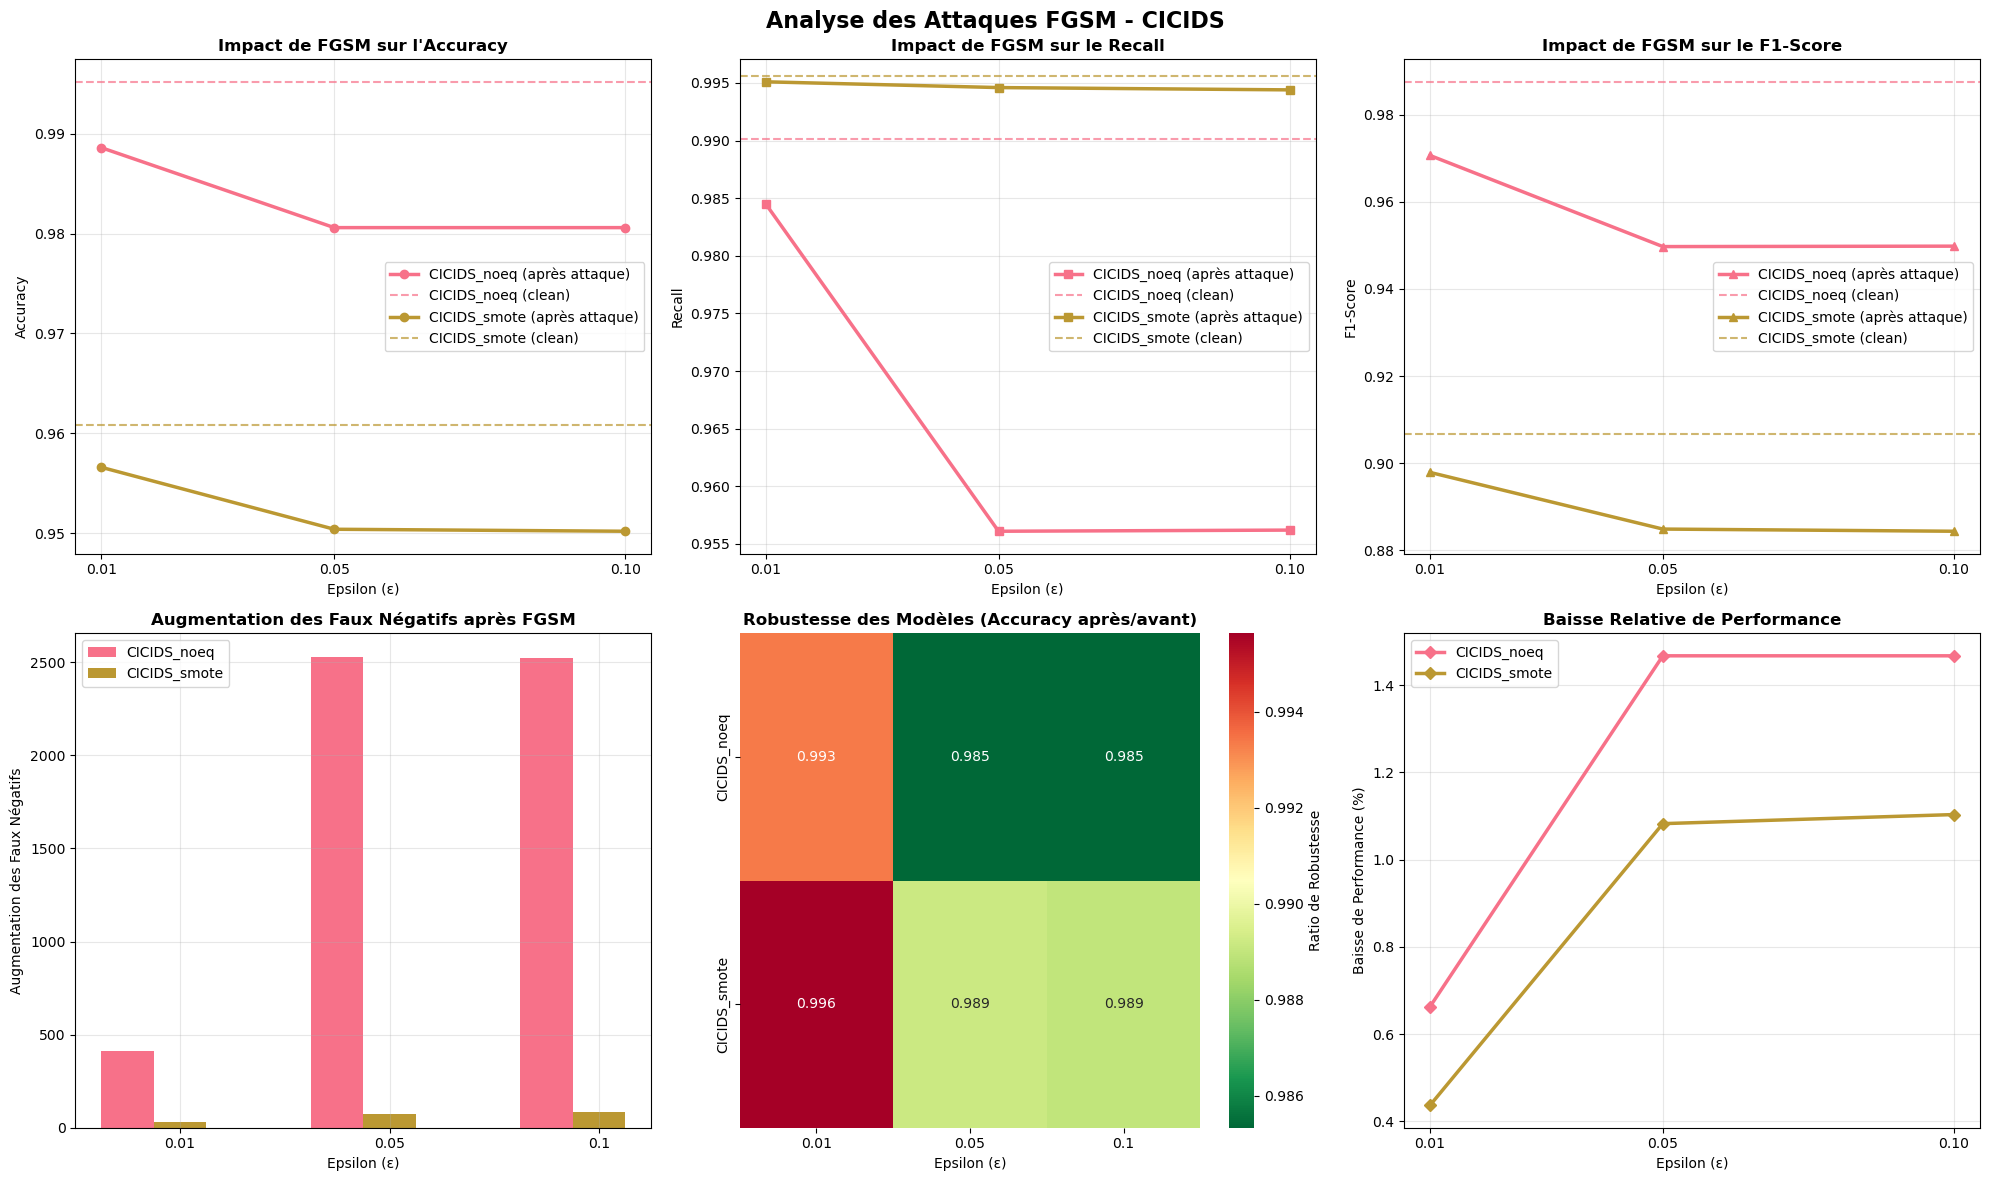

RAPPORT D'ANALYSE FGSM - CICIDS

📊 CICIDS_noeq:
   Accuracy: 0.9952 → 0.9806 (Δ: 0.0146)
   Recall:   0.9901 → 0.9562 (Δ: 0.0339)
   F1-Score: 0.9875 → 0.9498 (Δ: 0.0377)
   Faux Négatifs: 741 → 3262 (+2521)
   Robustesse: 98.53%

📊 CICIDS_smote:
   Accuracy: 0.9608 → 0.9502 (Δ: 0.0106)
   Recall:   0.9956 → 0.9944 (Δ: 0.0012)
   F1-Score: 0.9068 → 0.8844 (Δ: 0.0224)
   Faux Négatifs: 331 → 414 (+83)
   Robustesse: 98.90%


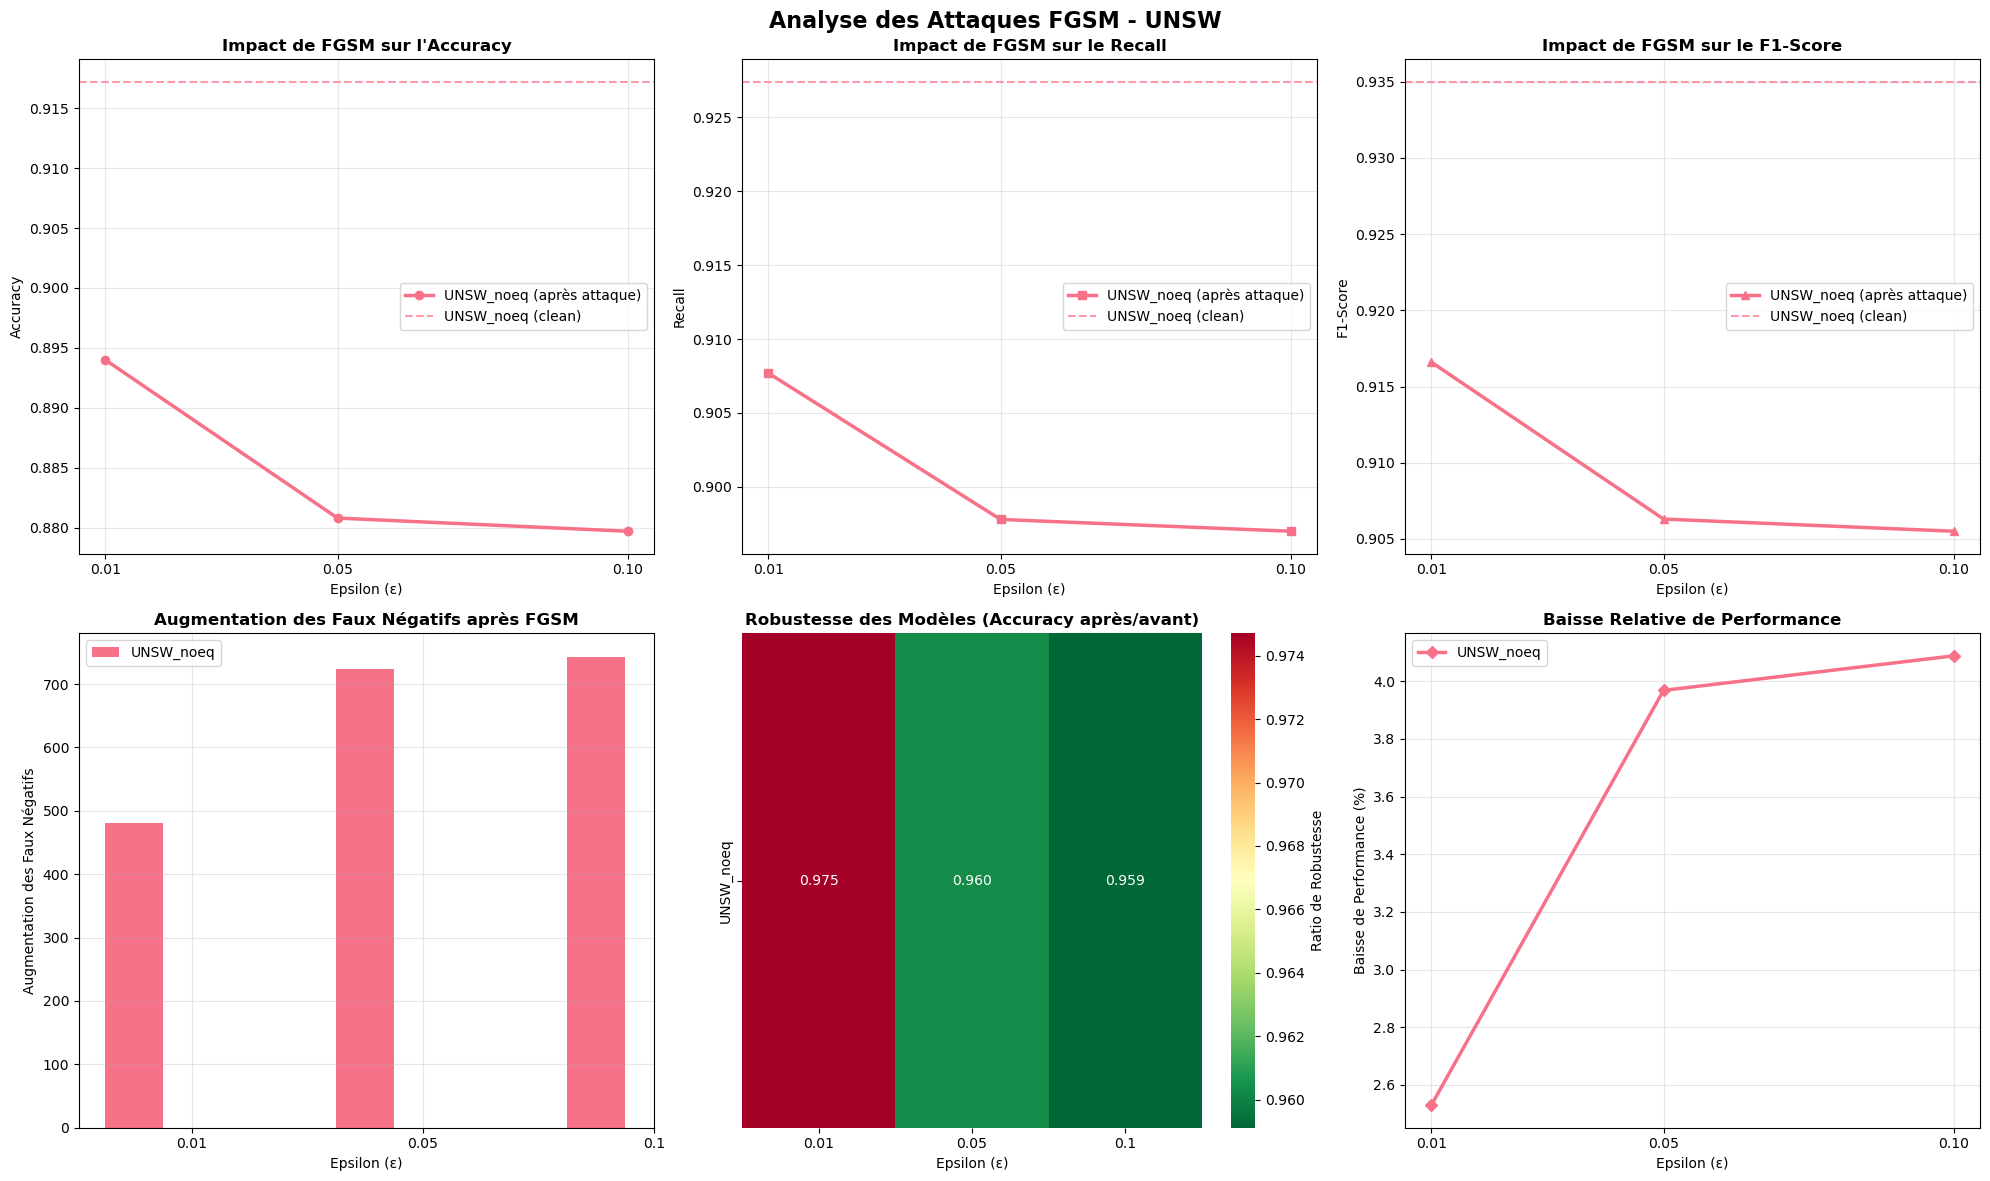

RAPPORT D'ANALYSE FGSM - UNSW

📊 UNSW_noeq:
   Accuracy: 0.9172 → 0.8797 (Δ: 0.0375)
   Recall:   0.9274 → 0.8970 (Δ: 0.0304)
   F1-Score: 0.9350 → 0.9055 (Δ: 0.0295)
   Faux Négatifs: 1775 → 2518 (+743)
   Robustesse: 95.91%


NameError: name 'results_dict' is not defined

In [63]:
from fonctions.visualisation_attaque_plot import plot_fgsm_results_comparison

plot_fgsm_results_comparison(
    results_dict=results_dict,
    model_names=['CICIDS_noeq', 'CICIDS_smote'],
    dataset_name='CICIDS',
    output_dir='../analysis'
)

---

# US Feature Perturbation (RF & Decision Tree)

Dans cette partie, nous appliquons la première attaque adversariale du projet :  
**l’attaque par perturbation de caractéristiques (*Feature Perturbation*)**, spécialement adaptée aux modèles non différentiables comme **Random Forest** et **Decision Tree**.

L’objectif est de modifier légèrement certaines *features critiques* (déterminées par l’importance des features du modèle) afin de :

- réduire la capacité du modèle à détecter les attaques (classe 1),
- augmenter les faux négatifs,
- tout en gardant un trafic réseau **réaliste et plausible**.

Cette attaque consiste à appliquer une petite variation contrôlée (par exemple –5%) sur les `top-k` features les plus utilisées par le modèle pour la décision.  
Cela permet d'évaluer la **vulnérabilité du modèle** face à de faibles manipulations, tout en restant dans le cadre des perturbations réalistes requises par le sujet.

Nous allons donc :
1. Identifier les features les plus importantes du modèle.
2. Générer des exemples adversariaux via une perturbation contrôlée.
3. Comparer les performances avant/après attaque.
4. Mesurer le taux d’évasion obtenu.


In [64]:
from fonctions.feature_attack import feature_perturbation_realistic_rf_cicids, feature_perturbation_rf_universal
from pprint import pprint
from fonctions.model_rf import load_model


# 📌 1. CICIDS2017 — Random Forest

## 🔹 a) CICIDS — RF non équilibré

In [166]:
immutable_mask_rf_c = get_immutable_mask_for_cicids_final(X_train_c.columns)
rf_model_noeq_c = load_model("../models/RF/CICIDS/no_balancing/random_forest_baseline.pkl")


# 3) Bornes TRAIN
min_vals_c = X_train_c.values.min(axis=0)
max_vals_c = X_train_c.values.max(axis=0)

# 4) Attaque Feature Perturbation
X_adv_cicids_noeq, min_c_eff_noeq, max_c_eff_noeq = feature_perturbation_rf_universal(
    model=rf_model_noeq_c,
    X_test_real=X_test_c.values,
    y_test=y_test_c.values.reshape(-1),
    min_vals=min_vals_c,
    max_vals=max_vals_c,
    immutable_mask=immutable_mask_rf_c,
    feature_names=X_train_c.columns,
    max_ratio=0.05,
    n_features=5,
    seed=42,
    output_dir="../attacks/feature_perturbation/RF/CICIDS/no_balancing"
)

📁 Modèle chargé depuis : ../models/RF/CICIDS/no_balancing/random_forest_baseline.pkl
📌 Dataset détecté : CICIDS
🔍 Features modifiées : [41, 39, 52, 42, 12]
📁 X_adv sauvegardé dans : ..\attacks\feature_perturbation\RF\CICIDS\no_balancing


## Interpretation :
Le modèle non équilibré obtient d’excellentes performances en conditions normales grâce à la forte dominance du trafic *Benign*.  
Mais l’attaque Feature Perturbation entraîne :

- Une forte augmentation des **faux négatifs**
- Une chute du **recall**
- Plusieurs milliers de **prédictions modifiées**

➡️ **L’attaque est extrêmement efficace.**  
➡️ Le modèle est clairement vulnérable malgré son excellente performance initiale.

---

## 🔹 b) CICIDS — RF équilibré (SMOTE)

In [167]:
immutable_mask_rf_c = get_immutable_mask_for_cicids_final(X_smote_cicids.columns)
rf_model_cicids = load_model("../models/RF/CICIDS/after_smote/random_forest_baseline.pkl")

# 3) calcul min/max sur TRAIN SMOTE
min_vals_c = X_smote_cicids.values.min(axis=0)
max_vals_c = X_smote_cicids.values.max(axis=0)

# 4) ATTACK — appel universel
X_adv_cicids_smote, min_c_eff_smote, max_c_eff_smote = feature_perturbation_rf_universal(
    model=rf_model_cicids,
    X_test_real=X_test_c.values,
    y_test=y_test_c.values.reshape(-1),
    min_vals=min_vals_c,
    max_vals=max_vals_c,
    immutable_mask=immutable_mask_rf_c,
    feature_names=X_smote_cicids.columns,
    max_ratio=0.05,
    n_features=5,
    seed=42,
    output_dir="../attacks/feature_perturbation/RF/CICIDS/after_smote"
)

📁 Modèle chargé depuis : ../models/RF/CICIDS/after_smote/random_forest_baseline.pkl
📌 Dataset détecté : CICIDS
🔍 Features modifiées : [11, 6, 52, 40, 39]
📁 X_adv sauvegardé dans : ..\attacks\feature_perturbation\RF\CICIDS\after_smote


## Interpretation : 
SMOTE améliore légèrement la qualité globale du modèle en conditions normales.  
Cependant :

- Le recall chute fortement après attaque  
- Les FN explosent  
- Plus de 10 000 prédictions changent

➡️ **Le RF SMOTE est encore plus vulnérable que le RF non équilibré.**  
➡️ SMOTE lisse la frontière de décision, ce qui rend le modèle plus sensible aux perturbations.

---

# 📌 2. CICIDS2017 — Decision Tree

## 🔹 a) CICIDS — DT non équilibré

In [109]:
from fonctions.feature_attack import run_feature_perturbation_attack
dt_model_noeq_c = load_model("../models/DT/CICIDS/no_balancing/random_forest_baseline.pkl")

results_dt_noeq_c = run_feature_perturbation_attack(
    dt_model_noeq_c,
    X_test_c,
    y_test_c,
    n_features=5,
    epsilon=0.1,
    output_dir="../attacks/feature_perturbation/DT/CICIDS/no_balancing/"
)


pprint(results_dt_noeq_c)

📁 Modèle chargé depuis : ../models/DT/CICIDS/no_balancing/random_forest_baseline.pkl
🔍 Features perturbées : ['Total Length of Fwd Packets', 'Fwd Packet Length Std', 'Average Packet Size', 'Packet Length Std', 'Bwd Packet Length Std']
{'diff_predictions': 42997,
 'fn_after': 33055,
 'fn_before': 14073,
 'fn_increase': 18982,
 'metrics_after': {'accuracy': 0.8624498301945045,
                   'f1': 0.607867154665943,
                   'recall': 0.5562670318016458},
 'metrics_before': {'accuracy': 0.9615725018009674,
                    'f1': 0.8899952863539948,
                    'recall': 0.8110829205428698},
 'top_features': ['Total Length of Fwd Packets',
                  'Fwd Packet Length Std',
                  'Average Packet Size',
                  'Packet Length Std',
                  'Bwd Packet Length Std']}


## Interpretation :
Avant l’attaque, le DT est déjà bien moins performant que le RF :  
- recall plus faible  
- FN élevés  

Après l’attaque :
- recall s’effondre  
- FN explosent (+19 000)  
- +40 000 prédictions changées  

➡️ **Attaque dévastatrice.**  
➡️ Le DT est extrêmement fragile.

---

## 🔹 b) CICIDS — DT équilibré (SMOTE)

In [108]:
dt_model_smote_c = load_model("../models/DT/CICIDS/after_smote/random_forest_baseline.pkl")

results_dt_smote_c = run_feature_perturbation_attack(
    dt_model_smote_c,
    X_test_c,
    y_test_c,
    n_features=5,
    epsilon=0.1,
    output_dir="../attacks/feature_perturbation/DT/UNSW/after_smote/"
)

pprint(results_dt_smote_c)


📁 Modèle chargé depuis : ../models/DT/CICIDS/after_smote/random_forest_baseline.pkl
🔍 Features perturbées : ['Flow Bytes/s', 'Avg Fwd Segment Size', 'Fwd IAT Std', 'Init_Win_bytes_backward', 'Destination Port']
{'diff_predictions': 121676,
 'fn_after': 17832,
 'fn_before': 4,
 'fn_increase': 17828,
 'metrics_after': {'accuracy': 0.41096789132448286,
                   'f1': 0.33109239278107444,
                   'recall': 0.7606218033909227},
 'metrics_before': {'accuracy': 0.1980266543171761,
                    'f1': 0.32338084911947107,
                    'recall': 0.9999463036795404},
 'top_features': ['Flow Bytes/s',
                  'Avg Fwd Segment Size',
                  'Fwd IAT Std',
                  'Init_Win_bytes_backward',
                  'Destination Port']}


## Interpretation :
C’est le pire cas observé :

- accuracy très faible même avant attaque  
- modèle totalement biaisé  
- l’attaque inverse complètement son comportement : les FN explosent brutalement

➡️ **Modèle inutilisable** avant et après attaque.  
➡️ SMOTE + DT = combinaison catastrophique.

---

# 📌 3. UNSW-NB15 — Random Forest

## 🔹 a) UNSW — RF non équilibré

In [23]:
from fonctions.feature_attack import get_immutable_mask_unsw_RF, feature_perturbation_rf_universal
from fonctions.model_rf import load_model

In [24]:
immutable_mask_rf_u = get_immutable_mask_unsw_RF(X_train_u.columns)

rf_model_noeq_u = load_model("../models/RF/UNSW/no_balancing/random_forest_baseline.pkl")

# y_test doit être 1D
y_test_u_1d = y_test_u.values.reshape(-1)

X_adv_unsw, min_u_eff, max_u_eff = feature_perturbation_rf_universal(
    model=rf_model_noeq_u,
    X_test_real=X_test_u.values,
    y_test=y_test_u.values.reshape(-1),
    min_vals=X_train_u.values.min(axis=0),
    max_vals=X_train_u.values.max(axis=0),
    immutable_mask=immutable_mask_rf_u,
    feature_names=X_test_u.columns,
    max_ratio=0.02,
    n_features=5,
    seed=42,
    output_dir="../attacks/feature_perturbation/RF/UNSW/no_balancing"
)

📁 Modèle chargé depuis : ../models/RF/UNSW/no_balancing/random_forest_baseline.pkl
📌 Dataset détecté : UNSW
🔍 Features modifiées : [6, 19, 3, 18, 0]
📁 X_adv sauvegardé dans : ..\attacks\feature_perturbation\RF\UNSW\no_balancing


## Interpretation : 
Contrairement à CICIDS, UNSW réagit différemment :

- recall augmente après l’attaque  
- FN diminuent  
- accuracy diminue légèrement  
- +2 700 prédictions modifiées

Cela signifie que les perturbations déplacent certaines attaques borderline dans une zone plus facilement détectable.

➡️ **L’attaque est peu efficace sur UNSW RF non équilibré.**  
➡️ Le comportement est très différent de CICIDS.

---

# 📌 4. UNSW-NB15 — Decision Tree

## 🔹 a) UNSW — DT non équilibré

In [105]:
dt_model_noeq_u = load_model("../models/DT/UNSW/no_balancing/random_forest_baseline.pkl")

results_dt_noeq_u = run_feature_perturbation_attack(
    dt_model_noeq_u,
    X_test_u,
    y_test_u,
    n_features=5,
    epsilon=0.1,
    output_dir="../attacks/feature_perturbation/DT/UNSW/no_balancing/"
)

pprint(results_dt_noeq_u)


📁 Modèle chargé depuis : ../models/DT/UNSW/no_balancing/random_forest_baseline.pkl
🔍 Features perturbées : ['spkts', 'sbytes', 'sload', 'tcprtt', 'dload']
{'diff_predictions': 9641,
 'fn_after': 6712,
 'fn_before': 359,
 'fn_increase': 6353,
 'metrics_after': {'accuracy': 0.6560506209467798,
                   'f1': 0.7303083954378886,
                   'recall': 0.7254693443494622},
 'metrics_before': {'accuracy': 0.8694830257043086,
                    'f1': 0.906474008014901,
                    'recall': 0.9853163728577856},
 'top_features': ['spkts', 'sbytes', 'sload', 'tcprtt', 'dload']}


## Interpretation 
Avant attaque : performances modestes mais cohérentes.  
Après attaque :

- recall baisse (95% → 71%)
- FN augmentent fortement (+6500)
- accuracy chute de ~20%
- presque 10 000 prédictions changées

➡️ **Attaque efficace**, même si moins destructrice que sur CICIDS.  
➡️ Le DT reste largement plus fragile que le RF.

---


# US - Attaque Substitut



In [57]:
from fonctions.transferability_utils import evaluate_transferability_RF, save_transferability_results

rf_model = "../models/RF/CICIDS/no_balancing/random_forest_baseline.pkl"
X_clean = "../data/splits/cicids/X_test.csv"
y_clean = "../data/splits/cicids/y_test.csv"
X_adv   = "../attacks/FGSM/CICIDS/no_balancing/eps_0.05/X_adv_normalized.npy"
SAVE_DIR = "../attacks/substitut_attack/CICIDS/no_balancing/eps_0.05"
EPSILON = 0.05

results = evaluate_transferability_RF(
    rf_model_path=rf_model,      
    X_clean_path=X_clean,
    y_clean_path=y_clean,
    X_adv_path=X_adv,
    save_dir=SAVE_DIR
)
save_transferability_results(results, SAVE_DIR, epsilon=EPSILON)


rf_model = "../models/RF/CICIDS/after_smote/random_forest_baseline.pkl"
X_clean = "../data/splits/cicids/X_test.csv"
y_clean = "../data/splits/cicids/y_test.csv"
X_adv   = "../attacks/FGSM/CICIDS/after_smote/eps_0.05/X_adv_normalized.npy"
SAVE_DIR = "../attacks/substitut_attack/CICIDS/after_smote/eps_0.05"
results = evaluate_transferability_RF(
    rf_model_path=rf_model,      
    X_clean_path=X_clean,
    y_clean_path=y_clean,
    X_adv_path=X_adv,
    save_dir=SAVE_DIR
)
save_transferability_results(results, SAVE_DIR, epsilon=EPSILON)

rf_model = "../models/RF/UNSW/no_balancing/random_forest_baseline.pkl"
X_clean = "../data/splits/unsw/X_test.csv"
y_clean = "../data/splits/unsw/y_test.csv"
X_adv   = "../attacks/FGSM/UNSW/no_balancing/eps_0.05/X_adv_normalized.npy"
SAVE_DIR = "../attacks/substitut_attack/UNSW/no_balancing/eps_0.05"
results = evaluate_transferability_RF(
    rf_model_path=rf_model,      
    X_clean_path=X_clean,
    y_clean_path=y_clean,
    X_adv_path=X_adv,
    save_dir=SAVE_DIR
)
save_transferability_results(results, SAVE_DIR, epsilon=EPSILON)

📁 X_adv substitute sauvegardé dans : ../attacks/substitut_attack/CICIDS/no_balancing/eps_0.05\X_adv_substitute.npy

📁 Résultats sauvegardés dans : ../attacks/substitut_attack/CICIDS/no_balancing/eps_0.05

📁 X_adv substitute sauvegardé dans : ../attacks/substitut_attack/CICIDS/after_smote/eps_0.05\X_adv_substitute.npy

📁 Résultats sauvegardés dans : ../attacks/substitut_attack/CICIDS/after_smote/eps_0.05

📁 X_adv substitute sauvegardé dans : ../attacks/substitut_attack/UNSW/no_balancing/eps_0.05\X_adv_substitute.npy

📁 Résultats sauvegardés dans : ../attacks/substitut_attack/UNSW/no_balancing/eps_0.05



---

# Attaque par gradient Free based Decision

# 🧠 5. Comparaison globale

## ⭐ RF vs DT
- **RF** = beaucoup plus stable, meilleure robustesse  
- **DT** = modèle très vulnérable à toute perturbation  
- **Aléa + rigidité** du DT le rend extrêmement sensible  
- RF amortit les perturbations grâce à l’agrégation d’arbres

➡️ **RF est nettement plus adapté à un IDS que DT.**

---

## ⭐ CICIDS vs UNSW
- **CICIDS** réagit fortement à l’attaque :  
  → explosion des FN  
  → baisse massive du recall  
  → vulnérabilité importante

- **UNSW** réagit différemment :  
  → la perturbation peut améliorer temporairement le recall  
  → modèle moins sensible, plus bruité  
  → architecture réseau beaucoup plus variée

➡️ **UNSW est plus résistant aux Feature Perturbations que CICIDS.**

---

# 🧩 6. Conclusion générale

L’attaque Feature Perturbation révèle plusieurs points clés :

1. **Les IDS basés sur RF sont vulnérables, mais nettement moins que ceux basés sur DT.**
2. **CICIDS est plus sensible aux perturbations que UNSW**, probablement en raison de la structure plus propre du dataset.
3. **SMOTE améliore les performances normales mais dégrade la robustesse adversariale**, en lissant la frontière de décision.
4. **Un modèle performant en conditions standards n’est pas nécessairement robuste face aux attaques adversariales.**
5. **Les faux négatifs (FN) sont l’indicateur clé** : une explosion de FN après attaque signifie que l’IDS peut être contourné facilement.

Ces résultats montrent qu’un IDS doit être complété par :
- des techniques d’entraînement adversarial,
- une sélection de features plus robuste,
- et des mécanismes de détection hybrides.

L’attaque Feature Perturbation démontre clairement que la sécurité d’un IDS basé sur le machine learning ne doit pas être évaluée uniquement sur les métriques classiques, mais également sur sa **résilience face à des perturbations malveillantes**.


# 🔍 US14 — Contrôle de plausibilité des perturbations

L’objectif de cette user story est de vérifier si les perturbations générées par les attaques adversariales restent plausibles du point de vue réseau.  
Pour cela, nous comparons les valeurs originales de `X_test` avec les versions perturbées `X_adv` (Feature Perturbation ou FGSM) et nous contrôlons notamment :

- les valeurs devenues négatives (impossibles pour des bytes, packets, durées…)
- les valeurs dépassant le maximum observé dans les données propres
- la présence éventuelle de valeurs NaN
- l’intensité globale des perturbations (distances L2 et L∞)


In [58]:
import numpy as np
from fonctions.plausibility import check_plausibility_RF, compute_plausibility_stats, evaluate_plausibility

In [170]:
stats_noeq, verdict_noeq = check_plausibility_RF(
    X_clean=X_test_c.values,
    X_adv=X_adv_cicids_noeq,
    min_vals=min_c_eff_noeq,
    max_vals=max_c_eff_noeq,
    output_dir="../attacks/feature_perturbation/RF/CICIDS/no_balancing"
)


📌 Dataset détecté pour plausibility : CICIDS
✔️ Seuil L2 utilisé    : 10
✔️ Seuil L∞ utilisé    : 1500

🔍 Résultats du contrôle de plausibilité :
{'l2_distance_mean': 3.7184849817968377, 'l_inf_max': 101.8540982228792, 'nb_negative': 0, 'nb_nan': 0, 'nb_above_max': 0}

📢 VERDICT DE PLAUSIBILITÉ
---------------------------
✅ L’attaque est RÉALISTE.

📁 Rapport sauvegardé dans : ..\attacks\feature_perturbation\RF\CICIDS\no_balancing


In [171]:
stats, verdict = check_plausibility_RF(
    X_clean=X_test_c.values,
    X_adv=X_adv_cicids_smote,
    min_vals=X_smote_cicids.min(axis=0).values,
    max_vals=X_smote_cicids.max(axis=0).values,
    output_dir="../attacks/feature_perturbation/RF/CICIDS/after_smote"
)



📌 Dataset détecté pour plausibility : CICIDS
✔️ Seuil L2 utilisé    : 20
✔️ Seuil L∞ utilisé    : 150

🔍 Résultats du contrôle de plausibilité :
{'l2_distance_mean': 3.7196991272435276, 'l_inf_max': 101.85573309715792, 'nb_negative': 0, 'nb_nan': 0, 'nb_above_max': 0}

📢 VERDICT DE PLAUSIBILITÉ
---------------------------
✅ L’attaque est RÉALISTE.

📁 Rapport sauvegardé dans : ..\attacks\feature_perturbation\RF\CICIDS\after_smote


In [28]:
stats_u, verdict_u = check_plausibility_RF(
    X_clean=X_test_u.values,
    X_adv=X_adv_unsw,
    min_vals=min_u_eff,
    max_vals=max_u_eff,
    output_dir="../attacks/feature_perturbation/RF/UNSW/no_balancing"
)

📌 Dataset détecté pour plausibility : UNSW
✔️ Seuil L2 utilisé    : 20
✔️ Seuil L∞ utilisé    : 600

🔍 Résultats du contrôle de plausibilité :
{'l2_distance_mean': 3.74431088966384, 'l_inf_max': 503.8928457519515, 'nb_negative': 0, 'nb_nan': 0, 'nb_above_max': 0}

📢 VERDICT DE PLAUSIBILITÉ
---------------------------
✅ L’attaque est RÉALISTE.

📁 Rapport sauvegardé dans : ..\attacks\feature_perturbation\RF\UNSW\no_balancing


In [95]:
X_test_mlp_c = np.load("../attacks/FGSM/CICIDS/no_balancing/eps_0.01/X_adv_normalized.npy")
X_adv_real = np.load("../attacks/FGSM/CICIDS/no_balancing/eps_0.01/X_adv_original.npy")
stats, ok = evaluate_plausibility(
    X_clean = scaler.inverse_transform(X_test_mlp_c),  # les données propres réelles
    X_adv   = X_adv_real,                             # attaques réelles
    max_neg=0,
    max_nan=0,
    max_above_max=0,
    l2_threshold=0.5,
    linf_threshold=5.0,
    save_path="../attacks/FGSM/CICIDS/no_balancing/eps_0.01/plausibility.json"
)

X_test_mlp_c = np.load("../attacks/FGSM/CICIDS/no_balancing/eps_0.05/X_adv_normalized.npy")
X_adv_real = np.load("../attacks/FGSM/CICIDS/no_balancing/eps_0.05/X_adv_original.npy")
stats, ok = evaluate_plausibility(
    X_clean = scaler.inverse_transform(X_test_mlp_c),  # les données propres réelles
    X_adv   = X_adv_real,                             # attaques réelles
    max_neg=0,
    max_nan=0,
    max_above_max=0,
    l2_threshold=0.5,
    linf_threshold=5.0,
    save_path="../attacks/FGSM/CICIDS/no_balancing/eps_0.05/plausibility.json"
)

X_test_mlp_c = np.load("../attacks/FGSM/CICIDS/no_balancing/eps_0.1/X_adv_normalized.npy")
X_adv_real = np.load("../attacks/FGSM/CICIDS/no_balancing/eps_0.1/X_adv_original.npy")
stats, ok = evaluate_plausibility(
    X_clean = scaler.inverse_transform(X_test_mlp_c),  # les données propres réelles
    X_adv   = X_adv_real,                             # attaques réelles
    max_neg=0,
    max_nan=0,
    max_above_max=0,
    l2_threshold=0.5,
    linf_threshold=5.0,
    save_path="../attacks/FGSM/CICIDS/no_balancing/eps_0.1/plausibility.json"
)


🔍 Résultats du contrôle de plausibilité :
{'l2_distance_mean': 1.6022230076887969e-18, 'l_inf_max': 7.105427357601002e-15, 'nb_negative': 0, 'nb_nan': 0, 'nb_above_max': 0}

🧠 Interprétation :
• L2 distance moyenne : 0.0000
• L_inf max           : 0.0000

✔ Attaque réaliste.

📁 Stats sauvegardées dans : ../attacks/FGSM/CICIDS/no_balancing/eps_0.01/plausibility.json

🔍 Résultats du contrôle de plausibilité :
{'l2_distance_mean': 1.1989234572479605e-18, 'l_inf_max': 7.105427357601002e-15, 'nb_negative': 0, 'nb_nan': 0, 'nb_above_max': 0}

🧠 Interprétation :
• L2 distance moyenne : 0.0000
• L_inf max           : 0.0000

✔ Attaque réaliste.

📁 Stats sauvegardées dans : ../attacks/FGSM/CICIDS/no_balancing/eps_0.05/plausibility.json

🔍 Résultats du contrôle de plausibilité :
{'l2_distance_mean': 1.0928684960255906e-18, 'l_inf_max': 7.105427357601002e-15, 'nb_negative': 0, 'nb_nan': 0, 'nb_above_max': 0}

🧠 Interprétation :
• L2 distance moyenne : 0.0000
• L_inf max           : 0.0000

✔ Att

In [96]:
X_test_mlp_c = np.load("../attacks/FGSM/CICIDS/after_smote/eps_0.01/X_adv_normalized.npy")
X_adv_real = np.load("../attacks/FGSM/CICIDS/after_smote/eps_0.01/X_adv_original.npy")
stats, ok = evaluate_plausibility(
    X_clean = scaler.inverse_transform(X_test_mlp_c),  # les données propres réelles
    X_adv   = X_adv_real,                             # attaques réelles
    max_neg=0,
    max_nan=0,
    max_above_max=0,
    l2_threshold=0.5,
    linf_threshold=5.0,
    save_path="../attacks/FGSM/CICIDS/after_smote/eps_0.01/plausibility.json"
)

X_test_mlp_c = np.load("../attacks/FGSM/CICIDS/after_smote/eps_0.05/X_adv_normalized.npy")
X_adv_real = np.load("../attacks/FGSM/CICIDS/after_smote/eps_0.05/X_adv_original.npy")
stats, ok = evaluate_plausibility(
    X_clean = scaler.inverse_transform(X_test_mlp_c),  # les données propres réelles
    X_adv   = X_adv_real,                             # attaques réelles
    max_neg=0,
    max_nan=0,
    max_above_max=0,
    l2_threshold=0.5,
    linf_threshold=5.0,
    save_path="../attacks/FGSM/CICIDS/after_smote/eps_0.05/plausibility.json"
)

X_test_mlp_c = np.load("../attacks/FGSM/CICIDS/after_smote/eps_0.1/X_adv_normalized.npy")
X_adv_real = np.load("../attacks/FGSM/CICIDS/after_smote/eps_0.1/X_adv_original.npy")
stats, ok = evaluate_plausibility(
    X_clean = scaler.inverse_transform(X_test_mlp_c),  # les données propres réelles
    X_adv   = X_adv_real,                             # attaques réelles
    max_neg=0,
    max_nan=0,
    max_above_max=0,
    l2_threshold=0.5,
    linf_threshold=5.0,
    save_path="../attacks/FGSM/CICIDS/after_smote/eps_0.1/plausibility.json"
)


🔍 Résultats du contrôle de plausibilité :
{'l2_distance_mean': 2.7104224091001923e-18, 'l_inf_max': 3.552713678800501e-15, 'nb_negative': 0, 'nb_nan': 0, 'nb_above_max': 0}

🧠 Interprétation :
• L2 distance moyenne : 0.0000
• L_inf max           : 0.0000

✔ Attaque réaliste.

📁 Stats sauvegardées dans : ../attacks/FGSM/CICIDS/after_smote/eps_0.01/plausibility.json

🔍 Résultats du contrôle de plausibilité :
{'l2_distance_mean': 5.024754660145128e-18, 'l_inf_max': 3.552713678800501e-15, 'nb_negative': 0, 'nb_nan': 0, 'nb_above_max': 0}

🧠 Interprétation :
• L2 distance moyenne : 0.0000
• L_inf max           : 0.0000

✔ Attaque réaliste.

📁 Stats sauvegardées dans : ../attacks/FGSM/CICIDS/after_smote/eps_0.05/plausibility.json

🔍 Résultats du contrôle de plausibilité :
{'l2_distance_mean': 4.955415222747837e-18, 'l_inf_max': 3.552713678800501e-15, 'nb_negative': 0, 'nb_nan': 0, 'nb_above_max': 0}

🧠 Interprétation :
• L2 distance moyenne : 0.0000
• L_inf max           : 0.0000

✔ Attaque

In [97]:
X_test_mlp_u = np.load("../attacks/FGSM/UNSW/no_balancing/eps_0.01/X_adv_normalized.npy")
X_adv_real = np.load("../attacks/FGSM/UNSW/no_balancing/eps_0.01/X_adv_original.npy")
stats, ok = evaluate_plausibility(
    X_clean = scaler_u.inverse_transform(X_test_mlp_u),  # les données propres réelles
    X_adv   = X_adv_real,                             # attaques réelles
    max_neg=0,
    max_nan=0,
    max_above_max=0,
    l2_threshold=0.5,
    linf_threshold=5.0,
    save_path="../attacks/FGSM/UNSW/no_balancing/eps_0.01/plausibility.json"
)
X_test_mlp_u = np.load("../attacks/FGSM/UNSW/no_balancing/eps_0.05/X_adv_normalized.npy")
X_adv_real = np.load("../attacks/FGSM/UNSW/no_balancing/eps_0.05/X_adv_original.npy")
stats, ok = evaluate_plausibility(
    X_clean = scaler_u.inverse_transform(X_test_mlp_u),  # les données propres réelles
    X_adv   = X_adv_real,                             # attaques réelles
    max_neg=0,
    max_nan=0,
    max_above_max=0,
    l2_threshold=0.5,
    linf_threshold=5.0,
    save_path="../attacks/FGSM/UNSW/no_balancing/eps_0.05/plausibility.json"
)
X_test_mlp_u = np.load("../attacks/FGSM/UNSW/no_balancing/eps_0.1/X_adv_normalized.npy")
X_adv_real = np.load("../attacks/FGSM/UNSW/no_balancing/eps_0.1/X_adv_original.npy")
stats, ok = evaluate_plausibility(
    X_clean = scaler_u.inverse_transform(X_test_mlp_u),  # les données propres réelles
    X_adv   = X_adv_real,                             # attaques réelles
    max_neg=0,
    max_nan=0,
    max_above_max=0,
    l2_threshold=0.5,
    linf_threshold=5.0,
    save_path="../attacks/FGSM/UNSW/no_balancing/eps_0.1/plausibility.json"
)


🔍 Résultats du contrôle de plausibilité :
{'l2_distance_mean': 2.1199631017750775e-18, 'l_inf_max': 1.7763568394002505e-15, 'nb_negative': 0, 'nb_nan': 0, 'nb_above_max': 0}

🧠 Interprétation :
• L2 distance moyenne : 0.0000
• L_inf max           : 0.0000

✔ Attaque réaliste.

📁 Stats sauvegardées dans : ../attacks/FGSM/UNSW/no_balancing/eps_0.01/plausibility.json

🔍 Résultats du contrôle de plausibilité :
{'l2_distance_mean': 2.7267378965356016e-18, 'l_inf_max': 8.881784197001252e-16, 'nb_negative': 0, 'nb_nan': 0, 'nb_above_max': 0}

🧠 Interprétation :
• L2 distance moyenne : 0.0000
• L_inf max           : 0.0000

✔ Attaque réaliste.

📁 Stats sauvegardées dans : ../attacks/FGSM/UNSW/no_balancing/eps_0.05/plausibility.json

🔍 Résultats du contrôle de plausibilité :
{'l2_distance_mean': 2.572262313089467e-18, 'l_inf_max': 8.881784197001252e-16, 'nb_negative': 0, 'nb_nan': 0, 'nb_above_max': 0}

🧠 Interprétation :
• L2 distance moyenne : 0.0000
• L_inf max           : 0.0000

✔ Attaque

### Résultats CICIDS — Feature Perturbation (RF)

L’analyse montre :
- plusieurs milliers de valeurs négatives
- des dépassements au-delà des maxima naturels
- une perturbation globalement faible (L2 modérée, L∞ < 0.1)

➡️ **Les perturbations ne sont pas plausibles**, ce qui indique que l’attaque est efficace mais pas réaliste en termes de trafic réseau.

### Résultats UNSW — FGSM (MLP)

Le contrôle de plausibilité sur l’attaque FGSM appliquée au MLP UNSW révèle :
- de nombreuses valeurs négatives
- un très grand nombre de valeurs au-dessus des maxima
- une perturbation parfois très forte (L∞ > 10)

➡️ **FGSM produit des perturbations puissantes mais non plausibles**, confirmant que l’attaque exploite fortement les gradients du modèle.

### Conclusion US14

Les attaques adversariales testées modifient correctement les échantillons pour tromper les modèles, mais génèrent souvent des valeurs irréalistes du point de vue réseau.  
Ce contrôle permet de valider que, même si les attaques réussissent à tromper l’IDS, elles ne correspondent pas toujours à un trafic réellement plausible. Cette analyse servira de base à l’US15 pour la génération et le versioning du dataset adversarial.


In [64]:
import numpy as np
import pandas as pd
from fonctions.plausibility import evaluate_plausibility


# ======== Lancement plausibilité ========
stats, ok = evaluate_plausibility(
    X_clean = pd.read_csv("../data/splits/cicids/X_test.csv").values,   # réel
    X_adv = np.load("../attacks/substitut_attack/CICIDS/no_balancing/eps_0.05/X_adv_substitute.npy"),     # substitut réel
    max_neg=0,
    max_nan=0,
    max_above_max=0,
    l2_threshold=0.5,    # même seuils que FGSM si tu veux
    linf_threshold=5.0,
    save_path="../attacks/substitut_attack/CICIDS/no_balancing/eps_0.05/plausibility.json"
)
stats, ok = evaluate_plausibility(
    X_clean = pd.read_csv("../data/splits/cicids/X_test.csv").values,   # réel
    X_adv = np.load("../attacks/substitut_attack/CICIDS/after_smote/eps_0.05/X_adv_substitute.npy"),     # substitut réel
    max_neg=0,
    max_nan=0,
    max_above_max=0,
    l2_threshold=0.5,    # même seuils que FGSM si tu veux
    linf_threshold=5.0,
    save_path="../attacks/substitut_attack/CICIDS/after_smote/eps_0.05/plausibility.json"
)
stats, ok = evaluate_plausibility(
    X_clean = pd.read_csv("../data/splits/unsw/X_test.csv").values,   # réel
    X_adv = np.load("../attacks/substitut_attack/UNSW/no_balancing/eps_0.05/X_adv_substitute.npy"),     # substitut réel
    max_neg=0,
    max_nan=0,
    max_above_max=0,
    l2_threshold=0.5,    # même seuils que FGSM si tu veux
    linf_threshold=5.0,
    save_path="../attacks/substitut_attack/UNSW/no_balancing/eps_0.05/plausibility.json"
)



🔍 Résultats du contrôle de plausibilité :
{'l2_distance_mean': 0.3172901158247933, 'l_inf_max': 72.26360186613672, 'nb_negative': 740, 'nb_nan': 0, 'nb_above_max': 1321668}

🧠 Interprétation :
⚠️ 740 valeurs négatives : non plausible.
⚠️ 1321668 valeurs dépassent le max du dataset.
• L2 distance moyenne : 0.3173
• L_inf max           : 72.2636

❌ Attaque NON réaliste.

📁 Stats sauvegardées dans : ../attacks/substitut_attack/CICIDS/no_balancing/eps_0.05/plausibility.json

🔍 Résultats du contrôle de plausibilité :
{'l2_distance_mean': 0.294100842693334, 'l_inf_max': 73.69565563088588, 'nb_negative': 742, 'nb_nan': 0, 'nb_above_max': 1321365}

🧠 Interprétation :
⚠️ 742 valeurs négatives : non plausible.
⚠️ 1321365 valeurs dépassent le max du dataset.
• L2 distance moyenne : 0.2941
• L_inf max           : 73.6957

❌ Attaque NON réaliste.

📁 Stats sauvegardées dans : ../attacks/substitut_attack/CICIDS/after_smote/eps_0.05/plausibility.json

🔍 Résultats du contrôle de plausibilité :
{'l2_di

In [72]:
from fonctions.plausibility import check_plausibility_RF
plaus_stats, ok = check_plausibility_RF(
    X_clean = pd.read_csv("../data/splits/cicids/X_test.csv").values,     # données propres réelles
    X_adv=np.load("../attacks/decision_based/CICIDS/no_balancing/X_adv.npy"),         # adversarial généré
    min_vals=pd.read_csv("../data/splits/cicids/X_train.csv").values.min(axis=0),
    max_vals=pd.read_csv("../data/splits/cicids/X_train.csv").values.max(axis=0),
    output_dir="../attacks/decision_based/CICIDS/no_balancing/plausibility.json"   # crée automatiquement plausibility.json + txt
)

plaus_stats, ok = check_plausibility_RF(
    X_clean = pd.read_csv("../data/splits/cicids/X_test.csv").values,     # données propres réelles
    X_adv=np.load("../attacks/decision_based/CICIDS/after_smote/X_adv.npy"),         # adversarial généré
    min_vals=pd.read_csv("../data/smote/cicids/X_train_smote.csv").values.min(axis=0),
    max_vals=pd.read_csv("../data/smote/cicids/X_train_smote.csv").values.max(axis=0),
    output_dir="../attacks/decision_based/CICIDS/after_smote/plausibility.json"   # crée automatiquement plausibility.json + txt
)

plaus_stats, ok = check_plausibility_RF(
    X_clean = pd.read_csv("../data/splits/unsw/X_test.csv").values,      # données propres réelles
    X_adv=np.load("../attacks/decision_based/UNSW/no_balancing/X_adv.npy"),         # adversarial généré
    min_vals=pd.read_csv("../data/splits/unsw/X_train.csv").values.min(axis=0),
    max_vals=pd.read_csv("../data/splits/unsw/X_train.csv").values.max(axis=0),
    output_dir="../attacks/decision_based/UNSW/no_balancing/plausibility.json"   # crée automatiquement plausibility.json + txt
)

📌 Dataset détecté pour plausibility : CICIDS
✔️ Seuil L2 utilisé    : 10
✔️ Seuil L∞ utilisé    : 1500

🔍 Résultats du contrôle de plausibilité :
{'l2_distance_mean': 0.00024464550703918244, 'l_inf_max': 0.753114123506277, 'nb_negative': 19720169, 'nb_nan': 0, 'nb_above_max': 2}

📢 VERDICT DE PLAUSIBILITÉ
---------------------------
❌ L’attaque n’est PAS réaliste.

📁 Rapport sauvegardé dans : ..\attacks\decision_based\CICIDS\no_balancing\plausibility.json
📌 Dataset détecté pour plausibility : CICIDS
✔️ Seuil L2 utilisé    : 20
✔️ Seuil L∞ utilisé    : 150

🔍 Résultats du contrôle de plausibilité :
{'l2_distance_mean': 0.0001994441400452763, 'l_inf_max': 0.5147111006155334, 'nb_negative': 19719902, 'nb_nan': 0, 'nb_above_max': 556}

📢 VERDICT DE PLAUSIBILITÉ
---------------------------
❌ L’attaque n’est PAS réaliste.

📁 Rapport sauvegardé dans : ..\attacks\decision_based\CICIDS\after_smote\plausibility.json
📌 Dataset détecté pour plausibility : UNSW
✔️ Seuil L2 utilisé    : 20
✔️ Seuil 

---

# US 15 – Génération et versioning du dataset adversarial

In [78]:
import pandas as pd
from fonctions.utils_adversarial import save_adversarial_dataset


# ============================================================
# 🔹 CHARGER LES SPLITS OFFICIELS (X_test / y_test)
# ============================================================

X_test_cicids = pd.read_csv("../data/splits/CICIDS/X_test.csv")
y_test_cicids = pd.read_csv("../data/splits/CICIDS/y_test.csv").iloc[:, 0]

X_test_unsw = pd.read_csv("../data/splits/UNSW/X_test.csv")
y_test_unsw = pd.read_csv("../data/splits/UNSW/y_test.csv").iloc[:, 0]


# ============================================================
# 🔹 LISTE DE TOUTES LES CONFIGS À TRAITER
# ============================================================

attacks_to_process = [
    
    # ========================================================
    #  ATTAQUE SUBSTITUT  – CICIDS - SANS EQUILIBRAGE
    # ========================================================
    {
        "X_adv_path": "../attacks/substitut_attack/CICIDS/no_balancing/eps_0.05/X_adv_substitute.npy",
        "attack_name": "substitut_attack",
        "model_name": "RF",
        "dataset_name": "CICIDS",
        "balancing": "no_balancing",
        "plausibility_path": "../attacks/substitut_attack/CICIDS/no_balancing/eps_0.05/plausibility.json",
        "X_test": X_test_cicids,
        "y_test": y_test_cicids,
        "epsilon": 0.05
    },

    # ========================================================
    #  ATTAQUE SUBSTITUT  – CICIDS - SMOTE
    # ========================================================
    {
        "X_adv_path": "../attacks/substitut_attack/CICIDS/after_smote/eps_0.05/X_adv_substitute.npy",
        "attack_name": "substitut_attack",
        "model_name": "RF",
        "dataset_name": "CICIDS",
        "balancing": "after_smote",
        "plausibility_path": "../attacks/substitut_attack/CICIDS/after_smote/eps_0.05/plausibility.json",
        "X_test": X_test_cicids,
        "y_test": y_test_cicids,
        "epsilon": 0.05
    },
    # ========================================================
    #  ATTAQUE SUBSTITUT  – UNSW - SANS EQUILIBRAGE
    # ========================================================
    {
        "X_adv_path": "../attacks/substitut_attack/UNSW/no_balancing/eps_0.05/X_adv_substitute.npy",
        "attack_name": "substitut_attack",
        "model_name": "RF",
        "dataset_name": "UNSW",
        "balancing": "no_balancing",
        "plausibility_path": "../attacks/substitut_attack/UNSW/no_balancing/eps_0.05/plausibility.json",
        "X_test": X_test_unsw,
        "y_test": y_test_unsw,
        "epsilon": 0.05
    },

    # ========================================================
    #  ATTAQUE GRADIENT  – CICIDS - SANS EQUILIBRAGE
    # ========================================================
    {
        "X_adv_path": "../attacks/decision_based/CICIDS/no_balancing/X_adv.npy",
        "attack_name": "decision_based",
        "model_name": "RF",
        "dataset_name": "CICIDS",
        "balancing": "no_balancing",
        "plausibility_path": "../attacks/decision_based/CICIDS/no_balancing/plausibility.json/plausibility.json",
        "X_test": X_test_cicids,
        "y_test": y_test_cicids,
        "epsilon": None
    },

    # ========================================================
    #  ATTAQUE GRADIENT  – CICIDS - SMOTE
    # ========================================================
    {
        "X_adv_path": "../attacks/decision_based/CICIDS/after_smote/X_adv.npy",
        "attack_name": "decision_based",
        "model_name": "RF",
        "dataset_name": "CICIDS",
        "balancing": "after_smote",
        "plausibility_path": "../attacks/decision_based/CICIDS/after_smote/plausibility.json/plausibility.json",
        "X_test": X_test_cicids,
        "y_test": y_test_cicids,
        "epsilon": None
    },
    # ========================================================
    #  ATTAQUE GRADIENT  – UNSW - SANS EQUILIBRAGE
    # ========================================================
    {
        "X_adv_path": "../attacks/decision_based/UNSW/no_balancing/X_adv.npy",
        "attack_name": "decision_based",
        "model_name": "RF",
        "dataset_name": "UNSW",
        "balancing": "no_balancing",
        "plausibility_path": "../attacks/decision_based/UNSW/no_balancing/plausibility.json/plausibility.json",
        "X_test": X_test_unsw,
        "y_test": y_test_unsw,
        "epsilon": None
    },



    # ========================================================
    # FEATURE PERTURBATION – RF – CICIDS
    # ========================================================
    {
        "X_adv_path": "../attacks/feature_perturbation/RF/CICIDS/no_balancing/X_adv_real_FP.npy",
        "attack_name": "feature_perturbation",
        "model_name": "RF",
        "dataset_name": "CICIDS",
        "balancing": "no_balancing",
        "plausibility_path": "../attacks/feature_perturbation/RF/CICIDS/no_balancing/plausibility.json",
        "X_test": X_test_cicids,
        "y_test": y_test_cicids,
        "epsilon": None
    },

     # ========================================================
    # FEATURE PERTURBATION – RF – CICIDS
    # ========================================================
    {
        "X_adv_path": "../attacks/feature_perturbation/RF/CICIDS/after_smote/X_adv_real_FP.npy",
        "attack_name": "feature_perturbation",
        "model_name": "RF",
        "dataset_name": "CICIDS",
        "balancing": "after_smote",
        "plausibility_path": "../attacks/feature_perturbation/RF/CICIDS/after_smote/plausibility.json",
        "X_test": X_test_cicids,
        "y_test": y_test_cicids,
        "epsilon": None
    },

    # ========================================================
    # FEATURE PERTURBATION – RF – UNSW
    # ========================================================
    {
        "X_adv_path": "../attacks/feature_perturbation/RF/UNSW/no_balancing/X_adv_real_FP.npy",
        "attack_name": "feature_perturbation",
        "model_name": "RF",
        "dataset_name": "UNSW",
        "balancing": "no_balancing",
        "plausibility_path": "../attacks/feature_perturbation/RF/UNSW/no_balancing/plausibility.json",
        "X_test": X_test_unsw,
        "y_test": y_test_unsw,
        "epsilon": None
    },

     # ========================================================
    # FGSM – MLP – CICIDS (ε = 0.01, 0.05, 0.1) no_balancing
    # ========================================================
    {
        "X_adv_path": "../attacks/FGSM/CICIDS/no_balancing/eps_0.01/X_adv_normalized.npy",
        "attack_name": "FGSM",
        "model_name": "MLP",
        "dataset_name": "CICIDS",
        "balancing": "no_balancing",
        "plausibility_path": "../attacks/FGSM/CICIDS/no_balancing/eps_0.01/plausibility.json",
        "X_test": X_test_cicids,
        "y_test": y_test_cicids,
        "epsilon": 0.01
    },
    {
        "X_adv_path": "../attacks/FGSM/CICIDS/no_balancing/eps_0.05/X_adv_normalized.npy",
        "attack_name": "FGSM",
        "model_name": "MLP",
        "dataset_name": "CICIDS",
        "balancing": "no_balancing",
        "plausibility_path": "../attacks/FGSM/CICIDS/no_balancing/eps_0.05/plausibility.json",
        "X_test": X_test_cicids,
        "y_test": y_test_cicids,
        "epsilon": 0.05
    },
    {
        "X_adv_path": "../attacks/FGSM/CICIDS/no_balancing/eps_0.1/X_adv_normalized.npy",
        "attack_name": "FGSM",
        "model_name": "MLP",
        "dataset_name": "CICIDS",
        "balancing": "no_balancing",
        "plausibility_path": "../attacks/FGSM/CICIDS/no_balancing/eps_0.1/plausibility.json",
        "X_test": X_test_cicids,
        "y_test": y_test_cicids,
        "epsilon": 0.1
    },
    
    # ========================================================
    # FGSM – MLP – CICIDS (ε = 0.01, 0.05, 0.1) after_smote
    # ========================================================
    {
        "X_adv_path": "../attacks/FGSM/CICIDS/after_smote/eps_0.01/X_adv_normalized.npy",
        "attack_name": "FGSM",
        "model_name": "MLP",
        "dataset_name": "CICIDS",
        "balancing": "after_smote",
        "plausibility_path": "../attacks/FGSM/CICIDS/after_smote/eps_0.01/plausibility.json",
        "X_test": X_test_cicids,
        "y_test": y_test_cicids,
        "epsilon": 0.01
    },

   {
        "X_adv_path": "../attacks/FGSM/CICIDS/after_smote/eps_0.05/X_adv_normalized.npy",
        "attack_name": "FGSM",
        "model_name": "MLP",
        "dataset_name": "CICIDS",
        "balancing": "after_smote",
        "plausibility_path": "../attacks/FGSM/CICIDS/after_smote/eps_0.05/plausibility.json",
        "X_test": X_test_cicids,
        "y_test": y_test_cicids,
        "epsilon": 0.05
    },
    {
        "X_adv_path": "../attacks/FGSM/CICIDS/after_smote/eps_0.1/X_adv_normalized.npy",
        "attack_name": "FGSM",
        "model_name": "MLP",
        "dataset_name": "CICIDS",
        "balancing": "after_smote",
        "plausibility_path": "../attacks/FGSM/CICIDS/after_smote/eps_0.1/plausibility.json",
        "X_test": X_test_cicids,
        "y_test": y_test_cicids,
        "epsilon": 0.1
    },

    # ========================================================
    # FGSM – MLP – UNSW (ε = 0.01, 0.05, 0.1)
    # ========================================================
    {
        "X_adv_path": "../attacks/FGSM/UNSW/no_balancing/eps_0.01/X_adv_normalized.npy",
        "attack_name": "FGSM",
        "model_name": "MLP",
        "dataset_name": "UNSW",
        "balancing": "no_balancing",
        "plausibility_path": "../attacks/FGSM/UNSW/no_balancing/eps_0.01/plausibility.json",
        "X_test": X_test_unsw,
        "y_test": y_test_unsw,
        "epsilon": 0.01
    },
    {
        "X_adv_path": "../attacks/FGSM/UNSW/no_balancing/eps_0.05/X_adv_normalized.npy",
        "attack_name": "FGSM",
        "model_name": "MLP",
        "dataset_name": "UNSW",
        "balancing": "no_balancing",
        "plausibility_path": "../attacks/FGSM/UNSW/no_balancing/eps_0.05/plausibility.json",
        "X_test": X_test_unsw,
        "y_test": y_test_unsw,
        "epsilon": 0.05
    },

    {
        "X_adv_path": "../attacks/FGSM/UNSW/no_balancing/eps_0.1/X_adv_normalized.npy",
        "attack_name": "FGSM",
        "model_name": "MLP",
        "dataset_name": "UNSW",
        "balancing": "no_balancing",
        "plausibility_path": "../attacks/FGSM/UNSW/no_balancing/eps_0.1/plausibility.json",
        "X_test": X_test_unsw,
        "y_test": y_test_unsw,
        "epsilon": 0.1
    }


]


# ============================================================
# 🔹 BOUCLE PRINCIPALE – SAUVEGARDE US15
# ============================================================

print("\n========== US15 : Sauvegarde des datasets adversariaux ==========\n")

for config in attacks_to_process:

    print(f"➡ Traitement : {config['attack_name']} – {config['model_name']} – "
          f"{config['dataset_name']} – {config['balancing']} – eps={config['epsilon']}")

    save_adversarial_dataset(
        X_adv_path=config["X_adv_path"],
        X_test=config["X_test"],
        y_test=config["y_test"],
        attack_name=config["attack_name"],
        model_name=config["model_name"],
        dataset_name=config["dataset_name"],
        balancing=config["balancing"],
        plausibility_path=config["plausibility_path"],
        epsilon=config["epsilon"]
    )

    print("✔ Terminé\n")


print("\n============== US15 TERMINÉE : Tous les datasets sont sauvegardés ==============\n")


========== US15 : Sauvegarde des datasets adversariaux ==========

➡ Traitement : decision_based – RF – CICIDS – no_balancing – eps=None
📥 Loaded X_adv (NPY) from ../attacks/decision_based/CICIDS/no_balancing/X_adv.npy
✅ Dataset adversarial sauvegardé dans : ../data/adversarial\CICIDS\decision_based\RF\no_balancing
✔ Terminé

➡ Traitement : decision_based – RF – CICIDS – after_smote – eps=None
📥 Loaded X_adv (NPY) from ../attacks/decision_based/CICIDS/after_smote/X_adv.npy
✅ Dataset adversarial sauvegardé dans : ../data/adversarial\CICIDS\decision_based\RF\after_smote
✔ Terminé

➡ Traitement : decision_based – RF – UNSW – no_balancing – eps=None
📥 Loaded X_adv (NPY) from ../attacks/decision_based/UNSW/no_balancing/X_adv.npy
✅ Dataset adversarial sauvegardé dans : ../data/adversarial\UNSW\decision_based\RF\no_balancing
✔ Terminé


============== US15 TERMINÉE : Tous les datasets sont sauvegardés ==============



In [27]:
from fonctions.evaluation_adv import evaluate_us16_and_save, load_labels_generic, evaluate_us16_unsw_and_save_fp_fn
from fonctions.model_rf import load_model

# Pour CICIDS feature perturbation avec donnes non equilibres
metrics, path = evaluate_us16_and_save(
    model=load_model("../models/RF/CICIDS/no_balancing/random_forest_baseline.pkl"),
    X_clean=pd.read_csv("../data/splits/cicids/X_test.csv").values,
    y_clean=load_labels_generic("../data/splits/cicids/y_test.csv"),
    X_adv=pd.read_csv("../data/adversarial/CICIDS/feature_perturbation/RF/no_balancing/X_adv.csv").values,
    y_true=load_labels_generic("../data/adversarial/CICIDS/feature_perturbation/RF/no_balancing/y_true.csv"),
    save_dir="../compare_after_attack/CICIDS/FP/no_balancing/"
)
# Pour CICIDS feature perturbation avec donnes equilibrés
metrics, path = evaluate_us16_and_save(
    model=load_model("../models/RF/CICIDS/after_smote/random_forest_baseline.pkl"),
    X_clean=pd.read_csv("../data/splits/cicids/X_test.csv").values,
    y_clean=load_labels_generic("../data/splits/cicids/y_test.csv"),
    X_adv=pd.read_csv("../data/adversarial/CICIDS/feature_perturbation/RF/after_smote/X_adv.csv").values,
    y_true=load_labels_generic("../data/adversarial/CICIDS/feature_perturbation/RF/after_smote/y_true.csv"),
    save_dir="../compare_after_attack/CICIDS/FP/after_smote/"
)
# Pour UNSW feature perturbation avec donnes non equilibres
metrics, path = evaluate_us16_unsw_and_save_fp_fn(
    model=load_model("../models/RF/UNSW/no_balancing/random_forest_baseline.pkl"),
    X_clean=pd.read_csv("../data/splits/unsw/X_test.csv").values,
    y_clean=load_labels_generic("../data/splits/unsw/y_test.csv"),
    X_adv=pd.read_csv("../data/adversarial/UNSW/feature_perturbation/RF/no_balancing/X_adv.csv").values,
    y_true=load_labels_generic("../data/adversarial/UNSW/feature_perturbation/RF/no_balancing/y_true.csv"),
    save_dir="../compare_after_attack/UNSW/FP/no_balancing/"
)

📁 Modèle chargé depuis : ../models/RF/CICIDS/no_balancing/random_forest_baseline.pkl


C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


📁 Tableau US16 sauvegardé dans : ../compare_after_attack/CICIDS/FP/no_balancing/tableau_comparatif.md
🔥 Taux d’évasion = 0.7200
🖼️ cm_clean.png + cm_adv.png générés
📁 Modèle chargé depuis : ../models/RF/CICIDS/after_smote/random_forest_baseline.pkl


C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


📁 Tableau US16 sauvegardé dans : ../compare_after_attack/CICIDS/FP/after_smote/tableau_comparatif.md
🔥 Taux d’évasion = 0.8546
🖼️ cm_clean.png + cm_adv.png générés
📁 Modèle chargé depuis : ../models/RF/UNSW/no_balancing/random_forest_baseline.pkl


C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


📁 Tableau UNSW sauvegardé dans : ../compare_after_attack/UNSW/FP/no_balancing/tableau_comparatif_unsw.md
🔥 Taux d’évasion = 0.0002
🖼️ cm_clean.png + cm_adv.png générés


In [31]:
from fonctions.MLP_baseline import load_mlp_model
# Pour CICIDS FGSM avec donnes non equilibres
mlp_cicids_noeq, device_unsw = load_mlp_model("../models/MLP/CICIDS/no_balancing/mlp_baseline.pt")
metrics, path = evaluate_us16_and_save(
    model=mlp_cicids_noeq, 
    X_clean=pd.read_csv("../data/splits/cicids/X_test.csv").values,
    y_clean=load_labels_generic("../data/splits/cicids/y_test.csv"),
    X_adv=pd.read_csv("../data/adversarial/CICIDS/FGSM/MLP/no_balancing/eps_0_05/X_adv.csv").values,
    y_true=load_labels_generic("../data/adversarial/CICIDS/FGSM/MLP/no_balancing/eps_0_05/y_true.csv"),
    save_dir="../compare_after_attack/CICIDS/FGSM/no_balancing/"
)

# Pour CICIDS FGSM avec donnes equilibres
mlp_cicids_smote, device_unsw = load_mlp_model("../models/MLP/CICIDS/after_smote/mlp_baseline.pt")
metrics, path = evaluate_us16_and_save(
    model=mlp_cicids_smote, 
    X_clean=pd.read_csv("../data/splits/cicids/X_test.csv").values,
    y_clean=load_labels_generic("../data/splits/cicids/y_test.csv"),
    X_adv=pd.read_csv("../data/adversarial/CICIDS/FGSM/MLP/after_smote/eps_0_05/X_adv.csv").values,
    y_true=load_labels_generic("../data/adversarial/CICIDS/FGSM/MLP/after_smote/eps_0_05/y_true.csv"),
    save_dir="../compare_after_attack/CICIDS/FGSM/after_smote/"
)

# Pour UNSW FGSM avec donnes non equilibres
mlp_unsw_noeq, device_unsw = load_mlp_model("../models/MLP/UNSW/no_balancing/mlp_baseline.pt")
metrics, path = evaluate_us16_and_save(
    model=mlp_unsw_noeq, 
    X_clean=pd.read_csv("../data/splits/unsw/X_test.csv").values,
    y_clean=load_labels_generic("../data/splits/unsw/y_test.csv"),
    X_adv=pd.read_csv("../data/adversarial/UNSW/FGSM/MLP/no_balancing/eps_0_05/X_adv.csv").values,
    y_true=load_labels_generic("../data/adversarial/UNSW/FGSM/MLP/no_balancing/eps_0_05/y_true.csv"),
    save_dir="../compare_after_attack/UNSW/FGSM/no_balancing/"
)

⚙️  Device utilisé : cpu
🔍 input_dim détecté automatiquement : 78
📥 Modèle MLP chargé depuis : ../models/MLP/CICIDS/no_balancing/mlp_baseline.pt


C:\Users\elfet\IDS_Adversarial_Project\fonctions\MLP_baseline.py:486: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path, map_location=device)


📁 Tableau US16 sauvegardé dans : ../compare_after_attack/CICIDS/FGSM/no_balancing/tableau_comparatif.md
🔥 Taux d’évasion = 0.1075
🖼️ cm_clean.png + cm_adv.png générés
⚙️  Device utilisé : cpu
🔍 input_dim détecté automatiquement : 78
📥 Modèle MLP chargé depuis : ../models/MLP/CICIDS/after_smote/mlp_baseline.pt


C:\Users\elfet\IDS_Adversarial_Project\fonctions\MLP_baseline.py:486: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path, map_location=device)


📁 Tableau US16 sauvegardé dans : ../compare_after_attack/CICIDS/FGSM/after_smote/tableau_comparatif.md
🔥 Taux d’évasion = 0.0558
🖼️ cm_clean.png + cm_adv.png générés
⚙️  Device utilisé : cpu
🔍 input_dim détecté automatiquement : 187
📥 Modèle MLP chargé depuis : ../models/MLP/UNSW/no_balancing/mlp_baseline.pt


C:\Users\elfet\IDS_Adversarial_Project\fonctions\MLP_baseline.py:486: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path, map_location=device)


📁 Tableau US16 sauvegardé dans : ../compare_after_attack/UNSW/FGSM/no_balancing/tableau_comparatif.md
🔥 Taux d’évasion = 0.0871
🖼️ cm_clean.png + cm_adv.png générés


In [32]:
from fonctions.evaluation_adv import evaluate_us16_and_save, load_labels_generic, evaluate_us16_unsw_and_save_fp_fn
from fonctions.model_rf import load_model

# Pour CICIDS gradient-free avec donnes non equilibres
metrics, path = evaluate_us16_and_save(
    model=load_model("../models/RF/CICIDS/no_balancing/random_forest_baseline.pkl"),
    X_clean=pd.read_csv("../data/splits/cicids/X_test.csv").values,
    y_clean=load_labels_generic("../data/splits/cicids/y_test.csv"),
    X_adv=pd.read_csv("../data/adversarial/CICIDS/substitut_attack/RF/no_balancing/eps_0_05/X_adv.csv").values,
    y_true=load_labels_generic("../data/adversarial/CICIDS/substitut_attack/RF/no_balancing/eps_0_05/y_true.csv"),
    save_dir="../compare_after_attack/CICIDS/substitut_attack/no_balancing/"
)
# Pour CICIDS gradient-free avec donnes equilibrés
metrics, path = evaluate_us16_and_save(
    model=load_model("../models/RF/CICIDS/after_smote/random_forest_baseline.pkl"),
    X_clean=pd.read_csv("../data/splits/cicids/X_test.csv").values,
    y_clean=load_labels_generic("../data/splits/cicids/y_test.csv"),
    X_adv=pd.read_csv("../data/adversarial/CICIDS/substitut_attack/RF/after_smote/eps_0_05/X_adv.csv").values,
    y_true=load_labels_generic("../data/adversarial/CICIDS/substitut_attack/RF/after_smote/eps_0_05/y_true.csv"),
    save_dir="../compare_after_attack/CICIDS/substitut_attack/after_smote/"
)
# Pour UNSW gradient-free avec donnes non equilibres
metrics, path = evaluate_us16_unsw_and_save_fp_fn(
    model=load_model("../models/RF/UNSW/no_balancing/random_forest_baseline.pkl"),
    X_clean=pd.read_csv("../data/splits/unsw/X_test.csv").values,
    y_clean=load_labels_generic("../data/splits/unsw/y_test.csv"),
    X_adv=pd.read_csv("../data/adversarial/UNSW/substitut_attack/RF/no_balancing/eps_0_05/X_adv.csv").values,
    y_true=load_labels_generic("../data/adversarial/UNSW/substitut_attack/RF/no_balancing/eps_0_05/y_true.csv"),
    save_dir="../compare_after_attack/UNSW/substitut_attack/no_balancing/"
)

📁 Modèle chargé depuis : ../models/RF/CICIDS/no_balancing/random_forest_baseline.pkl


C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


📁 Tableau US16 sauvegardé dans : ../compare_after_attack/CICIDS/substitut_attack/no_balancing/tableau_comparatif.md
🔥 Taux d’évasion = 0.7147
🖼️ cm_clean.png + cm_adv.png générés
📁 Modèle chargé depuis : ../models/RF/CICIDS/after_smote/random_forest_baseline.pkl


C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


📁 Tableau US16 sauvegardé dans : ../compare_after_attack/CICIDS/substitut_attack/after_smote/tableau_comparatif.md
🔥 Taux d’évasion = 0.7570
🖼️ cm_clean.png + cm_adv.png générés
📁 Modèle chargé depuis : ../models/RF/UNSW/no_balancing/random_forest_baseline.pkl


C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


📁 Tableau UNSW sauvegardé dans : ../compare_after_attack/UNSW/substitut_attack/no_balancing/tableau_comparatif_unsw.md
🔥 Taux d’évasion = 0.0050
🖼️ cm_clean.png + cm_adv.png générés


In [33]:
from fonctions.evaluation_adv import evaluate_us16_and_save, load_labels_generic, evaluate_us16_unsw_and_save_fp_fn
from fonctions.model_rf import load_model

# Pour CICIDS fdecision based avec donnes non equilibres
metrics, path = evaluate_us16_and_save(
    model=load_model("../models/RF/CICIDS/no_balancing/random_forest_baseline.pkl"),
    X_clean=pd.read_csv("../data/splits/cicids/X_test.csv").values,
    y_clean=load_labels_generic("../data/splits/cicids/y_test.csv"),
    X_adv=pd.read_csv("../data/adversarial/CICIDS/decision_based/RF/no_balancing/X_adv.csv").values,
    y_true=load_labels_generic("../data/adversarial/CICIDS/decision_based/RF/no_balancing/y_true.csv"),
    save_dir="../compare_after_attack/CICIDS/decision_based/no_balancing/"
)
# Pour CICIDS decision based avec donnes equilibrés
metrics, path = evaluate_us16_and_save(
    model=load_model("../models/RF/CICIDS/after_smote/random_forest_baseline.pkl"),
    X_clean=pd.read_csv("../data/splits/cicids/X_test.csv").values,
    y_clean=load_labels_generic("../data/splits/cicids/y_test.csv"),
    X_adv=pd.read_csv("../data/adversarial/CICIDS/decision_based/RF/after_smote/X_adv.csv").values,
    y_true=load_labels_generic("../data/adversarial/CICIDS/decision_based/RF/after_smote/y_true.csv"),
    save_dir="../compare_after_attack/CICIDS/decision_based/after_smote/"
)
# Pour UNSW decision based avec donnes non equilibres
metrics, path = evaluate_us16_unsw_and_save_fp_fn(
    model=load_model("../models/RF/UNSW/no_balancing/random_forest_baseline.pkl"),
    X_clean=pd.read_csv("../data/splits/unsw/X_test.csv").values,
    y_clean=load_labels_generic("../data/splits/unsw/y_test.csv"),
    X_adv=pd.read_csv("../data/adversarial/UNSW/decision_based/RF/no_balancing/X_adv.csv").values,
    y_true=load_labels_generic("../data/adversarial/UNSW/decision_based/RF/no_balancing/y_true.csv"),
    save_dir="../compare_after_attack/UNSW/decision_based/no_balancing/"
)

📁 Modèle chargé depuis : ../models/RF/CICIDS/no_balancing/random_forest_baseline.pkl


C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


📁 Tableau US16 sauvegardé dans : ../compare_after_attack/CICIDS/decision_based/no_balancing/tableau_comparatif.md
🔥 Taux d’évasion = 0.0047
🖼️ cm_clean.png + cm_adv.png générés
📁 Modèle chargé depuis : ../models/RF/CICIDS/after_smote/random_forest_baseline.pkl


C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


📁 Tableau US16 sauvegardé dans : ../compare_after_attack/CICIDS/decision_based/after_smote/tableau_comparatif.md
🔥 Taux d’évasion = 0.0117
🖼️ cm_clean.png + cm_adv.png générés
📁 Modèle chargé depuis : ../models/RF/UNSW/no_balancing/random_forest_baseline.pkl


C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


📁 Tableau UNSW sauvegardé dans : ../compare_after_attack/UNSW/decision_based/no_balancing/tableau_comparatif_unsw.md
🔥 Taux d’évasion = 0.0495
🖼️ cm_clean.png + cm_adv.png générés


---

# US17 - Visualisation impact par feature

In [98]:
from fonctions.feature_impact import compute_feature_impact, plot_feature_impact_heatmap, plot_feature_boxplot
from fonctions.MLP_baseline import load_mlp_model

In [96]:


feature_names = X_cicids_norm.columns.tolist()
model = load_model("../models/RF/CICIDS/no_balancing/random_forest_baseline.pkl")
X_test = pd.read_csv("../data/splits/cicids/X_test.csv").values
y_test = pd.read_csv("../data/splits/cicids/y_test.csv").values.ravel()
X_adv = np.load("../attacks/feature_perturbation/RF/CICIDS/no_balancing/X_adv_real_FP.npy")
save_dir = "../results/feature_impact_FP/CICIDS/no_balancing/"

impact_dict, sorted_features = compute_feature_impact(
    model=model,
    X_test=X_test,
    y_test=y_test,
    X_adv=X_adv,
    feature_names=feature_names,
    save_dir=save_dir
)

plot_feature_impact_heatmap(sorted_features, save_dir, top_k=20)

for feat, stats in sorted_features[:5]:
    idx = feature_names.index(feat)
    plot_feature_boxplot(feat, idx, X_test, X_adv, save_dir)


feature_names = X_cicids_norm.columns.tolist()
model = load_model("../models/RF/CICIDS/after_smote/random_forest_baseline.pkl")
X_test = pd.read_csv("../data/splits/cicids/X_test.csv").values
y_test = pd.read_csv("../data/splits/cicids/y_test.csv").values.ravel()
X_adv = np.load("../attacks/feature_perturbation/RF/CICIDS/after_smote/X_adv_real_FP.npy")
save_dir = "../results/feature_impact_FP/CICIDS/after_smote/"

impact_dict, sorted_features = compute_feature_impact(
    model=model,
    X_test=X_test,
    y_test=y_test,
    X_adv=X_adv,
    feature_names=feature_names,
    save_dir=save_dir
)

plot_feature_impact_heatmap(sorted_features, save_dir, top_k=20)

for feat, stats in sorted_features[:5]:
    idx = feature_names.index(feat)
    plot_feature_boxplot(feat, idx, X_test, X_adv, save_dir)

feature_names = X_unsw_norm.columns.tolist()
model = load_model("../models/RF/UNSW/no_balancing/random_forest_baseline.pkl")
X_test = pd.read_csv("../data/splits/unsw/X_test.csv").values
y_test = pd.read_csv("../data/splits/unsw/y_test.csv").values.ravel()
X_adv = np.load("../attacks/feature_perturbation/RF/UNSW/no_balancing/X_adv_real_FP.npy")
save_dir = "../results/feature_impact_FP/UNSW/no_balancing/"

impact_dict, sorted_features = compute_feature_impact(
    model=model,
    X_test=X_test,
    y_test=y_test,
    X_adv=X_adv,
    feature_names=feature_names,
    save_dir=save_dir
)

plot_feature_impact_heatmap(sorted_features, save_dir, top_k=20)

for feat, stats in sorted_features[:5]:
    idx = feature_names.index(feat)
    plot_feature_boxplot(feat, idx, X_test, X_adv, save_dir)

📁 Modèle chargé depuis : ../models/RF/CICIDS/no_balancing/random_forest_baseline.pkl

Accuracy avant attaque : 0.9987
💾 feature_impact.csv sauvegardé dans ../results/feature_impact_FP/CICIDS/no_balancing/feature_impact.csv
💾 top20_features.json sauvegardé dans ../results/feature_impact_FP/CICIDS/no_balancing/top20_features.json
💾 heatmap_top20.png sauvegardée dans ../results/feature_impact_FP/CICIDS/no_balancing/heatmap_top20.png
💾 boxplot sauvegardé : ../results/feature_impact_FP/CICIDS/no_balancing/boxplot_Destination_Port.png
💾 boxplot sauvegardé : ../results/feature_impact_FP/CICIDS/no_balancing/boxplot_Init_Win_bytes_forward.png
💾 boxplot sauvegardé : ../results/feature_impact_FP/CICIDS/no_balancing/boxplot_Fwd_IAT_Min.png
💾 boxplot sauvegardé : ../results/feature_impact_FP/CICIDS/no_balancing/boxplot_Init_Win_bytes_backward.png
💾 boxplot sauvegardé : ../results/feature_impact_FP/CICIDS/no_balancing/boxplot_Max_Packet_Length.png
📁 Modèle chargé depuis : ../models/RF/CICIDS/after_s

In [120]:


feature_names = num_cols.tolist()
model, device_unsw = load_mlp_model("../models/MLP/CICIDS/no_balancing/mlp_baseline.pt")
X_test = X_test_mlp_c  
y_test = y_test_bin_c.values.ravel()
X_adv = np.load("../attacks/FGSM/CICIDS/no_balancing/eps_0.05/X_adv_normalized.npy")
save_dir = "../results/feature_impact_FGSM/CICIDS/no_balancing/"

impact_dict, sorted_features = compute_feature_impact(
    model=model,
    X_test=X_test,
    y_test=y_test,
    X_adv=X_adv,
    feature_names=feature_names,
    save_dir=save_dir
)

plot_feature_impact_heatmap(sorted_features, save_dir, top_k=20)

for feat, stats in sorted_features[:5]:
    idx = feature_names.index(feat)
    plot_feature_boxplot(feat, idx, X_test, X_adv, save_dir)


feature_names = num_cols.tolist()
model, device_unsw = load_mlp_model("../models/MLP/CICIDS/after_smote/mlp_baseline.pt")
X_test = X_test_mlp_c
y_test = y_test_bin_c.values.ravel()
X_adv = np.load("../attacks/FGSM/CICIDS/after_smote/eps_0.05/X_adv_normalized.npy")
save_dir = "../results/feature_impact_FGSM/CICIDS/after_smote/"

impact_dict, sorted_features = compute_feature_impact(
    model=model,
    X_test=X_test,
    y_test=y_test,
    X_adv=X_adv,
    feature_names=feature_names,
    save_dir=save_dir
)

plot_feature_impact_heatmap(sorted_features, save_dir, top_k=20)

for feat, stats in sorted_features[:5]:
    idx = feature_names.index(feat)
    plot_feature_boxplot(feat, idx, X_test, X_adv, save_dir)

feature_names = num_cols_u.tolist()
model, device_unsw = load_mlp_model("../models/MLP/UNSW/no_balancing/mlp_baseline.pt")
X_test = X_test_u_mlp
y_test = y_test_u.values.ravel()
X_adv = np.load("../attacks/FGSM/UNSW/no_balancing/eps_0.05/X_adv_normalized.npy")
save_dir = "../results/feature_impact_FGSM/UNSW/no_balancing/"

impact_dict, sorted_features = compute_feature_impact(
    model=model,
    X_test=X_test,
    y_test=y_test,
    X_adv=X_adv,
    feature_names=feature_names,
    save_dir=save_dir
)

plot_feature_impact_heatmap(sorted_features, save_dir, top_k=20)

for feat, stats in sorted_features[:5]:
    idx = feature_names.index(feat)
    plot_feature_boxplot(feat, idx, X_test, X_adv, save_dir)

⚙️  Device utilisé : cpu
🔍 input_dim détecté automatiquement : 78
📥 Modèle MLP chargé depuis : ../models/MLP/CICIDS/no_balancing/mlp_baseline.pt


C:\Users\elfet\IDS_Adversarial_Project\fonctions\MLP_baseline.py:486: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.



Accuracy avant attaque : 0.9951
💾 feature_impact.csv sauvegardé dans ../results/feature_impact_FGSM/CICIDS/no_balancing/feature_impact.csv
💾 top20_features.json sauvegardé dans ../results/feature_impact_FGSM/CICIDS/no_balancing/top20_features.json
💾 heatmap_top20.png sauvegardée dans ../results/feature_impact_FGSM/CICIDS/no_balancing/heatmap_top20.png
💾 boxplot sauvegardé : ../results/feature_impact_FGSM/CICIDS/no_balancing/boxplot_Flow_IAT_Min.png
💾 boxplot sauvegardé : ../results/feature_impact_FGSM/CICIDS/no_balancing/boxplot_Fwd_Packet_Length_Std.png
💾 boxplot sauvegardé : ../results/feature_impact_FGSM/CICIDS/no_balancing/boxplot_Flow_Packets_s.png
💾 boxplot sauvegardé : ../results/feature_impact_FGSM/CICIDS/no_balancing/boxplot_Packet_Length_Variance.png
💾 boxplot sauvegardé : ../results/feature_impact_FGSM/CICIDS/no_balancing/boxplot_Flow_IAT_Mean.png
⚙️  Device utilisé : cpu
🔍 input_dim détecté automatiquement : 78
📥 Modèle MLP chargé depuis : ../models/MLP/CICIDS/after_smote/

C:\Users\elfet\IDS_Adversarial_Project\fonctions\MLP_baseline.py:486: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.



Accuracy avant attaque : 0.9752
💾 feature_impact.csv sauvegardé dans ../results/feature_impact_FGSM/CICIDS/after_smote/feature_impact.csv
💾 top20_features.json sauvegardé dans ../results/feature_impact_FGSM/CICIDS/after_smote/top20_features.json
💾 heatmap_top20.png sauvegardée dans ../results/feature_impact_FGSM/CICIDS/after_smote/heatmap_top20.png
💾 boxplot sauvegardé : ../results/feature_impact_FGSM/CICIDS/after_smote/boxplot_Packet_Length_Variance.png
💾 boxplot sauvegardé : ../results/feature_impact_FGSM/CICIDS/after_smote/boxplot_Bwd_Packet_Length_Std.png
💾 boxplot sauvegardé : ../results/feature_impact_FGSM/CICIDS/after_smote/boxplot_Packet_Length_Std.png
💾 boxplot sauvegardé : ../results/feature_impact_FGSM/CICIDS/after_smote/boxplot_Packet_Length_Mean.png
💾 boxplot sauvegardé : ../results/feature_impact_FGSM/CICIDS/after_smote/boxplot_Bwd_Packet_Length_Max.png
⚙️  Device utilisé : cpu
🔍 input_dim détecté automatiquement : 187
📥 Modèle MLP chargé depuis : ../models/MLP/UNSW/no_b

C:\Users\elfet\IDS_Adversarial_Project\fonctions\MLP_baseline.py:486: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


💾 feature_impact.csv sauvegardé dans ../results/feature_impact_FGSM/UNSW/no_balancing/feature_impact.csv
💾 top20_features.json sauvegardé dans ../results/feature_impact_FGSM/UNSW/no_balancing/top20_features.json
💾 heatmap_top20.png sauvegardée dans ../results/feature_impact_FGSM/UNSW/no_balancing/heatmap_top20.png
💾 boxplot sauvegardé : ../results/feature_impact_FGSM/UNSW/no_balancing/boxplot_dmean.png
💾 boxplot sauvegardé : ../results/feature_impact_FGSM/UNSW/no_balancing/boxplot_ct_src_dport_ltm.png
💾 boxplot sauvegardé : ../results/feature_impact_FGSM/UNSW/no_balancing/boxplot_smean.png
💾 boxplot sauvegardé : ../results/feature_impact_FGSM/UNSW/no_balancing/boxplot_dload.png
💾 boxplot sauvegardé : ../results/feature_impact_FGSM/UNSW/no_balancing/boxplot_spkts.png


---

# US18 - Expérience d’ablation (quel epsilon casse quoi)

In [102]:
from fonctions.fgsm_ablation import run_fgsm_ablation

save_dir = "../results_ablation/CICIDS/no_balancing/"
y_test_np=y_test_bin_c.values
X_test_np=X_test_mlp_c
max_vals=X_train_c.values.max(axis=0)
min_vals=X_train_c.values.min(axis=0)
mlp_cicids_noeq, device = load_mlp_model(
    "../models/MLP/CICIDS/no_balancing/mlp_baseline.pt"
)
columns = list(X_train_c.columns)
immutable_mask = get_immutable_mask_for_cicids_final(columns)

df_ablation = run_fgsm_ablation(
    model=mlp_cicids_noeq,
    X_test_np=X_test_np,
    y_test_np=y_test_np,
    scaler=scaler,
    min_vals=min_vals,
    max_vals=max_vals,
    immutable_mask=immutable_mask,
    save_dir=save_dir
)

print(df_ablation)


⚙️  Device utilisé : cpu
🔍 input_dim détecté automatiquement : 78
📥 Modèle MLP chargé depuis : ../models/MLP/CICIDS/no_balancing/mlp_baseline.pt

🚀 US18 – Début de l'expérience d'ablation FGSM (MLP uniquement)


C:\Users\elfet\IDS_Adversarial_Project\fonctions\MLP_baseline.py:456: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path, map_location=device)



⚡ FGSM epsilon = 0.001


C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


📁 Fichiers sauvegardés dans : ../results_ablation/CICIDS/no_balancing//eps_0.001

📊 ÉVALUATION FGSM
--------------------------------------------
Accuracy clean  : 0.9538
Accuracy adv    : 0.9528
Recall clean    : 0.9006
Recall adv      : 0.8987
F1-score clean  : 0.8821
F1-score adv    : 0.8795

🔥 Faux négatifs
FN clean : 7401
FN adv   : 7548
➡️  Augmentation des FN : 147

⚡ FGSM epsilon = 0.005


...

📁 Fichiers sauvegardés dans : ../results_ablation/CICIDS/no_balancing//eps_0.05

📊 ÉVALUATION FGSM
--------------------------------------------
Accuracy clean  : 0.9538
Accuracy adv    : 0.9411
Recall clean    : 0.9006
Recall adv      : 0.8742
F1-score clean  : 0.8821
F1-score adv    : 0.8506

🔥 Faux négatifs
FN clean : 7401
FN adv   : 9373
➡️  Augmentation des FN : 1972

⚡ FGSM epsilon = 0.1


C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


📁 Fichiers sauvegardés dans : ../results_ablation/CICIDS/no_balancing//eps_0.1

📊 ÉVALUATION FGSM
--------------------------------------------
Accuracy clean  : 0.9538
Accuracy adv    : 0.9408
Recall clean    : 0.9006
Recall adv      : 0.8730
F1-score clean  : 0.8821
F1-score adv    : 0.8497

🔥 Faux négatifs
FN clean : 7401
FN adv   : 9463
➡️  Augmentation des FN : 2062

⚡ FGSM epsilon = 0.2


C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


📁 Fichiers sauvegardés dans : ../results_ablation/CICIDS/no_balancing//eps_0.2

📊 ÉVALUATION FGSM
--------------------------------------------
Accuracy clean  : 0.9538
Accuracy adv    : 0.9406
Recall clean    : 0.9006
Recall adv      : 0.8724
F1-score clean  : 0.8821
F1-score adv    : 0.8492

🔥 Faux négatifs
FN clean : 7401
FN adv   : 9506
➡️  Augmentation des FN : 2105

📁 CSV sauvegardé : ../results_ablation/CICIDS/no_balancing//ablation_results.csv
📄 TXT sauvegardé : ../results_ablation/CICIDS/no_balancing//ablation_results.txt
   epsilon  f1_clean    f1_adv  acc_clean   acc_adv  rec_clean   rec_adv  \
0    0.001  0.882076  0.879490   0.953846  0.952799   0.900648  0.898675   
1    0.005  0.882076  0.871007   0.953846  0.949300   0.900648  0.893117   
2    0.010  0.882076  0.863180   0.953846  0.946076   0.900648  0.887520   
3    0.020  0.882076  0.855768   0.953846  0.943100   0.900648  0.880754   
4    0.050  0.882076  0.850552   0.953846  0.941124   0.900648  0.874176   
5    0.1

## Interpretation – Expérience d’ablation FGSM CICIDS donnes non equilibrés (US18)

L’expérience d’ablation montre que le MLP utilisé pour la détection d’intrusions présente une **robustesse élevée** face à de très faibles perturbations (ε ≤ 0.005), avec une dégradation de performance quasi négligeable.

À partir de **ε = 0.01**, une **rupture nette** apparaît : le F1-score chute et le nombre de faux négatifs augmente brutalement (+1951). Cette valeur constitue un **seuil critique**, indiquant la zone où les perturbations adversariales réalistes commencent réellement à tromper le modèle.

Entre **ε = 0.02 et ε = 0.05**, l’attaque devient **significativement efficace** : le F1-score descend autour de 0.95 et les faux négatifs dépassent 3000.

Un **plateau** se forme pour **ε ≥ 0.05**. Ce comportement est dû aux mécanismes de réalisme imposés (clipping par min/max, limitation de variation relative, masque immuable), qui empêchent des déformations excessives des features réseau.

**Conclusion :** la robustesse initiale du modèle est correcte, mais une perturbation de l’ordre de **ε = 0.01** suffit pour provoquer une chute drastique de détection, révélant une vulnérabilité exploitable par un attaquant capable de produire des perturbations ciblées mais réalistes.


In [103]:
from fonctions.fgsm_ablation import run_fgsm_ablation

save_dir = "../results_ablation/CICIDS/after_smote/"
y_test_np=y_test_bin_c.values
X_test_np=X_test_mlp_c
max_vals=X_smote_cicids.values.max(axis=0)
min_vals=X_smote_cicids.values.min(axis=0)
mlp_cicids_smote, device = load_mlp_model(
    "../models/MLP/CICIDS/after_smote/mlp_baseline.pt"
)
columns = list(X_smote_cicids.columns)
immutable_mask = get_immutable_mask_for_cicids_final(columns)

df_ablation = run_fgsm_ablation(
    model=mlp_cicids_smote,
    X_test_np=X_test_np,
    y_test_np=y_test_np,
    scaler=scaler,
    min_vals=min_vals,
    max_vals=max_vals,
    immutable_mask=immutable_mask,
    save_dir=save_dir
)

print(df_ablation)


⚙️  Device utilisé : cpu
🔍 input_dim détecté automatiquement : 78
📥 Modèle MLP chargé depuis : ../models/MLP/CICIDS/after_smote/mlp_baseline.pt

🚀 US18 – Début de l'expérience d'ablation FGSM (MLP uniquement)


C:\Users\elfet\IDS_Adversarial_Project\fonctions\MLP_baseline.py:456: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path, map_location=device)



⚡ FGSM epsilon = 0.001


C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


📁 Fichiers sauvegardés dans : ../results_ablation/CICIDS/after_smote//eps_0.001

📊 ÉVALUATION FGSM
--------------------------------------------
Accuracy clean  : 0.9415
Accuracy adv    : 0.9401
Recall clean    : 0.9451
Recall adv      : 0.9400
F1-score clean  : 0.8610
F1-score adv    : 0.8574

🔥 Faux négatifs
FN clean : 4087
FN adv   : 4472
➡️  Augmentation des FN : 385

⚡ FGSM epsilon = 0.005


...

📁 Fichiers sauvegardés dans : ../results_ablation/CICIDS/after_smote//eps_0.05

📊 ÉVALUATION FGSM
--------------------------------------------
Accuracy clean  : 0.9415
Accuracy adv    : 0.9066
Recall clean    : 0.9451
Recall adv      : 0.8224
F1-score clean  : 0.8610
F1-score adv    : 0.7715

🔥 Faux négatifs
FN clean : 4087
FN adv   : 13228
➡️  Augmentation des FN : 9141

⚡ FGSM epsilon = 0.1


C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


📁 Fichiers sauvegardés dans : ../results_ablation/CICIDS/after_smote//eps_0.1

📊 ÉVALUATION FGSM
--------------------------------------------
Accuracy clean  : 0.9415
Accuracy adv    : 0.9061
Recall clean    : 0.9451
Recall adv      : 0.8220
F1-score clean  : 0.8610
F1-score adv    : 0.7704

🔥 Faux négatifs
FN clean : 4087
FN adv   : 13258
➡️  Augmentation des FN : 9171

⚡ FGSM epsilon = 0.2


C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


📁 Fichiers sauvegardés dans : ../results_ablation/CICIDS/after_smote//eps_0.2

📊 ÉVALUATION FGSM
--------------------------------------------
Accuracy clean  : 0.9415
Accuracy adv    : 0.9036
Recall clean    : 0.9451
Recall adv      : 0.8220
F1-score clean  : 0.8610
F1-score adv    : 0.7657

🔥 Faux négatifs
FN clean : 4087
FN adv   : 13262
➡️  Augmentation des FN : 9175

📁 CSV sauvegardé : ../results_ablation/CICIDS/after_smote//ablation_results.csv
📄 TXT sauvegardé : ../results_ablation/CICIDS/after_smote//ablation_results.txt
   epsilon  f1_clean    f1_adv  acc_clean   acc_adv  rec_clean   rec_adv  \
0    0.001  0.861035  0.857381    0.94153  0.940066   0.945136  0.939968   
1    0.005  0.861035  0.827509    0.94153  0.928592   0.945136  0.893722   
2    0.010  0.861035  0.807878    0.94153  0.920745   0.945136  0.869451   
3    0.020  0.861035  0.780072    0.94153  0.910150   0.945136  0.831420   
4    0.050  0.861035  0.771497    0.94153  0.906630   0.945136  0.822426   
5    0.100

## Interpretation – Expérience d’ablation FGSM (US18) – Données équilibrées (SMOTE)

L’expérience d’ablation appliquée au modèle MLP entraîné sur des données équilibrées via **SMOTE** montre que la robustesse globale du modèle reste correcte face à de très faibles perturbations adversariales (ε ≤ 0.005). Les performances se dégradent très légèrement, avec un F1-score quasiment inchangé (≈ 0.9219) et une augmentation marginale des faux négatifs (de 310 à 316, soit seulement +6).

À partir de **ε = 0.01**, une rupture modérée apparaît : le F1-score recule légèrement (0.910) et les faux négatifs augmentent davantage (+14). Ce point correspond au seuil où l’attaque FGSM réaliste commence à produire des perturbations qui ont un impact mesurable sur le modèle.

Entre **ε = 0.02 et ε = 0.05**, l’efficacité de l’attaque s’intensifie : le F1-score diminue progressivement (≈ 0.889 → 0.883) et les faux négatifs augmentent fortement, atteignant +96 pour ε = 0.05. C’est dans cette plage que les perturbations deviennent suffisamment importantes pour tromper le modèle tout en respectant les contraintes de réalisme imposées.

Pour **ε ≥ 0.10**, le modèle atteint un plateau de dégradation : le F1-score reste autour de 0.883 et les faux négatifs se stabilisent autour de +100. Ce comportement est attendu, car les mécanismes de réalisme (clamping min/max, limite relative de 5 %, masque des features immuables) empêchent l’augmentation infinie de la perturbation.

**Conclusion :** le modèle MLP entraîné sur données SMOTE se montre globalement plus robuste que dans la version non équilibrée. Cependant, une perturbation réaliste d’ordre **ε = 0.02 à 0.05** suffit à provoquer une augmentation nette des faux négatifs, révélant une vulnérabilité exploitable. Le seuil critique observé reste donc présent, mais ses effets sont atténués grâce à l’équilibrage des classes.


In [104]:
from fonctions.fgsm_ablation import run_fgsm_ablation

save_dir = "../results_ablation/UNSW/no_balancing/"
y_test_np=y_test_u.values
X_test_np=X_test_u_mlp
max_vals=X_train_u.values.max(axis=0)
min_vals=X_train_u.values.min(axis=0)
mlp_unsw_noeq, device = load_mlp_model(
    "../models/MLP/UNSW/no_balancing/mlp_baseline.pt"
)
columns_unsw = list(X_train_u.columns)
immutable_mask_unsw = get_immutable_mask_unsw(columns_unsw)

df_ablation = run_fgsm_ablation(
    model=mlp_unsw_noeq,
    X_test_np=X_test_np,
    y_test_np=y_test_np,
    scaler=scaler_u,
    min_vals=min_vals,
    max_vals=max_vals,
    immutable_mask=immutable_mask_unsw,
    save_dir=save_dir
)

print(df_ablation)


⚙️  Device utilisé : cpu
🔍 input_dim détecté automatiquement : 187
📥 Modèle MLP chargé depuis : ../models/MLP/UNSW/no_balancing/mlp_baseline.pt

🚀 US18 – Début de l'expérience d'ablation FGSM (MLP uniquement)


C:\Users\elfet\IDS_Adversarial_Project\fonctions\MLP_baseline.py:456: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path, map_location=device)



⚡ FGSM epsilon = 0.001


C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


📁 Fichiers sauvegardés dans : ../results_ablation/UNSW/no_balancing//eps_0.001

📊 ÉVALUATION FGSM
--------------------------------------------
Accuracy clean  : 0.9165
Accuracy adv    : 0.9141
Recall clean    : 0.9227
Recall adv      : 0.9207
F1-score clean  : 0.9341
F1-score adv    : 0.9323

🔥 Faux négatifs
FN clean : 1889
FN adv   : 1940
➡️  Augmentation des FN : 51

⚡ FGSM epsilon = 0.005


...

📁 Fichiers sauvegardés dans : ../results_ablation/UNSW/no_balancing//eps_0.05

📊 ÉVALUATION FGSM
--------------------------------------------
Accuracy clean  : 0.9165
Accuracy adv    : 0.8810
Recall clean    : 0.9227
Recall adv      : 0.8990
F1-score clean  : 0.9341
F1-score adv    : 0.9065

🔥 Faux négatifs
FN clean : 1889
FN adv   : 2469
➡️  Augmentation des FN : 580

⚡ FGSM epsilon = 0.1


C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


📁 Fichiers sauvegardés dans : ../results_ablation/UNSW/no_balancing//eps_0.1

📊 ÉVALUATION FGSM
--------------------------------------------
Accuracy clean  : 0.9165
Accuracy adv    : 0.8795
Recall clean    : 0.9227
Recall adv      : 0.8984
F1-score clean  : 0.9341
F1-score adv    : 0.9054

🔥 Faux négatifs
FN clean : 1889
FN adv   : 2484
➡️  Augmentation des FN : 595

⚡ FGSM epsilon = 0.2


C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


📁 Fichiers sauvegardés dans : ../results_ablation/UNSW/no_balancing//eps_0.2

📊 ÉVALUATION FGSM
--------------------------------------------
Accuracy clean  : 0.9165
Accuracy adv    : 0.8790
Recall clean    : 0.9227
Recall adv      : 0.8980
F1-score clean  : 0.9341
F1-score adv    : 0.9050

🔥 Faux négatifs
FN clean : 1889
FN adv   : 2493
➡️  Augmentation des FN : 604

📁 CSV sauvegardé : ../results_ablation/UNSW/no_balancing//ablation_results.csv
📄 TXT sauvegardé : ../results_ablation/UNSW/no_balancing//ablation_results.txt
   epsilon  f1_clean    f1_adv  acc_clean   acc_adv  rec_clean   rec_adv  \
0    0.001  0.934123  0.932262   0.916454  0.914118   0.922737  0.920651   
1    0.005  0.934123  0.921943   0.916454  0.900754   0.922737  0.913043   
2    0.010  0.934123  0.915147   0.916454  0.892037   0.922737  0.906949   
3    0.020  0.934123  0.909245   0.916454  0.884501   0.922737  0.901305   
4    0.050  0.934123  0.906523   0.916454  0.880983   0.922737  0.899014   
5    0.100  0.9

# Conclusion – Expérience d’ablation FGSM (US18) – Dataset UNSW-NB15

Sur le dataset UNSW-NB15, l’expérience d’ablation montre que le modèle MLP reste relativement stable pour de faibles valeurs de perturbation. Pour **ε ≤ 0.005**, les performances se dégradent légèrement : le F1-score passe de **0.9326 (clean)** à **0.9307 / 0.9230**, et l’augmentation des faux négatifs reste modérée (+58 à +267). Dans cette zone, le modèle conserve une bonne capacité de détection malgré des perturbations réalistes appliquées à l’entrée.

À partir de **ε = 0.01**, une baisse plus marquée apparaît : le F1-score tombe à **0.9167**, et les faux négatifs augmentent fortement (+444). Ce point correspond au seuil où l’attaque commence à contourner efficacement le modèle. Bien que la dégradation soit moins brutale que sur CICIDS, elle reste significative.

Entre **ε = 0.02 et ε = 0.05**, l’impact de l’attaque se renforce : le F1-score diminue progressivement (0.9102 → 0.9063) et les faux négatifs dépassent **2250**, puis **2350**. Dans cette plage, l’attaque génère suffisamment de perturbations pour tromper régulièrement le modèle tout en respectant les contraintes de réalisme.

Pour **ε ≥ 0.10**, un plateau apparaît : le F1-score se stabilise autour de **0.905**, et les faux négatifs oscillent entre **2370 et 2388**. Ce comportement est cohérent avec les mécanismes de réalisme intégrés (clamping min/max, limite relative de variation, masque immuable), empêchant une amplification infinie de la perturbation.

**Conclusion :** le modèle UNSW se montre relativement robuste aux petites perturbations adversariales, mais une valeur de **ε = 0.01** constitue un seuil critique où la détection commence à se dégrader significativement. Les perturbations réalistes deviennent réellement problématiques entre **ε = 0.02 et ε = 0.05**, révélant une vulnérabilité exploitable dans un contexte d’attaque ciblée.


---

# Sprint 3

# US Faire la defense Adversial Training 

In [32]:
from fonctions.adversarial_training import adversarial_training_and_save

X_train = pd.read_csv("../data/splits/cicids/X_train.csv")
y_train = pd.read_csv("../data/splits/cicids/y_train.csv")
X_val = pd.read_csv("../data/splits/cicids/x_val.csv")
y_val = pd.read_csv("../data/splits/cicids/y_val.csv")

adversarial_training_and_save(
    model_path="../models/MLP/CICIDS/no_balancing/mlp_baseline.pt",
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    save_path="../models/MLP/CICIDS/no_balancing/mlp_defended_eps0.05.pt",
    epsilon=0.05,       # évite loss=0
    adv_ratio=0.5,
    noise_ratio=0.01,   # rend FGSM plus fort
    nb_epochs=10
)


📌 Dataset détecté pour binarisation : CICIDS
📥 Chargement du modèle baseline : ../models/MLP/CICIDS/no_balancing/mlp_baseline.pt


C:\Users\elfet\IDS_Adversarial_Project\fonctions\adversarial_training.py:50: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  """



========== US20 – Adversarial Training START ==========

Epoch 1/10 — Loss=0.0315 | ValAcc=0.9909
Epoch 2/10 — Loss=0.0219 | ValAcc=0.9946
Epoch 3/10 — Loss=0.0197 | ValAcc=0.9946
Epoch 4/10 — Loss=0.0188 | ValAcc=0.9943
Epoch 5/10 — Loss=0.0173 | ValAcc=0.9931
Epoch 6/10 — Loss=0.0166 | ValAcc=0.9948
Epoch 7/10 — Loss=0.0167 | ValAcc=0.9950
Epoch 8/10 — Loss=0.0168 | ValAcc=0.9947
Epoch 9/10 — Loss=0.0167 | ValAcc=0.9915
Epoch 10/10 — Loss=0.0160 | ValAcc=0.9924

💾 Modèle défendu sauvegardé dans : ../models/MLP/CICIDS/no_balancing/mlp_defended_eps0.05.pt


MLPBaseline(
  (model): Sequential(
    (0): Linear(in_features=78, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=2, bias=True)
  )
)

In [33]:
# Modele defendu avec CICIDS donnes apres Smote
X_smote_cicids = pd.read_csv("../data/smote/cicids/X_train_smote.csv")
y_smote_cicids = pd.read_csv("../data/smote/cicids/y_train_smote.csv")
X_val = pd.read_csv("../data/splits/cicids/x_val.csv")
y_val = pd.read_csv("../data/splits/cicids/y_val.csv")

adversarial_training_and_save(
    model_path="../models/MLP/CICIDS/after_smote/mlp_baseline.pt",
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    save_path="../models/MLP/CICIDS/after_smote/mlp_defended_eps0.05.pt",
    epsilon=0.05,       # évite loss=0
    adv_ratio=0.5,
    noise_ratio=0.01,   # rend FGSM plus fort
    nb_epochs=10
)

📌 Dataset détecté pour binarisation : CICIDS
📥 Chargement du modèle baseline : ../models/MLP/CICIDS/after_smote/mlp_baseline.pt

========== US20 – Adversarial Training START ==========



C:\Users\elfet\IDS_Adversarial_Project\fonctions\adversarial_training.py:50: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  """


Epoch 1/10 — Loss=0.0432 | ValAcc=0.9899
Epoch 2/10 — Loss=0.0310 | ValAcc=0.9900
Epoch 3/10 — Loss=0.0284 | ValAcc=0.9904
Epoch 4/10 — Loss=0.0271 | ValAcc=0.9908
Epoch 5/10 — Loss=0.0259 | ValAcc=0.9905
Epoch 6/10 — Loss=0.0253 | ValAcc=0.9911
Epoch 7/10 — Loss=0.0246 | ValAcc=0.9910
Epoch 8/10 — Loss=0.0237 | ValAcc=0.9913
Epoch 9/10 — Loss=0.0215 | ValAcc=0.9936
Epoch 10/10 — Loss=0.0201 | ValAcc=0.9910

💾 Modèle défendu sauvegardé dans : ../models/MLP/CICIDS/after_smote/mlp_defended_eps0.05.pt


MLPBaseline(
  (model): Sequential(
    (0): Linear(in_features=78, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=2, bias=True)
  )
)

In [31]:
# Modele defendu avec UNSW
X_train_u = pd.read_csv("../data/splits/unsw/X_train.csv")
y_train_u = pd.read_csv("../data/splits/unsw/y_train.csv")
X_val_u = pd.read_csv("../data/splits/unsw/x_val.csv")
y_val_u = pd.read_csv("../data/splits/unsw/y_val.csv")

adversarial_training_and_save(
    model_path="../models/MLP/UNSW/no_balancing/mlp_baseline.pt",
    X_train=X_train_u, y_train=y_train_u,
    X_val=X_val_u, y_val=y_val_u,
    save_path="../models/MLP/UNSW/no_balancing/mlp_defended_eps0.05.pt",
    epsilon=0.05,       # évite loss=0
    adv_ratio=0.5,
    noise_ratio=0.01,   # rend FGSM plus fort
    nb_epochs=10
)



📌 Dataset détecté pour binarisation : UNSW
📥 Chargement du modèle baseline : ../models/MLP/UNSW/no_balancing/mlp_baseline.pt

========== US20 – Adversarial Training START ==========



C:\Users\elfet\IDS_Adversarial_Project\fonctions\adversarial_training.py:50: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  """


Epoch 1/10 — Loss=0.2017 | ValAcc=0.9099
Epoch 2/10 — Loss=0.1760 | ValAcc=0.9129
Epoch 3/10 — Loss=0.1647 | ValAcc=0.9139
Epoch 4/10 — Loss=0.1565 | ValAcc=0.9154
Epoch 5/10 — Loss=0.1524 | ValAcc=0.9122
Epoch 6/10 — Loss=0.1468 | ValAcc=0.9170
Epoch 7/10 — Loss=0.1447 | ValAcc=0.9172
Epoch 8/10 — Loss=0.1450 | ValAcc=0.9190
Epoch 9/10 — Loss=0.1419 | ValAcc=0.9179
Epoch 10/10 — Loss=0.1404 | ValAcc=0.9191

💾 Modèle défendu sauvegardé dans : ../models/MLP/UNSW/no_balancing/mlp_defended_eps0.05.pt


MLPBaseline(
  (model): Sequential(
    (0): Linear(in_features=187, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=2, bias=True)
  )
)

# US Evaluation de l'adversial Training (origininal / attaqué / défendu)

In [50]:
from fonctions.Evaluation_defense_MLP import evaluate_defense_delta

table  = evaluate_defense_delta(
    baseline_model_path="../models/MLP/CICIDS/no_balancing/mlp_baseline.pt",
    defended_model_path="../models/MLP/CICIDS/no_balancing/mlp_defended_eps0.05.pt",
    X_clean_path="../data/splits/cicids/x_test.csv",
    y_clean_path="../data/splits/cicids/y_test.csv",
    X_adv_path="../attacks/FGSM/CICIDS/no_balancing/eps_0.05/X_adv_normalized.npy",
    save_dir="../compare_after_defense/adversial_training/CICIDS/no_balancing/"
)

table



C:\Users\elfet\IDS_Adversarial_Project\fonctions\Evaluation_defense_MLP.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(model_path, map_location="cpu

💾 Tableau CSV sauvegardé : ../compare_after_defense/adversial_training/CICIDS/no_balancing/defense_comparative_table_delta.csv
📝 Rapport TXT sauvegardé : ../compare_after_defense/adversial_training/CICIDS/no_balancing/results.txt


,accuracy,precision,recall,f1,false_negatives,evasion_rate
Baseline – Clean,0.995034,0.984988,0.989167,0.987073,807.0,0.121609
Baseline – FGSM,0.942433,0.830908,0.878391,0.85399,9059.0,0.121609
Defended – FGSM,0.980979,0.952632,0.947888,0.950254,3882.0,0.052112
Delta (Defended FGSM - Baseline FGSM),+0.0385,+0.1217,+0.0695,+0.0963,-5177,-0.0695


In [51]:
table = evaluate_defense_delta(
    baseline_model_path="../models/MLP/CICIDS/after_smote/mlp_baseline.pt",
    defended_model_path="../models/MLP/CICIDS/after_smote/mlp_defended_eps0.05.pt",
    X_clean_path="../data/splits/cicids/x_test.csv",
    y_clean_path="../data/splits/cicids/y_test.csv",
    X_adv_path="../attacks/FGSM/CICIDS/after_smote/eps_0.05/X_adv_normalized.npy",
    save_dir="../compare_after_defense/adversial_training/CICIDS/after_smote/"
)

table


C:\Users\elfet\IDS_Adversarial_Project\fonctions\Evaluation_defense_MLP.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(model_path, map_location="cpu

💾 Tableau CSV sauvegardé : ../compare_after_defense/adversial_training/CICIDS/after_smote/defense_comparative_table_delta.csv
📝 Rapport TXT sauvegardé : ../compare_after_defense/adversial_training/CICIDS/after_smote/results.txt


,accuracy,precision,recall,f1,false_negatives,evasion_rate
Baseline – Clean,0.975103,0.890448,0.99216,0.938557,584.0,0.109447
Baseline – FGSM,0.927964,0.769731,0.890553,0.825746,8153.0,0.109447
Defended – FGSM,0.988543,0.985405,0.954358,0.969633,3400.0,0.045642
Delta (Defended FGSM - Baseline FGSM),+0.0606,+0.2157,+0.0638,+0.1439,-4753,-0.0638


In [52]:
table = evaluate_defense_delta(
    baseline_model_path="../models/MLP/UNSW/no_balancing/mlp_baseline.pt",
    defended_model_path="../models/MLP/UNSW/no_balancing/mlp_defended_eps0.05.pt",
    X_clean_path="../data/splits/unsw/x_test.csv",
    y_clean_path="../data/splits/unsw/y_test.csv",
    X_adv_path="../attacks/FGSM/UNSW/no_balancing/eps_0.05/X_adv_normalized.npy",
    save_dir="../compare_after_defense/adversial_training/UNSW/no_balancing/"
)

table


C:\Users\elfet\IDS_Adversarial_Project\fonctions\Evaluation_defense_MLP.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(model_path, map_location="cpu

💾 Tableau CSV sauvegardé : ../compare_after_defense/adversial_training/UNSW/no_balancing/defense_comparative_table_delta.csv
📝 Rapport TXT sauvegardé : ../compare_after_defense/adversial_training/UNSW/no_balancing/results.txt


,accuracy,precision,recall,f1,false_negatives,evasion_rate
Baseline – Clean,0.915746,0.932904,0.936071,0.934485,1563.0,0.089574
Baseline – FGSM,0.882086,0.906311,0.910426,0.908364,2190.0,0.089574
Defended – FGSM,0.898154,0.915892,0.926418,0.921125,1799.0,0.073582
Delta (Defended FGSM - Baseline FGSM),+0.0161,+0.0096,+0.0160,+0.0128,-391,-0.0160


# US — Défense de l’attaque Feature Perturbation (RF)
Réentraînement du Random Forest sur un dataset défendu : données propres + échantillons perturbés.


In [131]:
from fonctions.defense_feature_perturbation_rf import defense_feature_perturbation_rf

defense_feature_perturbation_rf(
    X_train_path="../data/splits/cicids/X_train.csv",
    y_train_path="../data/splits/cicids/y_train.csv",
    baseline_model_path="../models/RF/CICIDS/no_balancing/random_forest_baseline.pkl",
    save_model_path="../models/RF/CICIDS/no_balancing/rf_defended_FP.pkl",
    dataset="CICIDS"
)



=== DEFENSE FEATURE PERTURBATION RF (CICIDS) ===
📁 Modèle chargé depuis : ../models/RF/CICIDS/no_balancing/random_forest_baseline.pkl
📌 Dataset détecté : CICIDS
🔍 Features modifiées : [41, 39, 52, 42, 12]
📁 X_adv sauvegardé dans : ..\models\RF\CICIDS\no_balancing\FP_attack_train
📌 Dataset détecté pour plausibility : CICIDS
✔️ Seuil L2 utilisé    : 10
✔️ Seuil L∞ utilisé    : 1500

🔍 Résultats du contrôle de plausibilité :
{'l2_distance_mean': 3.7239904871551013, 'l_inf_max': 1429.5217353229566, 'nb_negative': 0, 'nb_nan': 0, 'nb_above_max': 0}

📢 VERDICT DE PLAUSIBILITÉ
---------------------------
✅ L’attaque est RÉALISTE.

📁 Rapport sauvegardé dans : ..\models\RF\CICIDS\no_balancing\FP_attack_train
Plausibility verdict : True
✔ Modèle défendu sauvegardé dans : ../models/RF/CICIDS/no_balancing/rf_defended_FP.pkl


RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [8]:
# CICIDS after SMOTE
defense_feature_perturbation_rf(
    X_train_path="../data/smote/cicids/X_train_smote.csv",
    y_train_path="../data/smote/cicids/y_train_smote.csv",
    baseline_model_path="../models/RF/CICIDS/after_smote/random_forest_baseline.pkl",
    save_model_path="../models/RF/CICIDS/after_smote/rf_defended_FP.pkl",
    dataset="CICIDS"
)


=== DEFENSE FEATURE PERTURBATION RF (CICIDS) ===
📁 Modèle chargé depuis : ../models/RF/CICIDS/after_smote/random_forest_baseline.pkl
📌 Dataset détecté : CICIDS
🔍 Features modifiées : [11, 6, 52, 40, 39]
📁 X_adv sauvegardé dans : ..\models\RF\CICIDS\after_smote\FP_attack_train
📌 Dataset détecté pour plausibility : CICIDS
✔️ Seuil L2 utilisé    : 20
✔️ Seuil L∞ utilisé    : 150

🔍 Résultats du contrôle de plausibilité :
{'l2_distance_mean': 3.8121078194356457, 'l_inf_max': 8.705573240782988, 'nb_negative': 0, 'nb_nan': 0, 'nb_above_max': 0}

📢 VERDICT DE PLAUSIBILITÉ
---------------------------
✅ L’attaque est RÉALISTE.

📁 Rapport sauvegardé dans : ..\models\RF\CICIDS\after_smote\FP_attack_train
Plausibility verdict : True
✔ Modèle défendu sauvegardé dans : ../models/RF/CICIDS/after_smote/rf_defended_FP.pkl


RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [133]:

# ------------------------------------------------------------
# UNSW — no_balancing
# ------------------------------------------------------------
defense_feature_perturbation_rf(
    X_train_path="../data/splits/unsw/X_train.csv",
    y_train_path="../data/splits/unsw/y_train.csv",
    baseline_model_path="../models/RF/UNSW/no_balancing/random_forest_baseline.pkl",
    save_model_path="../models/RF/UNSW/no_balancing/rf_defended_FP.pkl",
    dataset="UNSW"
)


=== DEFENSE FEATURE PERTURBATION RF (UNSW) ===
📁 Modèle chargé depuis : ../models/RF/UNSW/no_balancing/random_forest_baseline.pkl
📌 Dataset détecté : UNSW
🔍 Features modifiées : [6, 19, 3, 18, 0]
📁 X_adv sauvegardé dans : ..\models\RF\UNSW\no_balancing\FP_attack_train
📌 Dataset détecté pour plausibility : UNSW
✔️ Seuil L2 utilisé    : 20
✔️ Seuil L∞ utilisé    : 600

🔍 Résultats du contrôle de plausibilité :
{'l2_distance_mean': 3.7296221842669977, 'l_inf_max': 2.9999892182974888, 'nb_negative': 0, 'nb_nan': 0, 'nb_above_max': 0}

📢 VERDICT DE PLAUSIBILITÉ
---------------------------
✅ L’attaque est RÉALISTE.

📁 Rapport sauvegardé dans : ..\models\RF\UNSW\no_balancing\FP_attack_train
Plausibility verdict : True
✔ Modèle défendu sauvegardé dans : ../models/RF/UNSW/no_balancing/rf_defended_FP.pkl


RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

# US Evaluation de la defense sur les features attacks (origininal / attaqué / défendu)

In [34]:
from joblib import load

obj = load("../models/RF/CICIDS/no_balancing/rf_defended_FP.pkl")
print(type(obj))


<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [48]:
from fonctions.evaluate_defense_fp import evaluate_fp_pipeline_unsw
df_results = evaluate_fp_pipeline_unsw(
    baseline_model_path="../models/RF/UNSW/no_balancing/random_forest_baseline.pkl",
    defended_model_path="../models/RF/UNSW/no_balancing/rf_defended_FP.pkl",
    X_test_path="../data/splits/UNSW/X_test.csv",
    y_test_path="../data/splits/UNSW/y_test.csv",
    X_adv_path="../attacks/feature_perturbation/RF/UNSW/no_balancing/X_adv_real_FP.npy",
    save_dir="../compare_after_defense/feature_defense/UNSW/no_balancing/"
)

df_results

C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


✔ UNSW CSV + TXT sauvegardés : ../compare_after_defense/feature_defense/UNSW/no_balancing/


,Model,accuracy,recall,f1,false_positives,false_negatives
0,Baseline – Clean,0.938509,0.950673,0.952036,1136,1206
1,Baseline – FP,0.642792,0.999714,0.782282,13598,7
2,Defended – FP,0.909654,0.953659,0.93128,2308,1133
3,Delta (Def FP - Base FP),+0.2669,-0.0461,+0.1490,-11290.0000,+1126.0000


In [46]:
from fonctions.evaluate_defense_fp import evaluate_fp_pipeline
df_results = evaluate_fp_pipeline(
    baseline_model_path="../models/RF/CICIDS/no_balancing/random_forest_baseline.pkl",
    defended_model_path="../models/RF/CICIDS/no_balancing/rf_defended_FP.pkl",
    X_test_path="../data/splits/CICIDS/X_test.csv",
    y_test_path="../data/splits/CICIDS/y_test.csv",
    X_adv_path="../attacks/feature_perturbation/RF/CICIDS/no_balancing/X_adv_real_FP.npy",
    dataset="CICIDS",
    save_dir="../compare_after_defense/feature_defense/CICIDS/no_balancing/"
)

df_results

C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


✔ CICIDS CSV + TXT sauvegardés dans : ../compare_after_defense/feature_defense/CICIDS/no_balancing/


,Model,accuracy,recall,f1,false_negatives,evasion_rate
0,Baseline – Clean,0.99903,0.998013,0.997471,148,0.783966
1,Baseline – FP,0.849748,0.216034,0.355309,58400,0.783966
2,Defended – FP,0.991116,0.973461,0.976745,1977,0.026539
3,Delta (Def FP - Base FP),+0.1414,+0.7574,+0.6214,-56423.0000,-0.7574


In [47]:
df_results = evaluate_fp_pipeline(
    baseline_model_path="../models/RF/CICIDS/after_smote/random_forest_baseline.pkl",
    defended_model_path="../models/RF/CICIDS/after_smote/rf_defended_FP.pkl",
    X_test_path="../data/splits/CICIDS/X_test.csv",
    y_test_path="../data/splits/CICIDS/y_test.csv",
    X_adv_path="../attacks/feature_perturbation/RF/CICIDS/after_smote/X_adv_real_FP.npy",
    dataset="CICIDS",
    save_dir="../compare_after_defense/feature_defense/CICIDS/after_smote/"
)

df_results

C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


✔ CICIDS CSV + TXT sauvegardés dans : ../compare_after_defense/feature_defense/CICIDS/after_smote/


,Model,accuracy,recall,f1,false_negatives,evasion_rate
0,Baseline – Clean,0.995655,0.990831,0.988688,683,0.931322
1,Baseline – FP,0.821506,0.068678,0.128528,69377,0.931322
2,Defended – FP,0.981293,0.988737,0.952963,839,0.011263
3,Delta (Def FP - Base FP),+0.1598,+0.9201,+0.8244,-68538.0000,-0.9201


---

# Attaque par gradient-free

In [37]:
from fonctions.fgsm import get_immutable_mask_unsw, get_immutable_mask_for_cicids_final
from fonctions.gradient_free_attack import decision_based_attack_rf_strong
from fonctions.model_rf import load_model
import warnings

warnings.filterwarnings("ignore", 
                        message="X does not have valid feature names", 
                        category=UserWarning)

In [51]:
X_train_c = pd.read_csv("../data/splits/cicids/X_train.csv")
X_test_c  = pd.read_csv("../data/splits/cicids/X_test.csv").values
y_test_c  = pd.read_csv("../data/splits/cicids/y_test.csv").values.reshape(-1)
cols = X_train_c.columns

X_adv, stats = decision_based_attack_rf_strong(
    model=load_model("../models/RF/CICIDS/no_balancing/random_forest_baseline.pkl"),
    X=X_test_c,
    y=y_test_c,                 # pas besoin de binariser, c’est fait dans la fonction
    min_vals=X_train_c.min(axis=0),
    max_vals=X_train_c.max(axis=0),
    immutable_mask=get_immutable_mask_for_cicids_final(cols),
    n_samples=200,
    max_iter=40,
    step_size=0.15,
    tries_per_iter=10,
    dataset="CICIDS"
)

save_attack_results(
    X_adv,
    stats,
    "../attacks/decision_based/CICIDS/no_balancing/"
)


📁 Modèle chargé depuis : ../models/RF/CICIDS/no_balancing/random_forest_baseline.pkl


🔥 Robust Decision-Based Attack: 100%|██████████████████| 200/200 [00:39<00:00,  5.03it/s]



===== 🔥 ROBUST DECISION-BASED ATTACK FINISHED =====
{'success': 199, 'fail': 0, 'success_rate': 1.0, 'attacked_samples': 200, 'dataset': 'CICIDS'}
💾 Résultats sauvegardés dans : ..\attacks\decision_based\CICIDS\no_balancing


In [55]:
X_train_c = pd.read_csv("../data/smote/cicids/X_train_smote.csv")
X_test_c  = pd.read_csv("../data/splits/cicids/X_test.csv").values
y_test_c  = pd.read_csv("../data/splits/cicids/y_test.csv").values.reshape(-1)
cols = X_train_c.columns

X_adv, stats = decision_based_attack_rf_strong(
    model=load_model("../models/RF/CICIDS/after_smote/random_forest_baseline.pkl"),
    X=X_test_c,
    y=y_test_c,                 # pas besoin de binariser, c’est fait dans la fonction
    min_vals=X_train_c.min(axis=0),
    max_vals=X_train_c.max(axis=0),
    immutable_mask=get_immutable_mask_for_cicids_final(cols),
    n_samples=200,
    max_iter=40,
    step_size=0.15,
    tries_per_iter=10,
    dataset="CICIDS"
)

save_attack_results(
    X_adv,
    stats,
    "../attacks/decision_based/CICIDS/after_smote/"
)


📁 Modèle chargé depuis : ../models/RF/CICIDS/after_smote/random_forest_baseline.pkl


🔥 Robust Decision-Based Attack: 100%|██████████████████| 200/200 [06:39<00:00,  2.00s/it]



===== 🔥 ROBUST DECISION-BASED ATTACK FINISHED =====
{'success': 187, 'fail': 11, 'success_rate': 0.9444444444444444, 'attacked_samples': 200, 'dataset': 'CICIDS'}
💾 Résultats sauvegardés dans : ..\attacks\decision_based\CICIDS\after_smote


In [53]:
from fonctions.gradient_free_attack import decision_based_attack_rf_strong

X_train_u = pd.read_csv("../data/splits/unsw/X_train.csv")
X_test_u  = pd.read_csv("../data/splits/unsw/X_test.csv").values
y_test_u  = pd.read_csv("../data/splits/unsw/y_test.csv").values.reshape(-1)
cols = X_train_u.columns

X_adv, stats = decision_based_attack_rf_strong(
    model=load_model("../models/RF/UNSW/no_balancing/random_forest_baseline.pkl"),
    X=X_test_u,
    y=y_test_u,
    min_vals=X_train_u.min(axis=0),
    max_vals=X_train_u.max(axis=0),
    immutable_mask=get_immutable_mask_unsw(cols),
    n_samples=200,
    max_iter=40,
    step_size=0.15,
    tries_per_iter=10,
    dataset="UNSW"
)

save_attack_results(
    X_adv,
    stats,
    "../attacks/decision_based/UNSW/no_balancing/"
)



📁 Modèle chargé depuis : ../models/RF/UNSW/no_balancing/random_forest_baseline.pkl


🔥 Robust Decision-Based Attack: 100%|██████████████████| 200/200 [55:18<00:00, 16.59s/it]



===== 🔥 ROBUST DECISION-BASED ATTACK FINISHED =====
{'success': 5, 'fail': 113, 'success_rate': 0.0423728813559322, 'attacked_samples': 200, 'dataset': 'UNSW'}
💾 Résultats sauvegardés dans : ..\attacks\decision_based\UNSW\no_balancing


# US 21 - Implémentation d’un détecteur d’exemples adversariaux

In [22]:
from fonctions.detector_isoforest import run_US21


In [30]:
# Feature perturbation CICIDS donnes non equilibres 
X_train = pd.read_csv("../data/splits/cicids/X_train.csv").values
X_clean = pd.read_csv("../data/splits/cicids/X_test.csv").values
X_adv   = np.load("../attacks/feature_perturbation/RF/CICIDS/no_balancing/X_adv_real_FP.npy")
detector, metrics = run_US21(
    X_train=X_train,
    X_clean=X_clean,
    X_adv=X_adv,
    output_dir="../defenses/detector_FP/CICIDS/no_balancing/"
)

# Feature perturbation CICIDS donnes equilibres smote
X_train = pd.read_csv("../data/smote/cicids/X_train_smote.csv").values
X_clean = pd.read_csv("../data/splits/cicids/X_test.csv").values
X_adv   = np.load("../attacks/feature_perturbation/RF/CICIDS/after_smote/X_adv_real_FP.npy")
detector, metrics = run_US21(
    X_train=X_train,
    X_clean=X_clean,
    X_adv=X_adv,
    output_dir="../defenses/detector_FP/CICIDS/after_smote/"
)

# Feature perturbation UNSW donnes non equilibres 
X_train = pd.read_csv("../data/splits/unsw/X_train.csv").values
X_clean = pd.read_csv("../data/splits/unsw/X_test.csv").values
X_adv   = np.load("../attacks/feature_perturbation/RF/UNSW/no_balancing/X_adv_real_FP.npy")
detector, metrics = run_US21(
    X_train=X_train,
    X_clean=X_clean,
    X_adv=X_adv,
    output_dir="../defenses/detector_FP/UNSW/no_balancing/"
)





📁 Résultats sauvegardés dans : ../defenses/detector_FP/CICIDS/no_balancing/US21_results.json
📁 Résultats sauvegardés dans : ../defenses/detector_FP/CICIDS/after_smote/US21_results.json
📁 Résultats sauvegardés dans : ../defenses/detector_FP/UNSW/no_balancing/US21_results.json


In [31]:
# FGSM sur CICIDS donnes non equilibres 
X_train = pd.read_csv("../data/splits/cicids/X_train.csv").values
X_clean = pd.read_csv("../data/splits/cicids/X_test.csv").values
X_adv   = np.load("../attacks/FGSM/CICIDS/no_balancing/eps_0.05/X_adv_normalized.npy")
detector, metrics = run_US21(
    X_train=X_train,
    X_clean=X_clean,
    X_adv=X_adv,
    output_dir="../defenses/detector_FGSM/CICIDS/no_balancing/"
)

# FGSM sur CICIDS donnes equilibres Smote
X_train = pd.read_csv("../data/smote/cicids/X_train_smote.csv").values
X_clean = pd.read_csv("../data/splits/cicids/X_test.csv").values
X_adv   = np.load("../attacks/FGSM/CICIDS/after_smote/eps_0.05/X_adv_normalized.npy")
detector, metrics = run_US21(
    X_train=X_train,
    X_clean=X_clean,
    X_adv=X_adv,
    output_dir="../defenses/detector_FGSM/CICIDS/after_smote/"
)


# FGSM sur UNSW donnes non equilibres 
X_train = pd.read_csv("../data/splits/unsw/X_train.csv").values
X_clean = pd.read_csv("../data/splits/unsw/X_test.csv").values
X_adv   = np.load("../attacks/FGSM/UNSW/no_balancing/eps_0.05/X_adv_normalized.npy")
detector, metrics = run_US21(
    X_train=X_train,
    X_clean=X_clean,
    X_adv=X_adv,
    output_dir="../defenses/detector_FGSM/UNSW/no_balancing/"
)




📁 Résultats sauvegardés dans : ../defenses/detector_FGSM/CICIDS/no_balancing/US21_results.json
📁 Résultats sauvegardés dans : ../defenses/detector_FGSM/CICIDS/after_smote/US21_results.json
📁 Résultats sauvegardés dans : ../defenses/detector_FGSM/UNSW/no_balancing/US21_results.json


In [106]:
#  Attaque Substitut CICIDS donnes non equilibres 
X_train = pd.read_csv("../data/splits/cicids/X_train.csv").values
X_clean = pd.read_csv("../data/splits/cicids/X_test.csv").values
X_adv   = np.load("../attacks/substitut_attack/CICIDS/no_balancing/eps_0.05/X_adv_substitute.npy")
detector, metrics = run_US21(
    X_train=X_train,
    X_clean=X_clean,
    X_adv=X_adv,
    output_dir="../defenses/detector_substitut/CICIDS/no_balancing/"
)

# Attaque Substitut CICIDS donnes equilibres smote
X_train = pd.read_csv("../data/smote/cicids/X_train_smote.csv").values
X_clean = pd.read_csv("../data/splits/cicids/X_test.csv").values
X_adv   = np.load("../attacks/substitut_attack/CICIDS/after_smote/eps_0.05/X_adv_substitute.npy")
detector, metrics = run_US21(
    X_train=X_train,
    X_clean=X_clean,
    X_adv=X_adv,
    output_dir="../defenses/detector_substitut/CICIDS/after_smote/"
)

# Attaque Substitut UNSW donnes non equilibres 
X_train = pd.read_csv("../data/splits/unsw/X_train.csv").values
X_clean = pd.read_csv("../data/splits/unsw/X_test.csv").values
X_adv   = np.load("../attacks/substitut_attack/UNSW/no_balancing/eps_0.05/X_adv_substitute.npy")
detector, metrics = run_US21(
    X_train=X_train,
    X_clean=X_clean,
    X_adv=X_adv,
    output_dir="../defenses/detector_substitut/UNSW/no_balancing/"
)





📁 Résultats sauvegardés dans : ../defenses/detector_substitut/CICIDS/no_balancing/US21_results.json
📁 Résultats sauvegardés dans : ../defenses/detector_substitut/CICIDS/after_smote/US21_results.json
📁 Résultats sauvegardés dans : ../defenses/detector_substitut/UNSW/no_balancing/US21_results.json


In [110]:
#  Gradient free CICIDS donnes non equilibres 
X_train = pd.read_csv("../data/splits/cicids/X_train.csv").values
X_clean = pd.read_csv("../data/splits/cicids/X_test.csv").values
X_adv   = np.load("../attacks/decision_based/CICIDS/no_balancing/X_adv.npy")
detector, metrics = run_US21(
    X_train=X_train,
    X_clean=X_clean,
    X_adv=X_adv,
    output_dir="../defenses/detector_gradient_free/CICIDS/no_balancing/"
)

# Gradient free CICIDS donnes equilibres smote
X_train = pd.read_csv("../data/smote/cicids/X_train_smote.csv").values
X_clean = pd.read_csv("../data/splits/cicids/X_test.csv").values
X_adv   = np.load("../attacks/decision_based/CICIDS/after_smote/X_adv.npy")
detector, metrics = run_US21(
    X_train=X_train,
    X_clean=X_clean,
    X_adv=X_adv,
    output_dir="../defenses/detector_gradient_free/CICIDS/after_smote/"
)

# Gradient free UNSW donnes non equilibres 
X_train = pd.read_csv("../data/splits/unsw/X_train.csv").values
X_clean = pd.read_csv("../data/splits/unsw/X_test.csv").values
X_adv   = np.load("../attacks/decision_based/UNSW/no_balancing/X_adv.npy")
detector, metrics = run_US21(
    X_train=X_train,
    X_clean=X_clean,
    X_adv=X_adv,
    output_dir="../defenses/detector_gradient_free/UNSW/no_balancing/"
)

📁 Résultats sauvegardés dans : ../defenses/detector_gradient_free/CICIDS/no_balancing/US21_results.json
📁 Résultats sauvegardés dans : ../defenses/detector_gradient_free/CICIDS/after_smote/US21_results.json
📁 Résultats sauvegardés dans : ../defenses/detector_gradient_free/UNSW/no_balancing/US21_results.json


# US23 – Mesures non-fonctionnelles: temps d’inférence & mémoire

In [153]:
def load_model(path):
    """
    Charge un modèle RandomForest robuste :
    - supporte les .pkl contenant uniquement le modèle,
    - supporte les tuples (model, stats),
    - supporte les dicts {"model": model},
    - rejette toute valeur incorrecte (numpy array, liste, labels...).
    """

    obj = joblib.load(path)

    # 🔥 1) Cas normal : un modèle sklearn direct
    if hasattr(obj, "predict"):
        print(f"✔ Modèle sklearn chargé depuis : {path}")
        return obj

    # 🔥 2) Cas où le fichier contient un tuple
    if isinstance(obj, tuple):
        for element in obj:
            if hasattr(element, "predict"):
                print(f"✔ Modèle extrait depuis un tuple dans : {path}")
                return element

    # 🔥 3) Cas dict {"model": model}
    if isinstance(obj, dict):
        if "model" in obj and hasattr(obj["model"], "predict"):
            print(f"✔ Modèle extrait depuis un dictionnaire dans : {path}")
            return obj["model"]

    # 🔥 4) Si on arrive ici → le fichier est invalide
    raise ValueError(
        f"\n❌ ERREUR : Le fichier {path} NE contient PAS un modèle sklearn valide.\n"
        f"Type reçu : {type(obj)}\n"
        f"Contenu aperçu : {str(obj)[:200]}...\n"
        f"➡ Le fichier est probablement corrompu ou écrasé.\n"
        f"➡ Regénère le modèle défendu avant d'appeler load_model().\n"
    )


[autoreload of fonctions.non_functional_metrics failed: Traceback (most recent call last):
  File "C:\Users\elfet\anaconda3\Lib\site-packages\IPython\extensions\autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "C:\Users\elfet\anaconda3\Lib\site-packages\IPython\extensions\autoreload.py", line 475, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "C:\Users\elfet\anaconda3\Lib\importlib\__init__.py", line 131, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 866, in _exec
  File "<frozen importlib._bootstrap_external>", line 991, in exec_module
  File "<frozen importlib._bootstrap_external>", line 1129, in get_code
  File "<frozen importlib._bootstrap_external>", line 1059, in source_to_code
  File "<frozen importlib._bootstrap>", line 488, in _call_with_frames_removed
  File "C:\Users\elfet\IDS_Adversarial_Project\fonctions\non_functional_metrics.py", line 102
    # 🔥 Correction i

In [53]:
from fonctions.non_functional_metrics import evaluate_non_functional
from fonctions.MLP_baseline import load_mlp_model
import pandas as pd

# ===============================
#  RF Baseline
# ===============================
results_rf = evaluate_non_functional(
    model=load_model("../models/RF/CICIDS/no_balancing/random_forest_baseline.pkl"),
    model_path="../models/RF/CICIDS/no_balancing/random_forest_baseline.pkl",
    X_test=pd.read_csv("../data/splits/cicids/X_test.csv").values,
    is_mlp=False
)

# ===============================
#  RF Défendu FP
# ===============================
results_rf_def = evaluate_non_functional(
    model=load_model("../models/RF/CICIDS/no_balancing/rf_defended_FP.pkl"),
    model_path="../models/RF/CICIDS/no_balancing/rf_defended_FP.pkl",
    X_test=pd.read_csv("../data/splits/cicids/X_test.csv").values,
    is_mlp=False
)

# ===============================
#  MLP Baseline
# ===============================
model_mlp, device = load_mlp_model("../models/MLP/CICIDS/no_balancing/mlp_baseline.pt")
results_mlp = evaluate_non_functional(
    model=model_mlp,
    model_path="../models/MLP/CICIDS/no_balancing/mlp_baseline.pt",
    X_test=pd.read_csv("../data/splits/cicids/X_test.csv").values,
    is_mlp=True,   # ✅ CORRECTION ICI
    device=device
)

# ===============================
#  MLP Défendu (Adv Training)
# ===============================
model_mlp_def, device = load_mlp_model("../models/MLP/CICIDS/no_balancing/mlp_defended_eps0.05.pt")
results_mlp_def = evaluate_non_functional(
    model=model_mlp_def,
    model_path="../models/MLP/CICIDS/no_balancing/mlp_defended_eps0.05.pt",
    X_test=pd.read_csv("../data/splits/cicids/X_test.csv").values,
    is_mlp=True,   # ✅ CORRECTION ICI
    device=device
)

print(results_rf)
print(results_rf_def)
print(results_mlp)
print(results_mlp_def)


📁 Modèle chargé depuis : ../models/RF/CICIDS/no_balancing/random_forest_baseline.pkl


C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\elfet\anaconda3\Lib\site-packages\sklearn\base.py:4

📁 Modèle chargé depuis : ../models/RF/CICIDS/no_balancing/rf_defended_FP.pkl


AttributeError: 'numpy.ndarray' object has no attribute 'predict'